# supp_fig - Part 1/5\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


In [1]:
import pickle
import numpy as np

pkl_path = "wb_alltype_sc_results_dict_merged_with_motif_ER_mc.pkl"

with open(pkl_path, "rb") as f:
    d = pickle.load(f)

results = d["results"]

for param, res_param in results.items():
    for region, info in res_param.items():
        if region == "SSp":
            continue   # SSp 不计算，其它都算

        motif_results = info["motif_results"]
        for thr, mr in motif_results.items():
            # ===== 真实 motif 计数 =====
            real = np.asarray(mr["real_motif"], dtype=float)
            if real.shape[0] == 14:
                real = real[1:]
            if real.shape[0] != 13:
                continue

            # ===== Monte Carlo & EQ 的 mu / sd =====
            mu_mc = np.asarray(mr["er_mu_mc"], dtype=float)
            sd_mc = np.asarray(mr["er_sd_mc"], dtype=float)
            mu_eq = np.asarray(mr["er_mu_eq"], dtype=float)
            sd_eq = np.asarray(mr["er_sd_eq"], dtype=float)

            if mu_mc.shape[0] == 14:
                mu_mc = mu_mc[1:]
                sd_mc = sd_mc[1:]
            if mu_eq.shape[0] == 14:
                mu_eq = mu_eq[1:]
                sd_eq = sd_eq[1:]

            if (
                mu_mc.shape[0] != 13 or sd_mc.shape[0] != 13 or
                mu_eq.shape[0] != 13 or sd_eq.shape[0] != 13
            ):
                continue

            # ===== 按维度选择 MC / EQ（motif 1–12）=====
            # mask_mc = (mu_mc != 0.0) | (sd_mc != 0.0)
            # mu = np.where(mask_mc, mu_mc, mu_eq)
            # sd = np.where(mask_mc, sd_mc, sd_eq)
            mu = mu_mc.copy()
            sd = sd_mc.copy()   
            
            # ===== motif 13（索引 12）强制用公式 EQ =====
            motif13_idx = 12  # 第 13 号 motif 的索引
            mu[motif13_idx] = mu_eq[motif13_idx]
            sd[motif13_idx] = sd_eq[motif13_idx]

            # ===== 检查 0：先做 warning，后面 ES 决定算不算 =====
            zero_real_idx = np.where(real == 0)[0]
            zero_mu_idx   = np.where(mu == 0)[0]
            zero_sd_idx   = np.where(sd == 0)[0]

            if len(zero_real_idx) or len(zero_mu_idx) or len(zero_sd_idx):
                print(f"[ZERO WARNING] param={param}, region={region}, thr={thr}")
                if len(zero_real_idx):
                    print("  real==0 at motifs:", zero_real_idx.tolist())
                if len(zero_mu_idx):
                    print("  mu==0   at motifs:", zero_mu_idx.tolist())
                if len(zero_sd_idx):
                    print("  sd==0   at motifs:", zero_sd_idx.tolist())

            # ===== 1) 原始 z-score & 二范数归一化（照常算） =====
            nz_raw = (real - mu) / sd
            nz_norm = nz_raw / np.linalg.norm(nz_raw)

            mr["NZ_raw"] = nz_raw
            mr["NZ"] = nz_norm

            # ===== 2) enrichment_score 规则：
            # 只要 real 或 mu 中有 0，整条 ES 不算，存 None
            if len(zero_real_idx) or len(zero_mu_idx):
                mr["ES_raw"] = None
                mr["ES"] = None
            else:
                es_raw = np.log2(real) / np.log2(mu)
                es_norm = es_raw / np.linalg.norm(es_raw)
                mr["ES_raw"] = es_raw
                mr["ES"] = es_norm

# ===== 删除每个 param 下面的 SSp 脑区 =====
for param, res_param in results.items():
    if "SSp" in res_param:
        del res_param["SSp"]

# ===== 保存新文件 =====
out_path = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"
with open(out_path, "wb") as f:
    pickle.dump(d, f)

print("保存到:", out_path)

FileNotFoundError: [Errno 2] No such file or directory: 'wb_alltype_sc_results_dict_merged_with_motif_ER_mc.pkl'

/opt/miniconda3/envs/population_paper/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


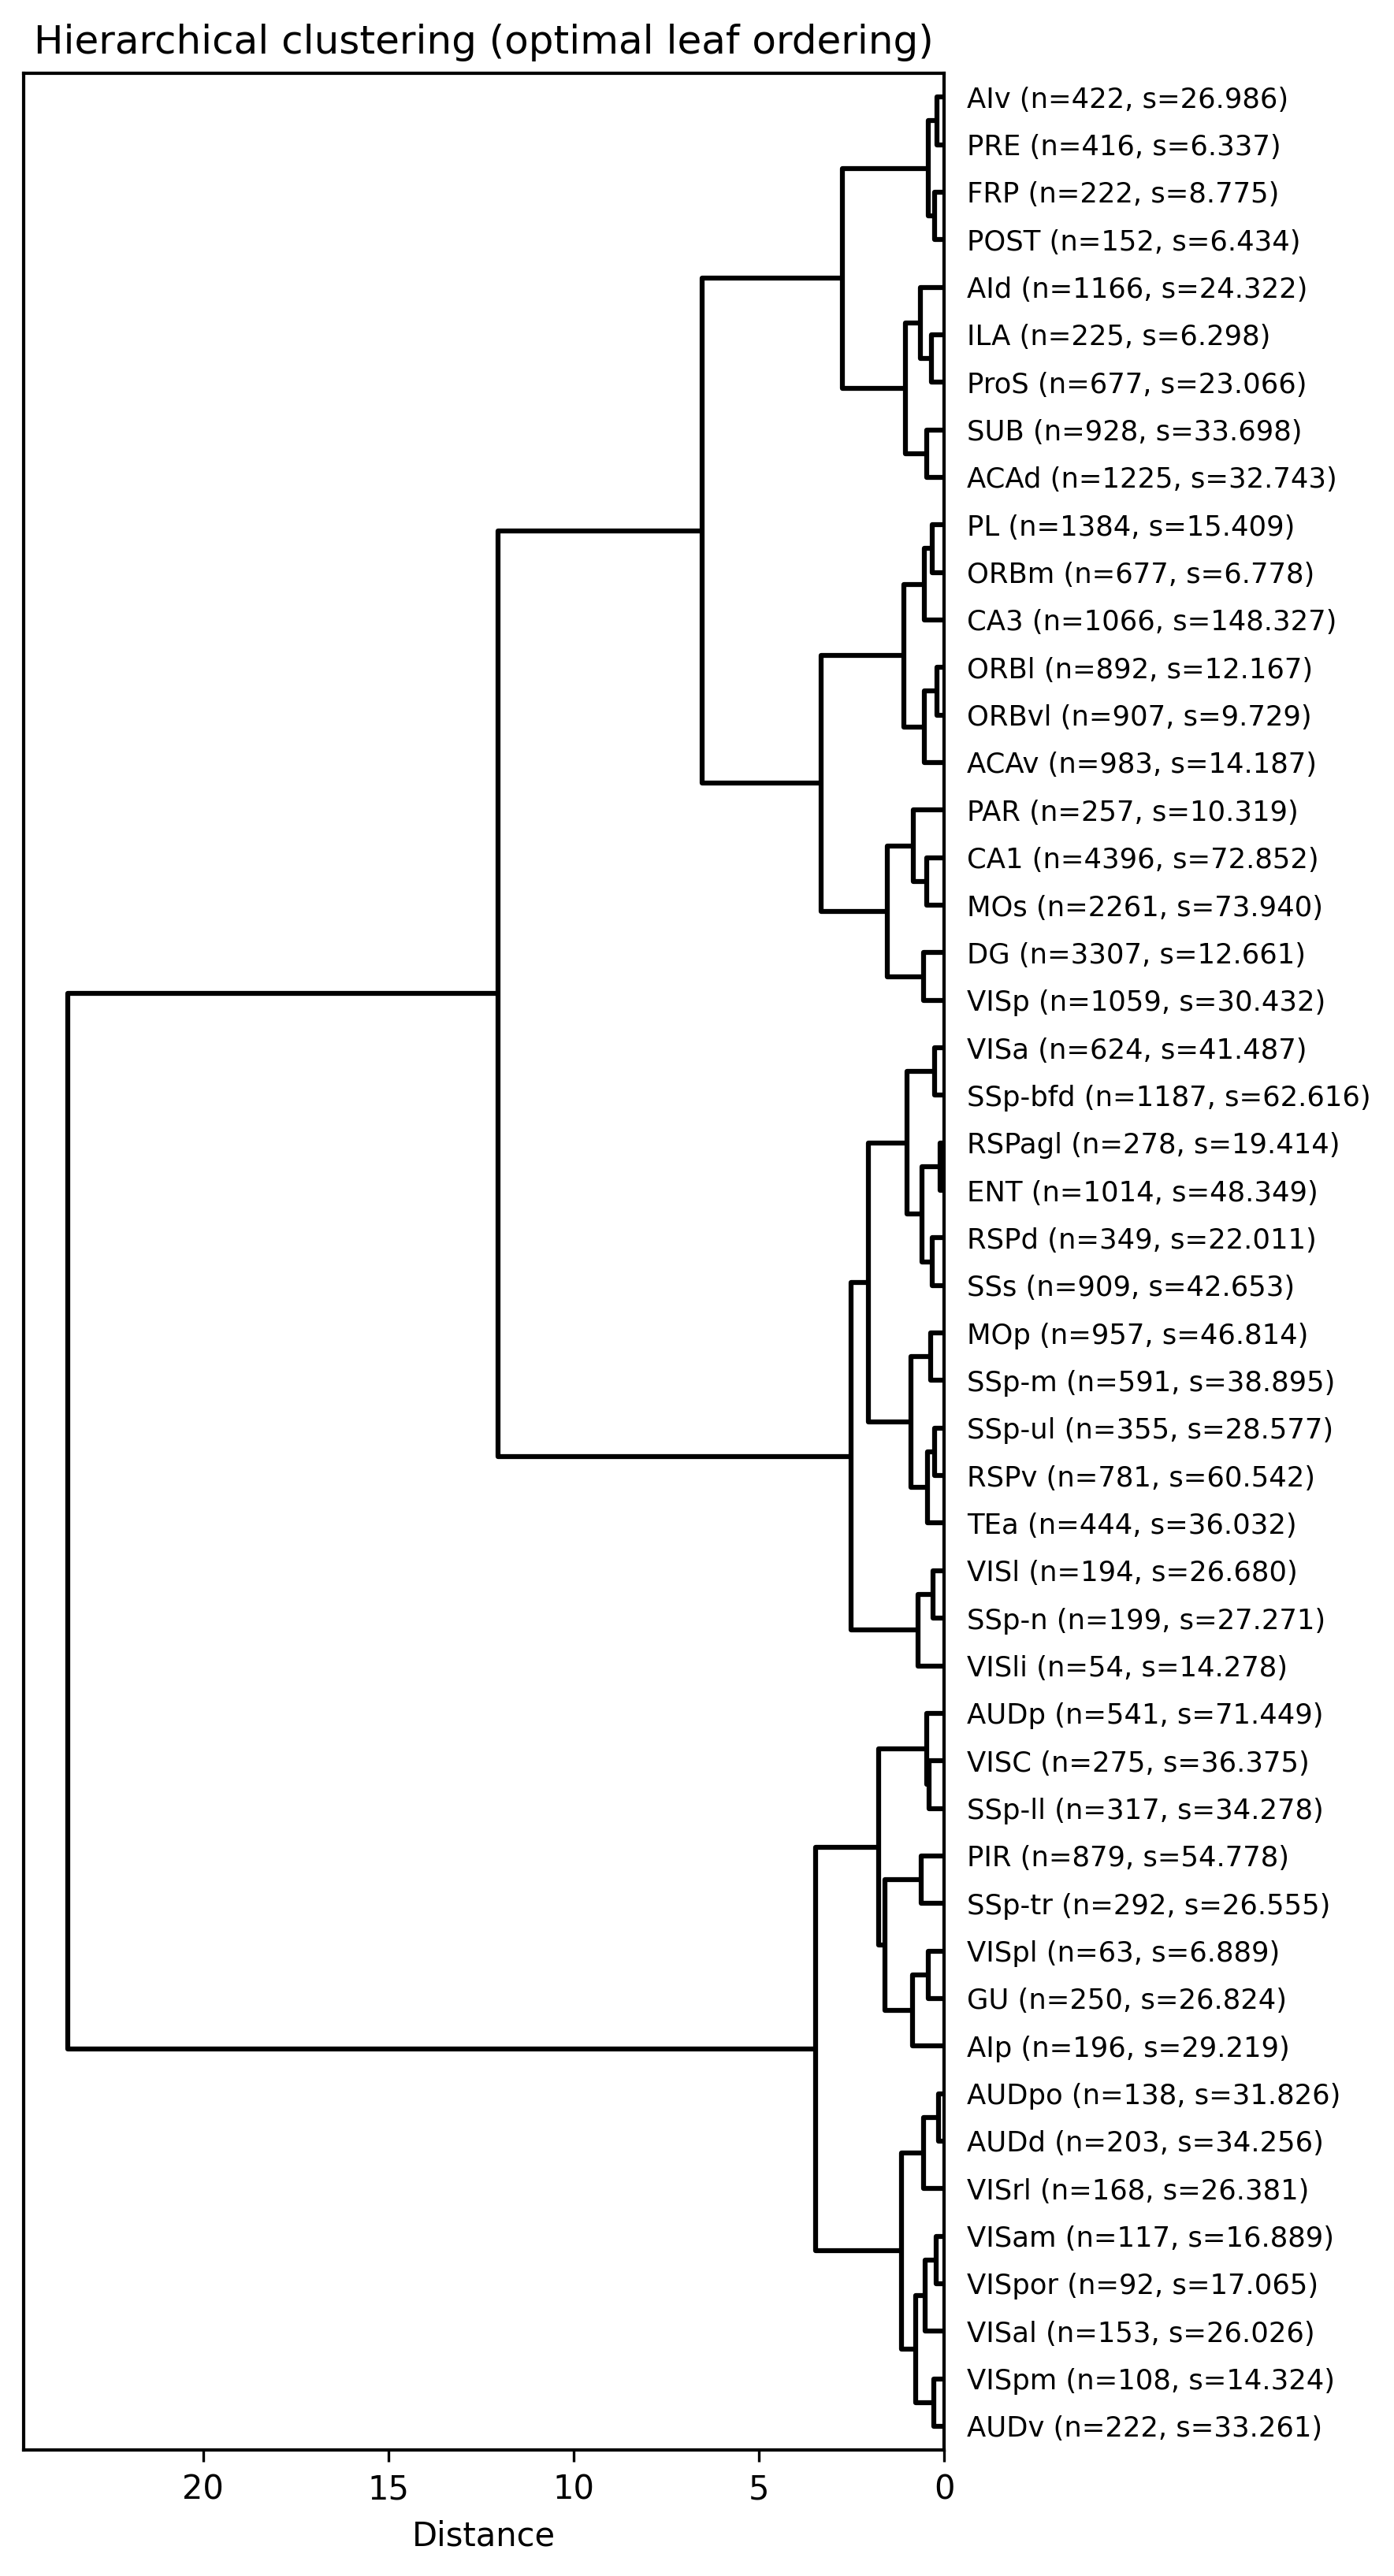

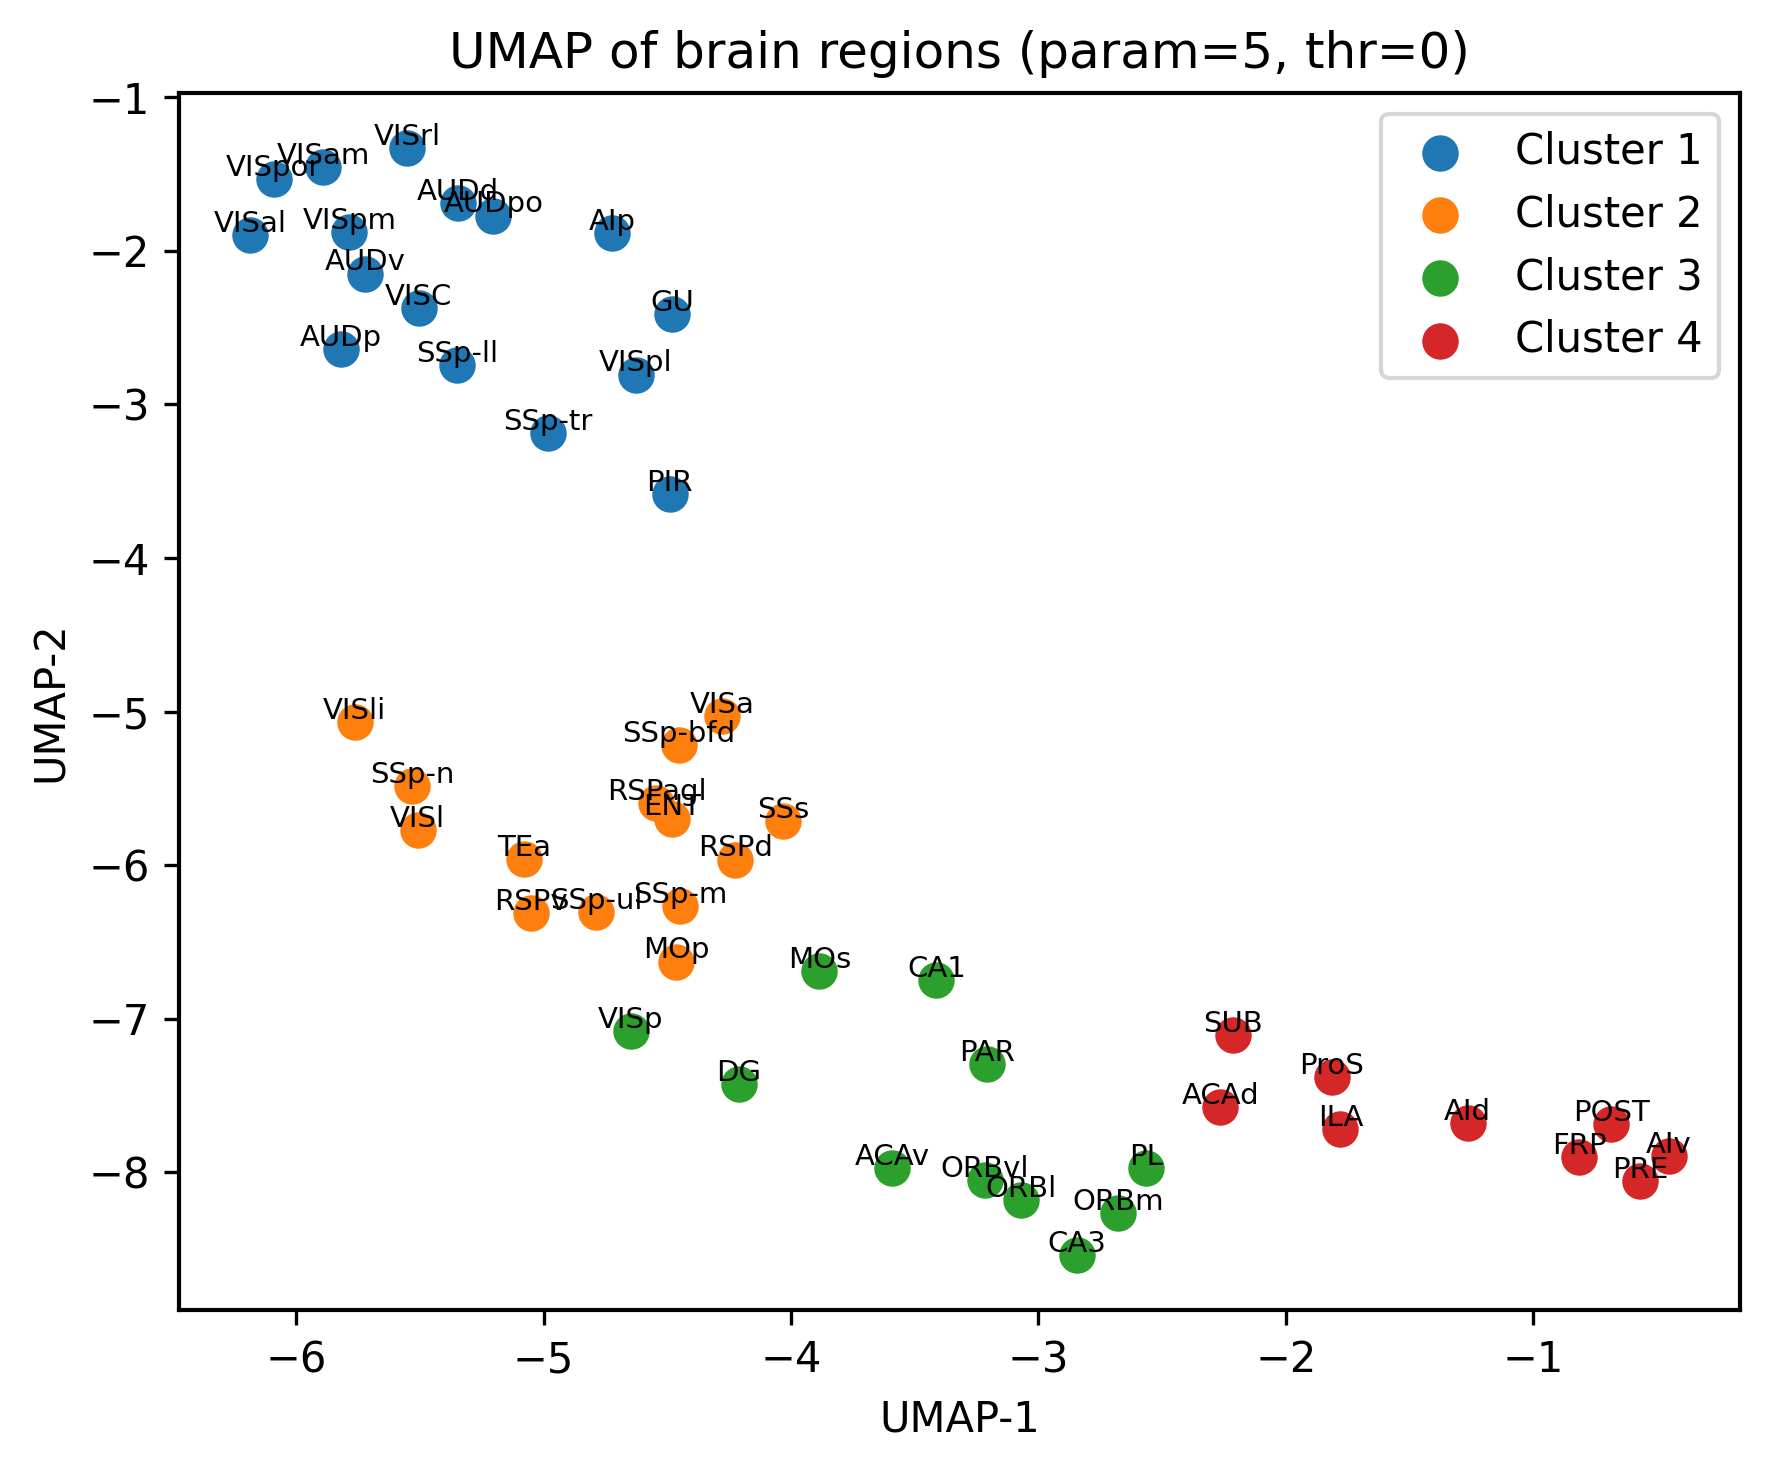

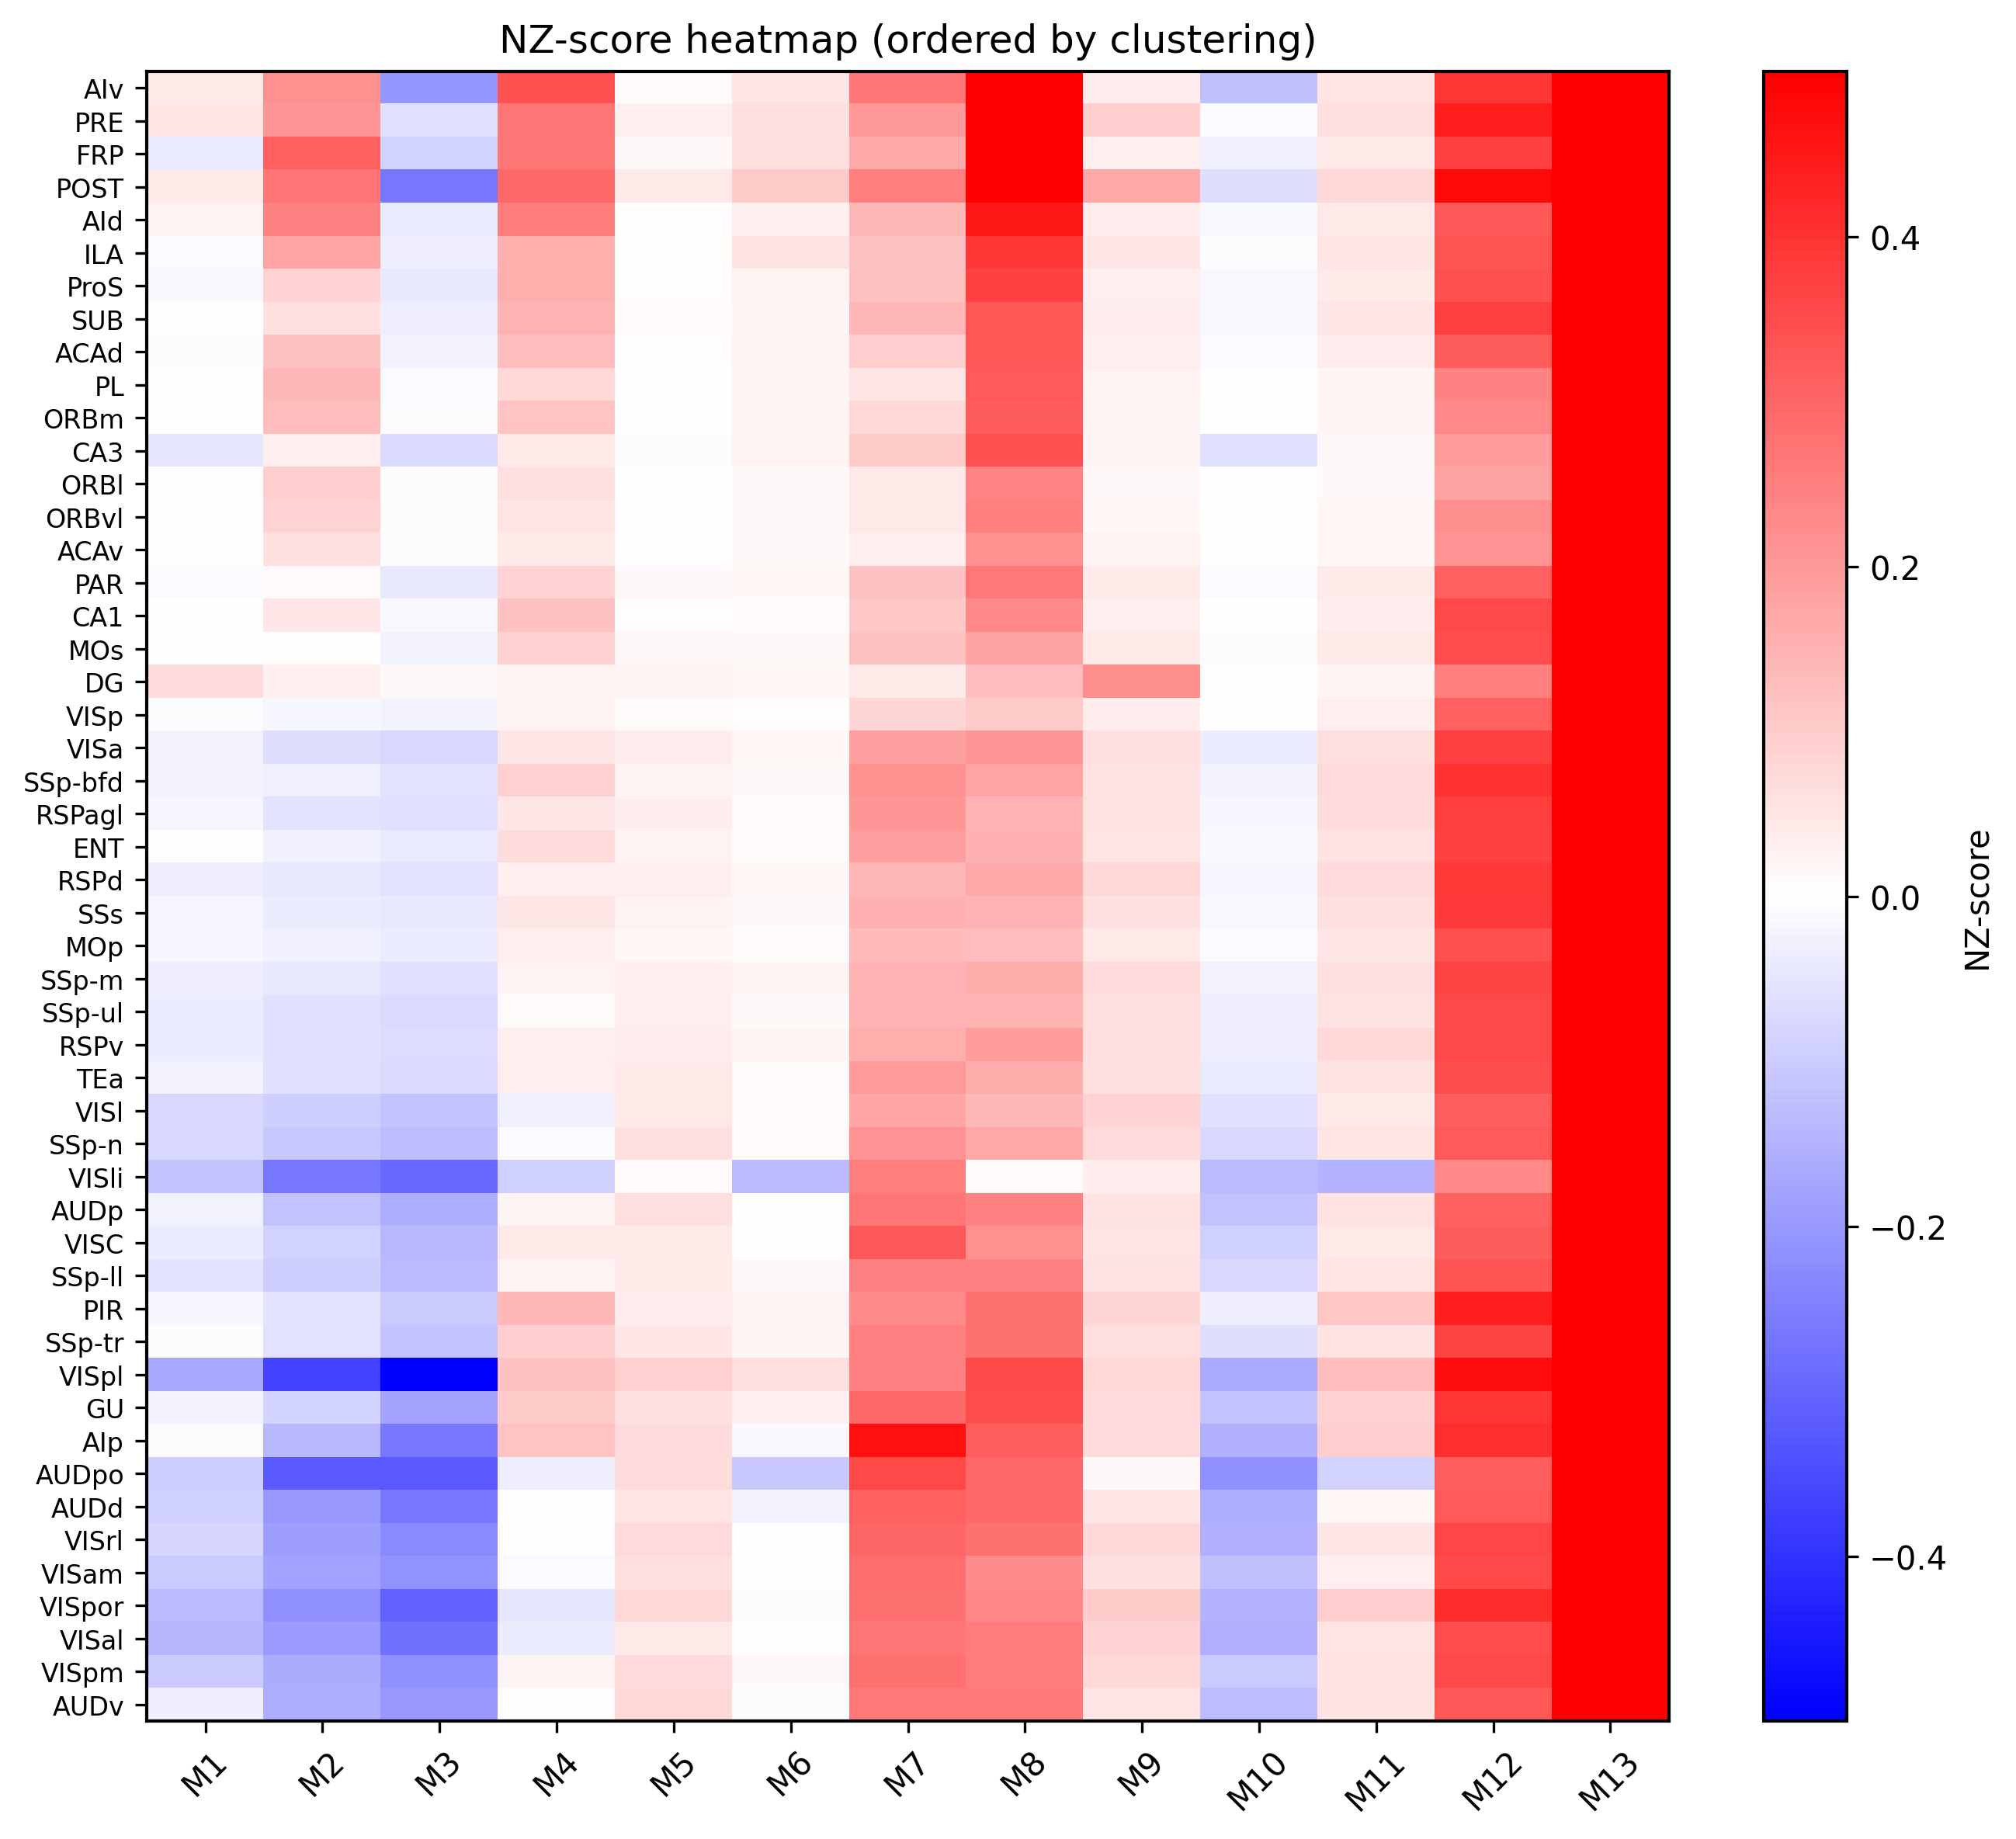

In [3]:
import pickle
import numpy as np
import umap
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering, dendrogram, fcluster
from scipy.spatial.distance import pdist


import matplotlib as mpl

# ===== 提升整体分辨率 & 字体 =====
mpl.rcParams['figure.dpi'] = 300        # 屏幕显示分辨率
mpl.rcParams['savefig.dpi'] = 300       # 保存图片分辨率
mpl.rcParams['figure.figsize'] = (6, 4) # 默认图大小（你后面单独设 figsize 会覆盖它）
mpl.rcParams['font.size'] = 10          # 全局字号
mpl.rcParams['axes.linewidth'] = 1.0    # 坐标轴线条粗一点
mpl.rcParams['pdf.fonttype'] = 42       # 方便 AI / PPT 里编辑
mpl.rcParams['ps.fonttype'] = 42
# ==================== 1. 加载 & 提取数据 ====================
with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    data = pickle.load(f)["results"][5]

NZ, names, nodes, spars = [], [], [], []
for r, info in data.items():
    if r in {"SSp", "VPL","PERI","ECT","VPL","PO","PR"}: continue
    mr = info["motif_results"].get("0")
    if mr and (nz := np.asarray(mr["NZ"], float)).shape[0] == 13:
        names.append(r)
        NZ.append(nz)
        nodes.append(mr["node"])
        spars.append(mr["sparsity"])

NZ = np.vstack(NZ)
names = np.array(names)
nodes = np.array(nodes)
spars = np.array(spars, float)

# ==================== 2. UMAP + 聚类 + 排序顺序 ====================
emb = umap.UMAP(n_neighbors=15, min_dist=0.15, metric='cosine', random_state=1).fit_transform(NZ)
Z = optimal_leaf_ordering(linkage(emb, "ward"), pdist(emb))
labels = fcluster(Z, t=4, criterion="maxclust")

# 关键：先拿到排序顺序（这里反转让树顶在上）
order = dendrogram(Z, no_plot=True)["leaves"][::-1]

# 排序所有数据

# ==================== 图1：层次聚类树（叶子带 n 和 sparsity）================
plt.figure(figsize=(6, 11))

# 重点在这里：构造带信息的标签列表（已经按 order 排好）
rich_labels = [f"{r} (n={int(n)}, s={s:.3f})" for r,n,s in zip(names, nodes, (nodes-1)*spars)]

dendrogram(Z,
           orientation="left",
           labels=rich_labels,          # 改这里就行！
           leaf_font_size=8.5,
           color_threshold=0,
           above_threshold_color='k')
plt.title("Hierarchical clustering (optimal leaf ordering)")
plt.xlabel("Distance")
plt.tight_layout()
plt.savefig("1.hierarchical_clustering_dendrogram.svg", bbox_inches='tight',  dpi=300, transparent=True)
plt.show()

NZ, names, nodes, spars, labels, emb = map(sort_by_order, [NZ, names, nodes, spars, labels, emb])


# ==================== 图2：UMAP ====================
plt.figure(figsize=(6, 5))
for c in np.unique(labels):
    m = labels == c
    plt.scatter(emb[m, 0], emb[m, 1], label=f"Cluster {c}", s=60)
for (x, y), n in zip(emb, names):
    plt.text(x, y+0.02, n, fontsize=7, ha='center')
plt.legend()
plt.title("UMAP of brain regions (param=5, thr=0)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout(); 
plt.savefig("2.umap_brain_regions.svg", bbox_inches='tight',  dpi=300, transparent=True)

plt.show()

# ==================== 图3：热图 ====================
plt.figure(figsize=(9, 8))
im = plt.imshow(np.log10(1+5*NZ), aspect='auto', cmap='bwr', vmin=-0.5, vmax=0.5)
plt.colorbar(im, label="NZ-score")
plt.yticks(range(len(names)), names, fontsize=8)   # 这里也顺便统一用 rich_labels
plt.xticks(range(13), [f"M{i+1}" for i in range(13)], rotation=45)
plt.title("NZ-score heatmap (ordered by clustering)")
plt.tight_layout()
plt.savefig("3.nz_score_heatmap.svg", bbox_inches='tight',  dpi=300, transparent=True)
plt.show()





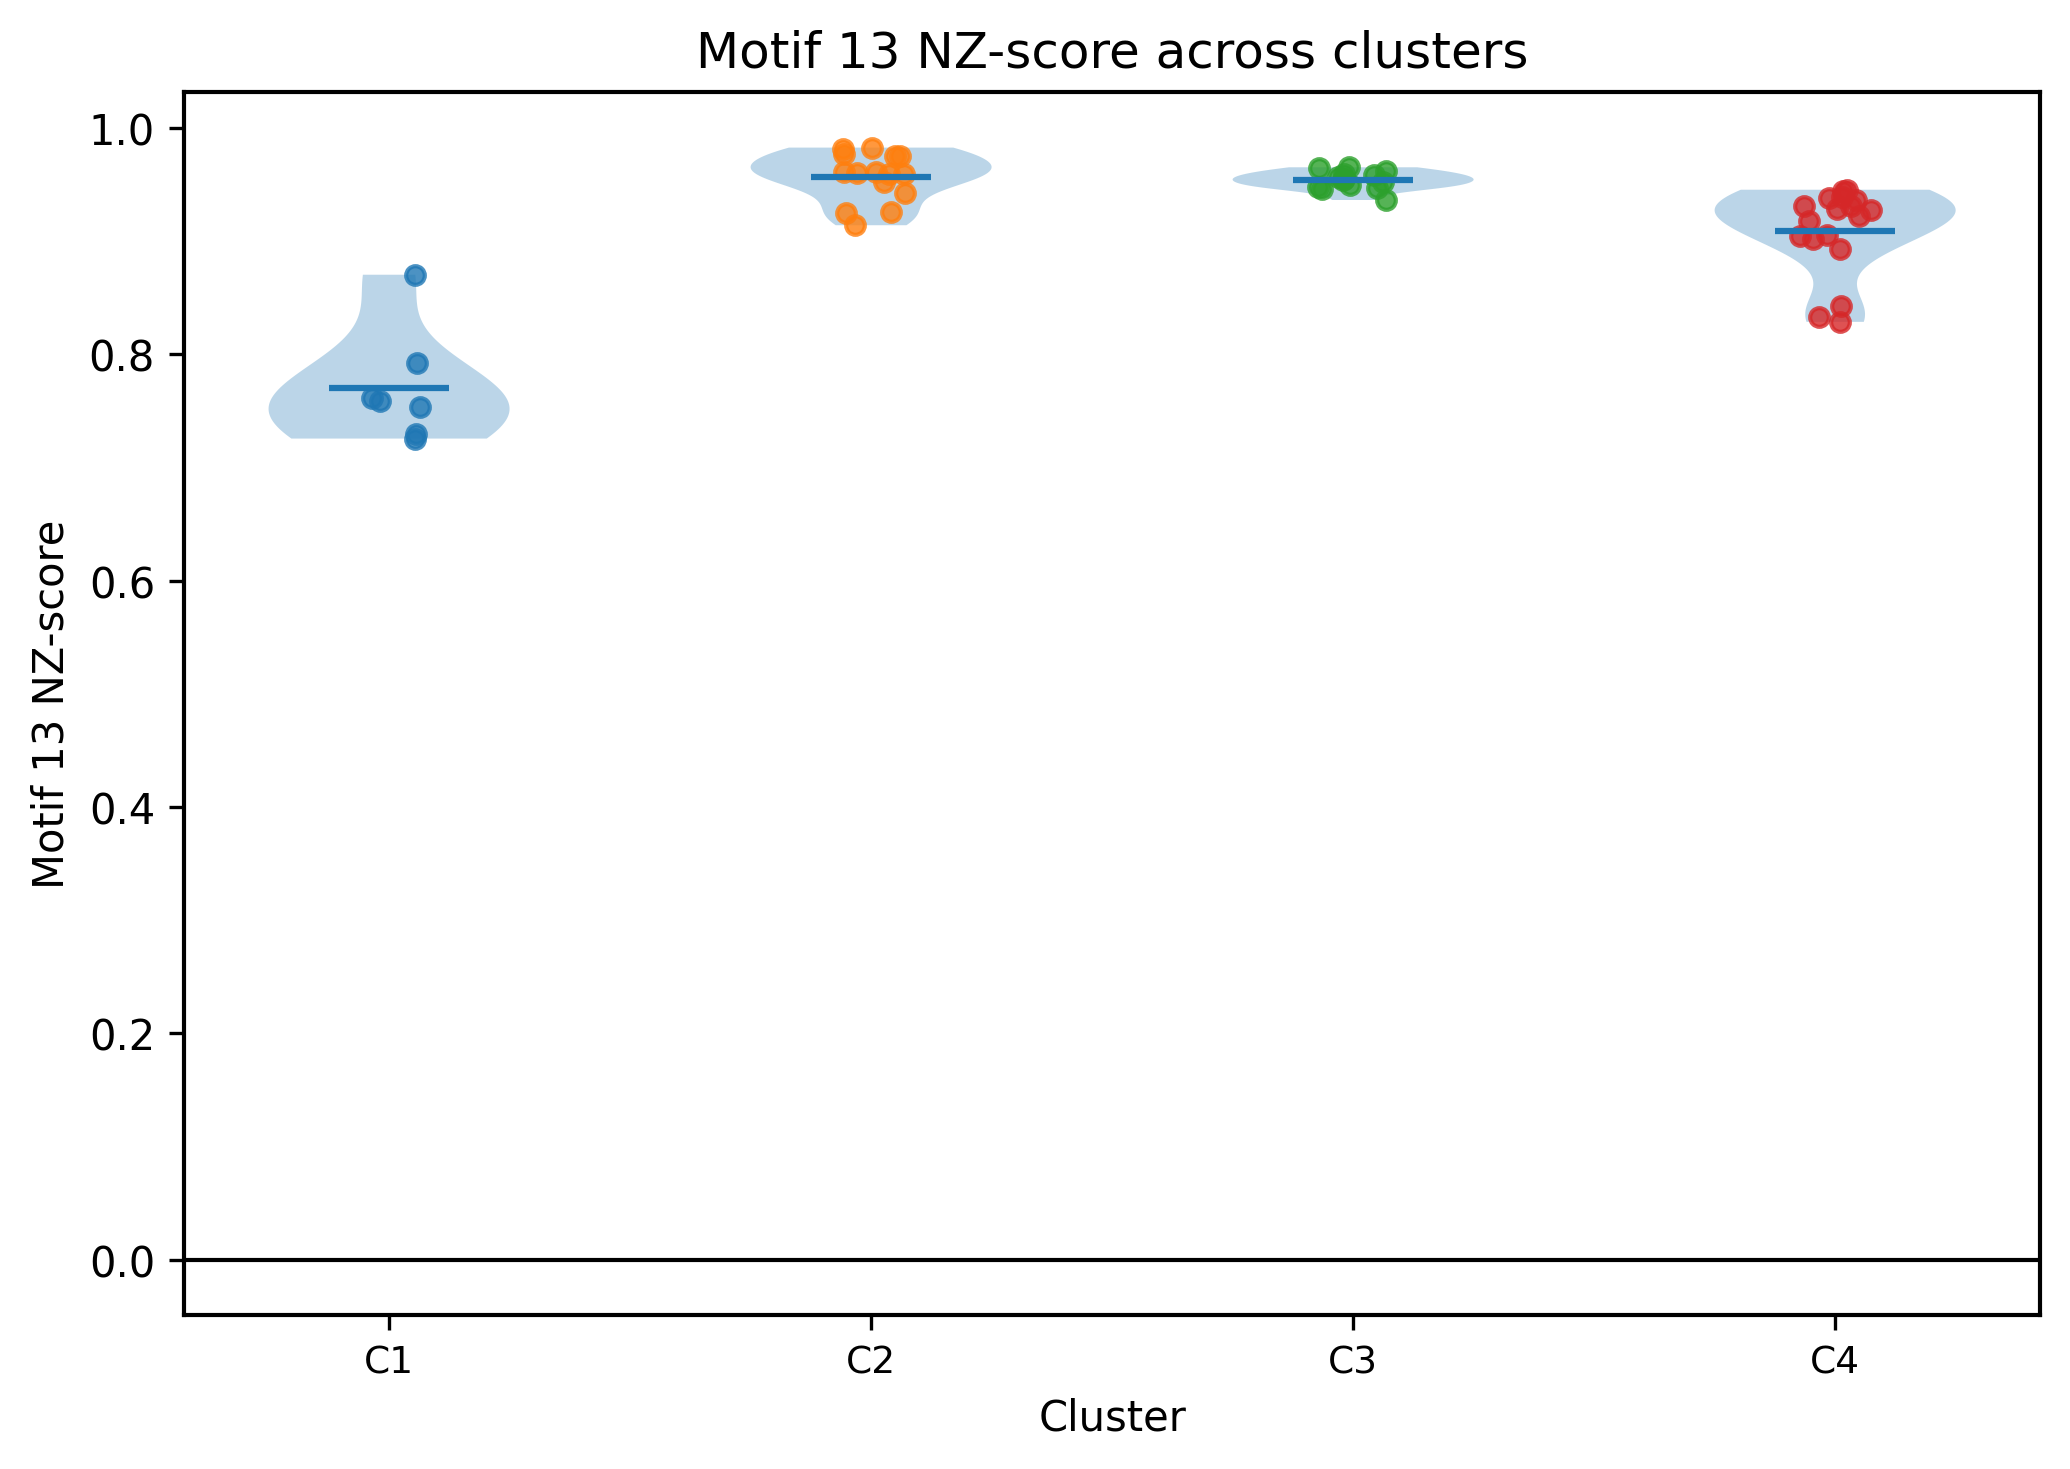

In [66]:
# ==================== 图4：Motif 13 NZ-score violin + 点（不标名字） ====================
motif13_idx = 12
m13 = NZ[:, motif13_idx]      # 每个脑区的 motif13 NZ-score

unique_clusters = np.unique(labels)
n_clust = len(unique_clusters)

# 按 cluster 收集数据
data_by_cluster = [m13[labels == c] for c in unique_clusters]

plt.figure(figsize=(7, 5))

# ---- 1) Violin 图 ----
parts = plt.violinplot(
    data_by_cluster,
    positions=np.arange(1, n_clust + 1),
    showmeans=True,
    showextrema=False,
    showmedians=False,
)

# ---- 2) 在每个 cluster 上叠加散点（不标名字） ----
for i, c in enumerate(unique_clusters, start=1):
    mask = (labels == c)
    m13_c = m13[mask]

    # 在 x 轴附近做一点左右抖动，避免完全重叠
    jitter = (np.random.rand(len(m13_c)) - 0.5) * 0.15   # 抖动范围可调
    x_pos = np.full(len(m13_c), i) + jitter

    plt.scatter(x_pos, m13_c, s=20, alpha=0.8)

# x 轴：cluster 编号
plt.xticks(
    np.arange(1, n_clust + 1),
    [f"C{int(c)}" for c in unique_clusters],
    fontsize=9,
)

plt.ylabel("Motif 13 NZ-score")
plt.xlabel("Cluster")
plt.title("Motif 13 NZ-score across clusters")

plt.axhline(0, color="k", lw=1)

plt.tight_layout()
plt.show()

In [20]:
NZ.shape

(54, 13)

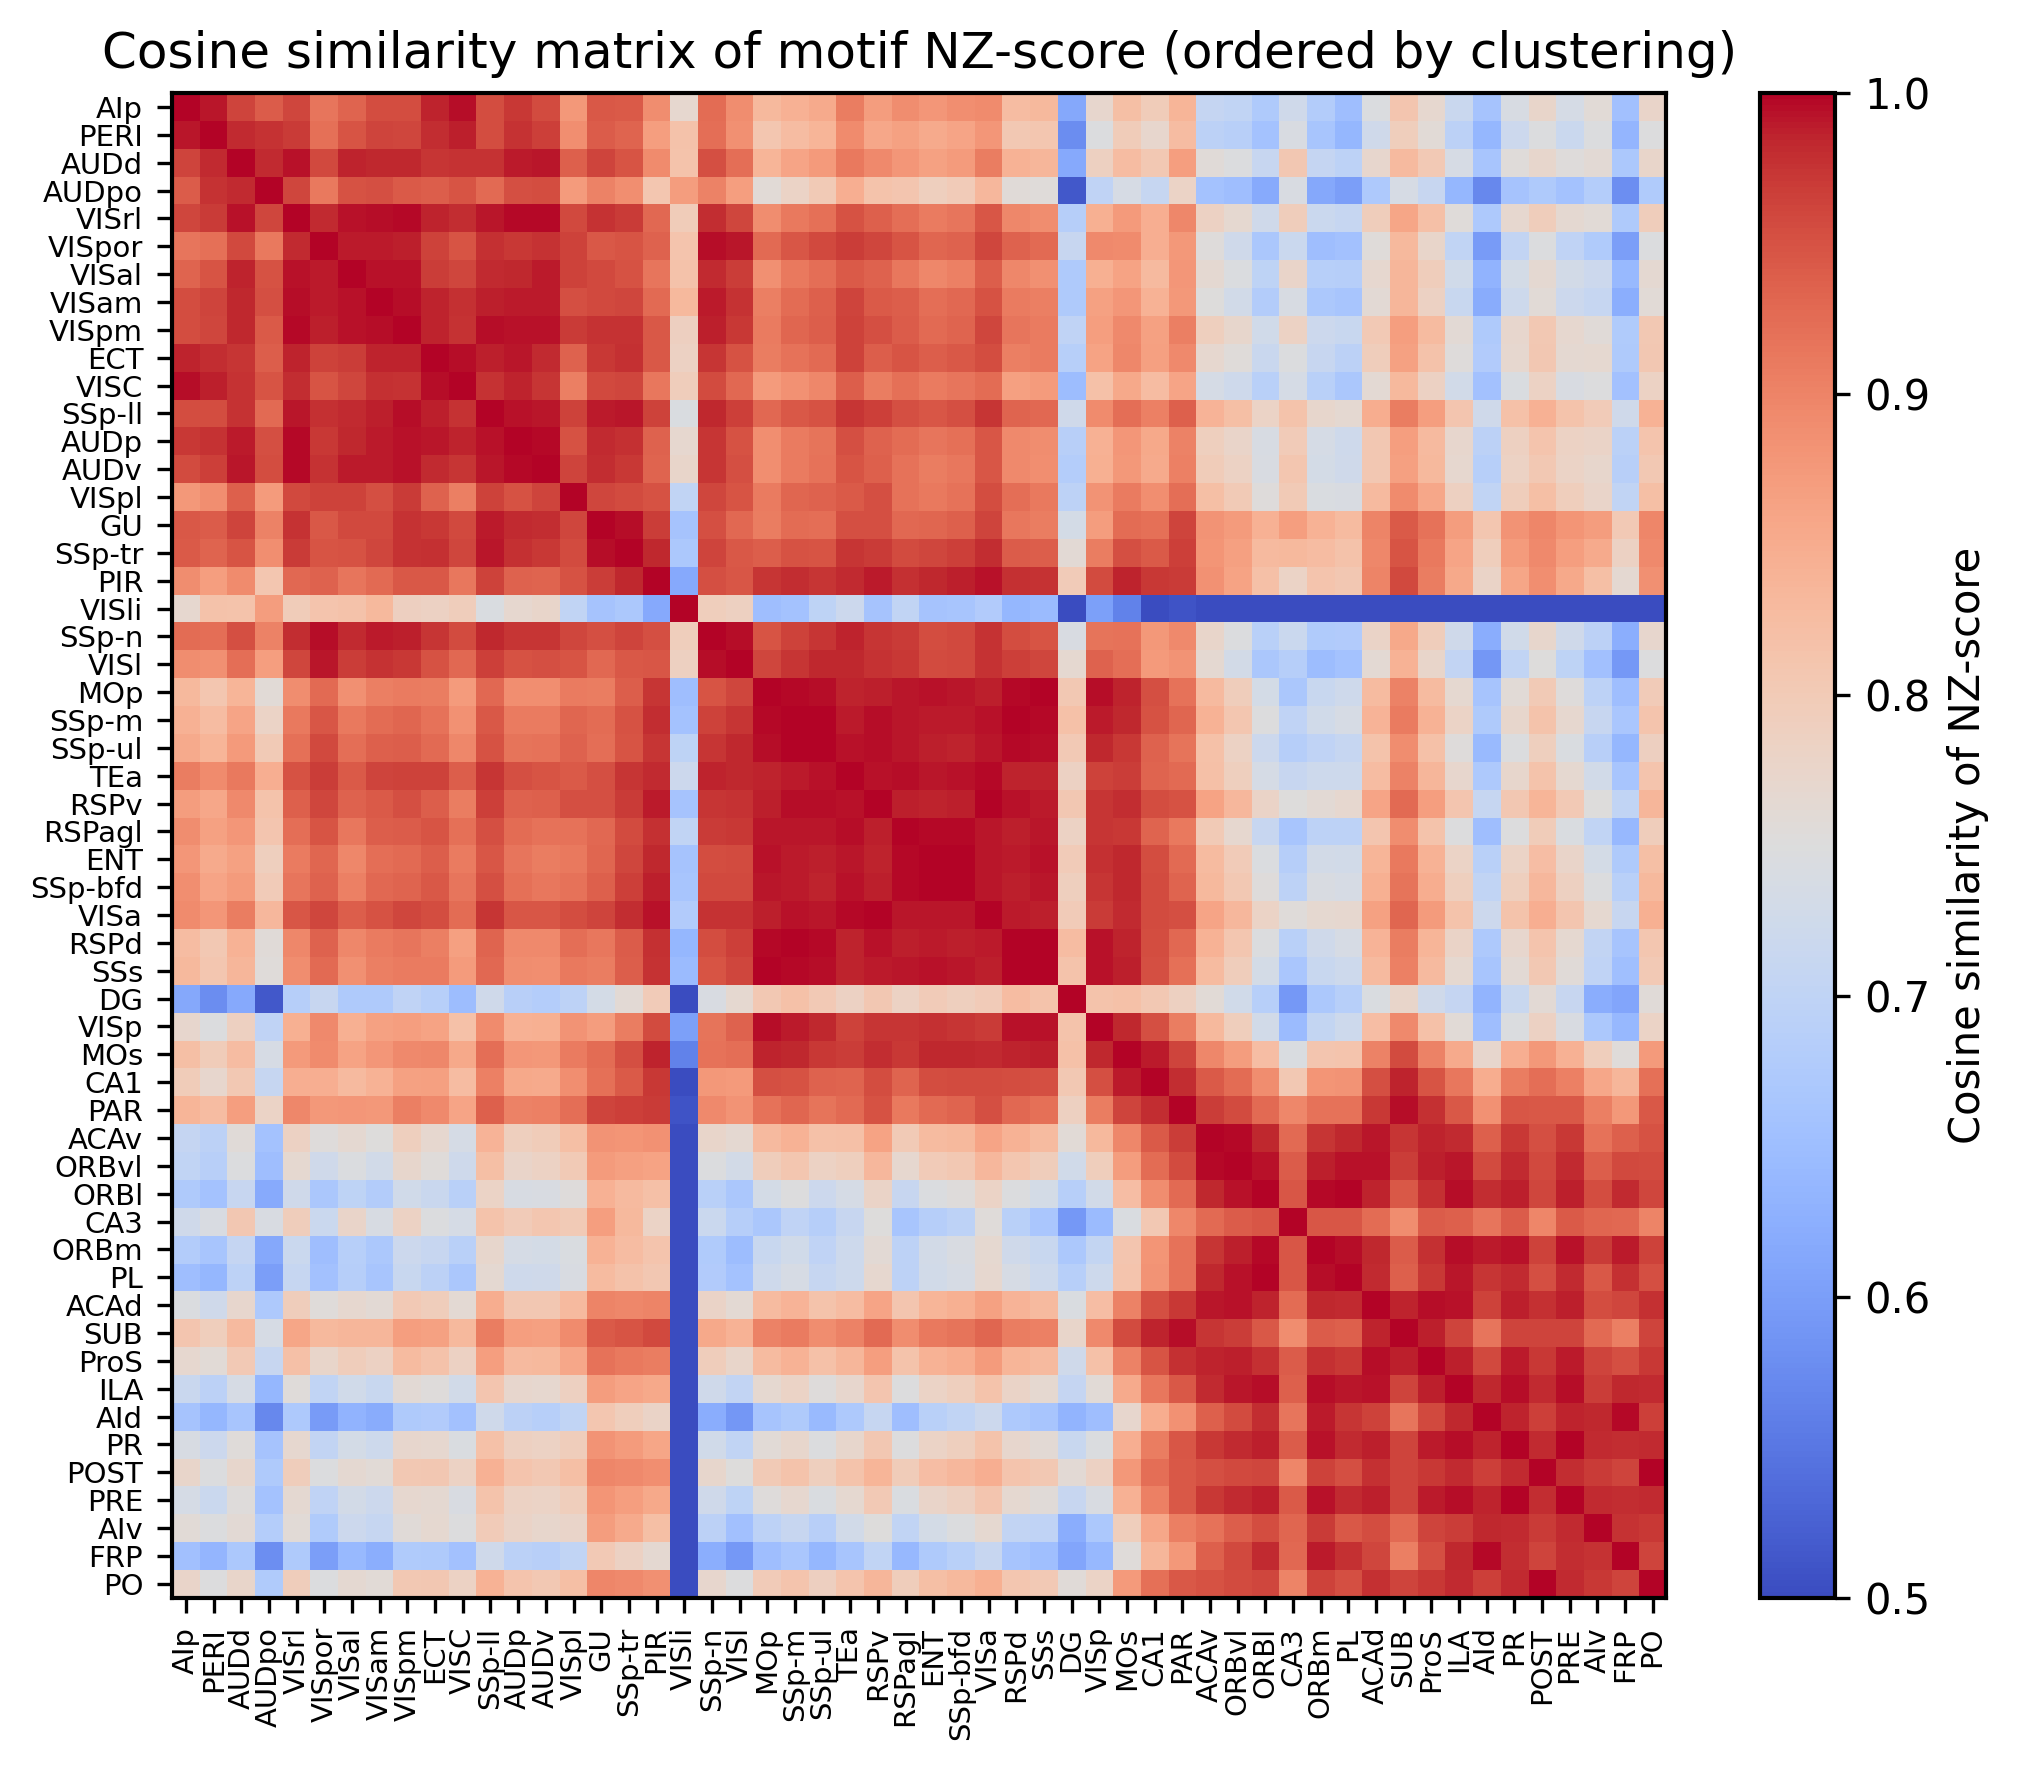

In [5]:
import numpy as np

# ===== 在你已有的 data 和 4 个 cluster_names 定义之后加这段 =====

all_clusters = {
    1: cluster1_names,
    2: cluster2_names,
    3: cluster3_names,
    4: cluster4_names,
}

def zero_row_col_ratio(sc, eps=0.0):
    """
    sc: (n, n) matrix
    eps: 允许把 |x| <= eps 当作 0（防止浮点噪声）
    """
    sc = np.asarray(sc, float)
    if sc.ndim != 2 or sc.shape[0] != sc.shape[1]:
        return None

    n = sc.shape[0]
    if n == 0:
        return (0, 0, 0.0, 0.0)

    # 判断“近似为 0”
    if eps > 0:
        is_zero = np.abs(sc) <= eps
    else:
        is_zero = (sc == 0)

    # 行全 0：该行所有元素都为 0
    zero_rows = np.all(is_zero, axis=1)
    # 列全 0：该列所有元素都为 0
    zero_cols = np.all(is_zero, axis=0)

    zr = int(zero_rows.sum())
    zc = int(zero_cols.sum())
    return zr, zc, zr / n, zc / n


print("===== Zero-row / Zero-col ratios in SC matrices (param=5) =====")

# 你可以把 eps 改成 1e-12 或 1e-9 视情况而定
EPS = 0.0

cluster_row_ratios = {cid: [] for cid in all_clusters}
cluster_col_ratios = {cid: [] for cid in all_clusters}

for cid, rlist in all_clusters.items():
    print(f"\n--- Cluster {cid} ---")
    for r in rlist:
        if r not in data:
            print(f"{r:10s} : [NOT FOUND in data]")
            continue
        info = data[r]
        if "sc" not in info:
            print(f"{r:10s} : [NO 'sc' key]")
            continue

        sc = np.asarray(info["sc"], float)
        out = zero_row_col_ratio(sc, eps=EPS)
        if out is None:
            print(f"{r:10s} : sc shape = {sc.shape} [NOT square]")
            continue

        zr, zc, zr_ratio, zc_ratio = out
        n = sc.shape[0]

        cluster_row_ratios[cid].append(zr_ratio)
        cluster_col_ratios[cid].append(zc_ratio)

        print(
            f"{r:10s} : sc={sc.shape} | "
            f"zero-rows {zr:3d}/{n} ({zr_ratio*100:5.1f}%) | "
            f"zero-cols {zc:3d}/{n} ({zc_ratio*100:5.1f}%)"
        )

# ===== 可选：按 cluster 做个简单汇总 =====
print("\n===== Cluster summary (mean ± std) =====")
for cid in sorted(all_clusters.keys()):
    rr = np.array(cluster_row_ratios[cid], float)
    cc = np.array(cluster_col_ratios[cid], float)
    if rr.size == 0:
        print(f"Cluster {cid}: no valid regions")
        continue
    print(
        f"Cluster {cid}: "
        f"zero-row% = {rr.mean()*100:.2f} ± {rr.std(ddof=1)*100 if rr.size>1 else 0:.2f}, "
        f"zero-col% = {cc.mean()*100:.2f} ± {cc.std(ddof=1)*100 if cc.size>1 else 0:.2f}"
    )

===== Zero-row / Zero-col ratios in SC matrices (param=5) =====

--- Cluster 1 ---
FRP        : sc=(222, 222) | zero-rows  20/222 (  9.0%) | zero-cols 169/222 ( 76.1%)
PL         : sc=(1384, 1384) | zero-rows  73/1384 (  5.3%) | zero-cols 1226/1384 ( 88.6%)
ILA        : sc=(225, 225) | zero-rows  67/225 ( 29.8%) | zero-cols 186/225 ( 82.7%)
AId        : sc=(1166, 1166) | zero-rows  78/1166 (  6.7%) | zero-cols 895/1166 ( 76.8%)
AIv        : sc=(422, 422) | zero-rows  25/422 (  5.9%) | zero-cols 240/422 ( 56.9%)
ACAd       : sc=(1225, 1225) | zero-rows  36/1225 (  2.9%) | zero-cols 873/1225 ( 71.3%)
ACAv       : sc=(983, 983) | zero-rows  97/983 (  9.9%) | zero-cols 816/983 ( 83.0%)
ORBl       : sc=(892, 892) | zero-rows  98/892 ( 11.0%) | zero-cols 770/892 ( 86.3%)
ORBvl      : sc=(907, 907) | zero-rows 110/907 ( 12.1%) | zero-cols 796/907 ( 87.8%)
ORBm       : sc=(677, 677) | zero-rows 193/677 ( 28.5%) | zero-cols 612/677 ( 90.4%)
MOs        : sc=(2261, 2261) | zero-rows  43/2261 (  1

/opt/miniconda3/envs/population_paper/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


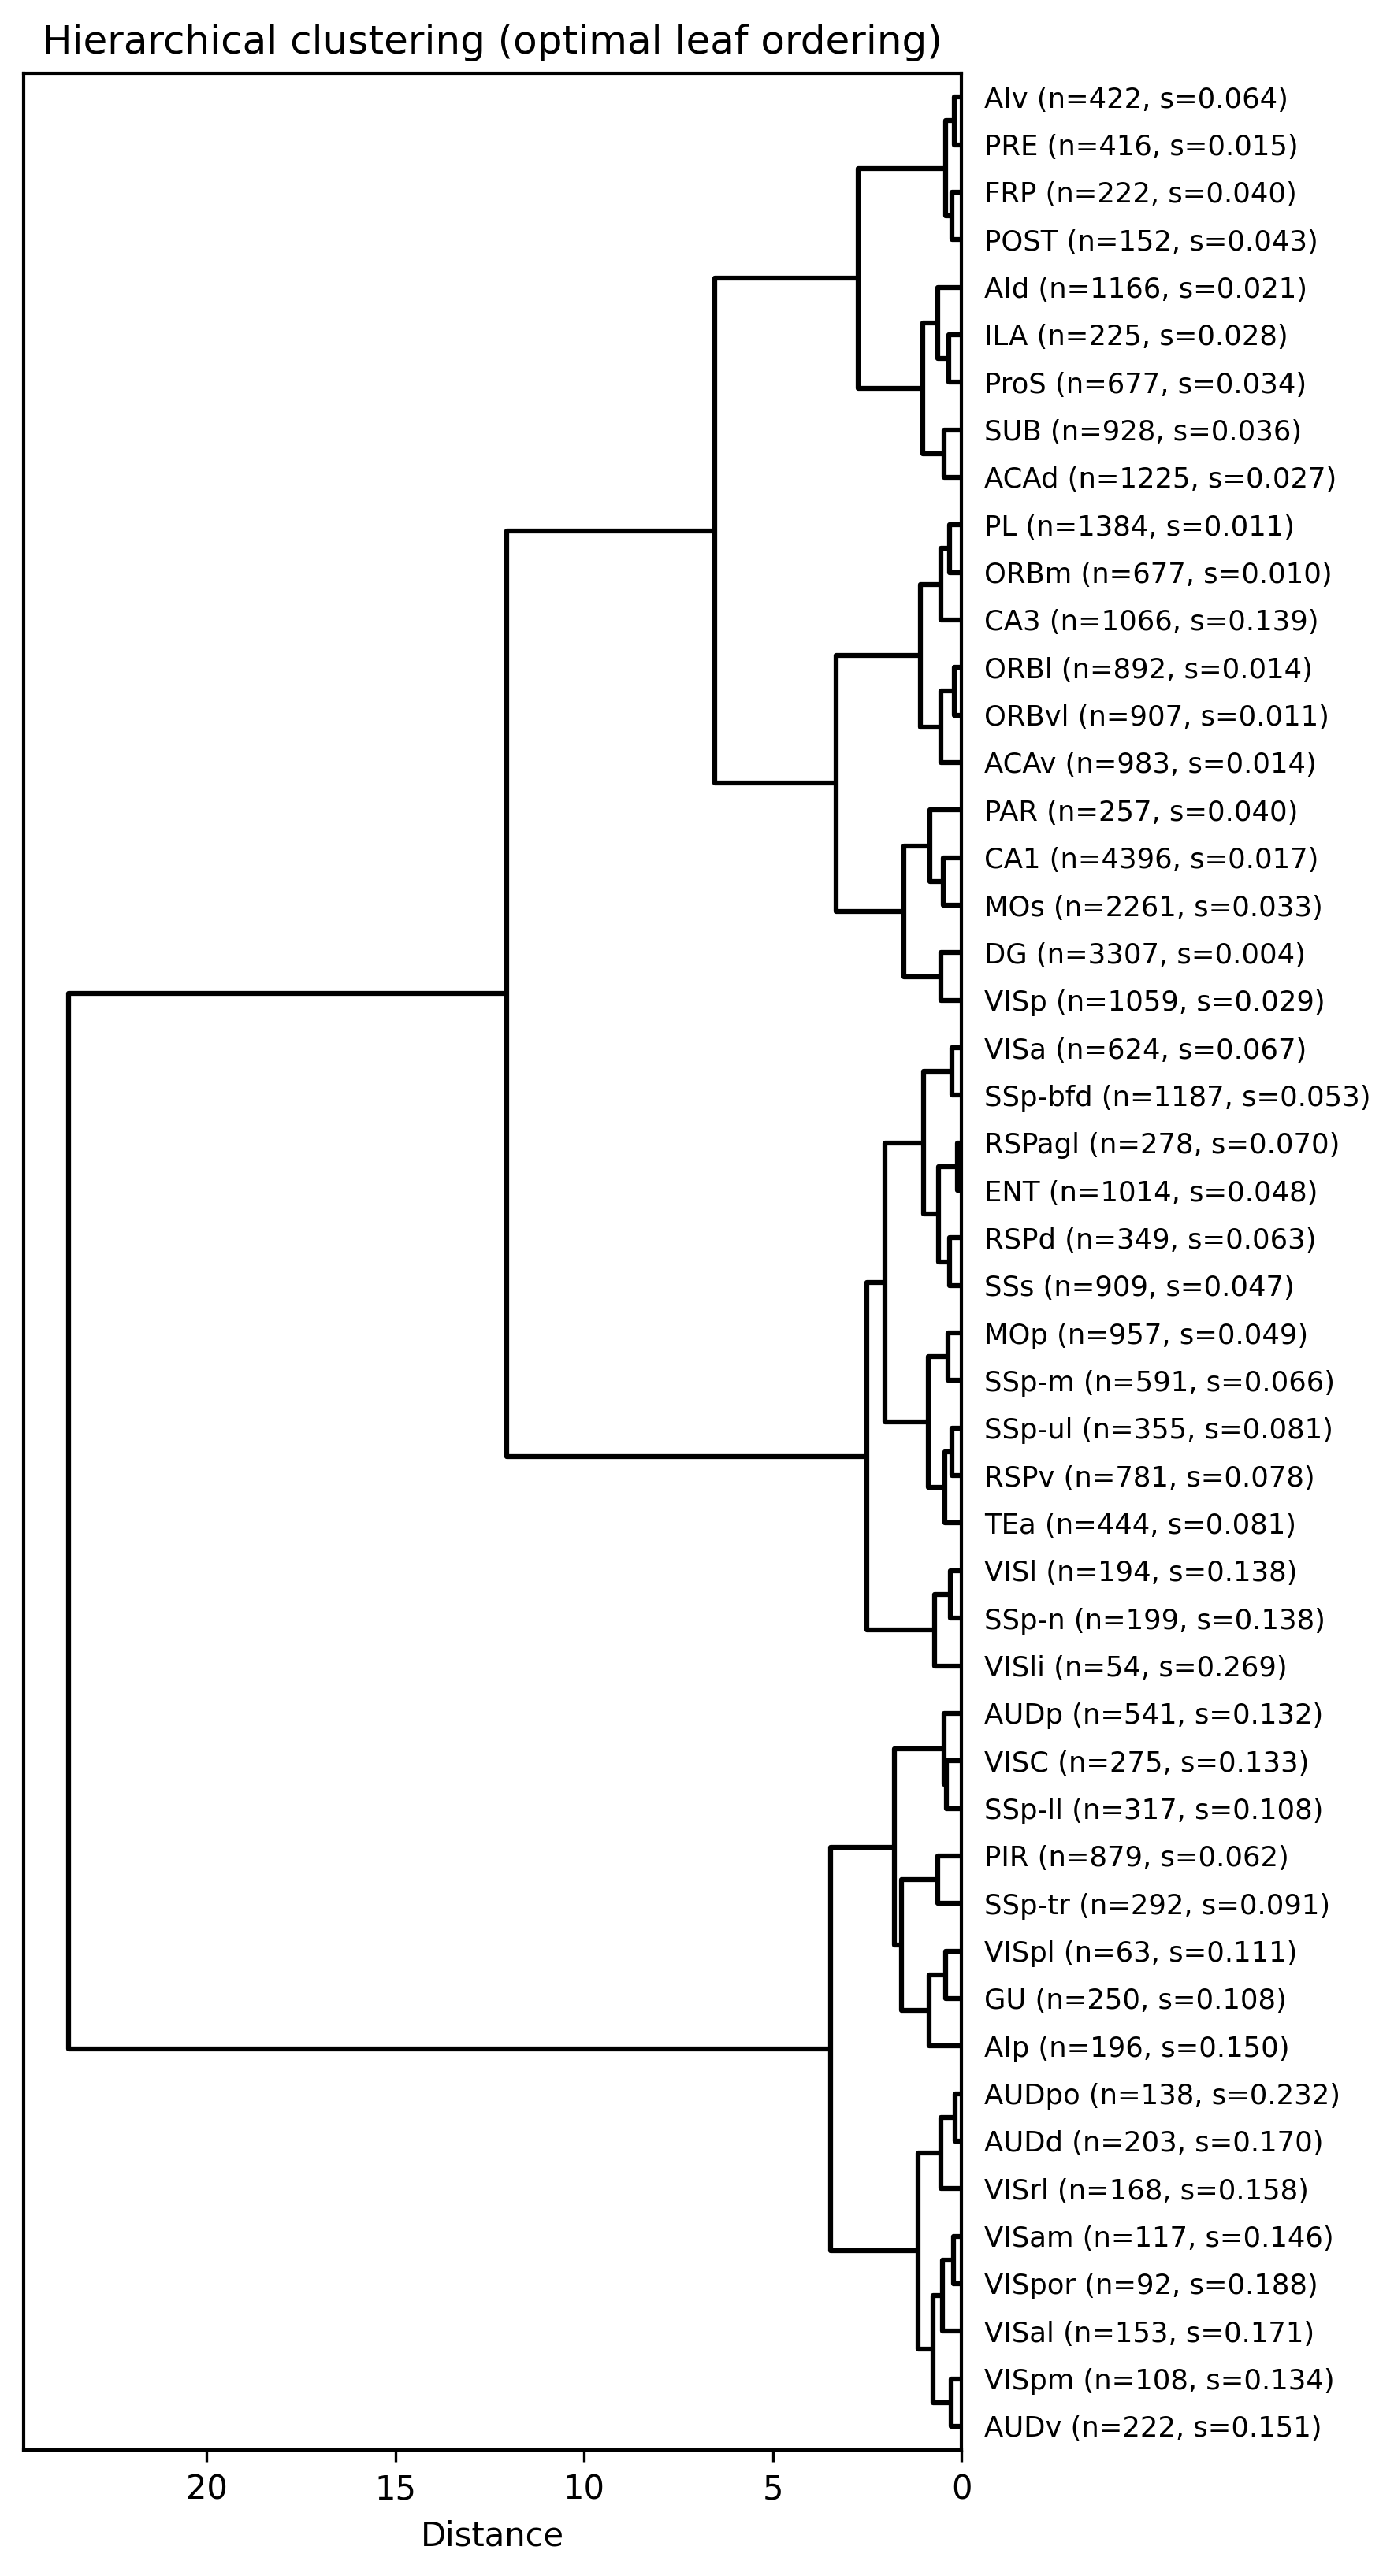

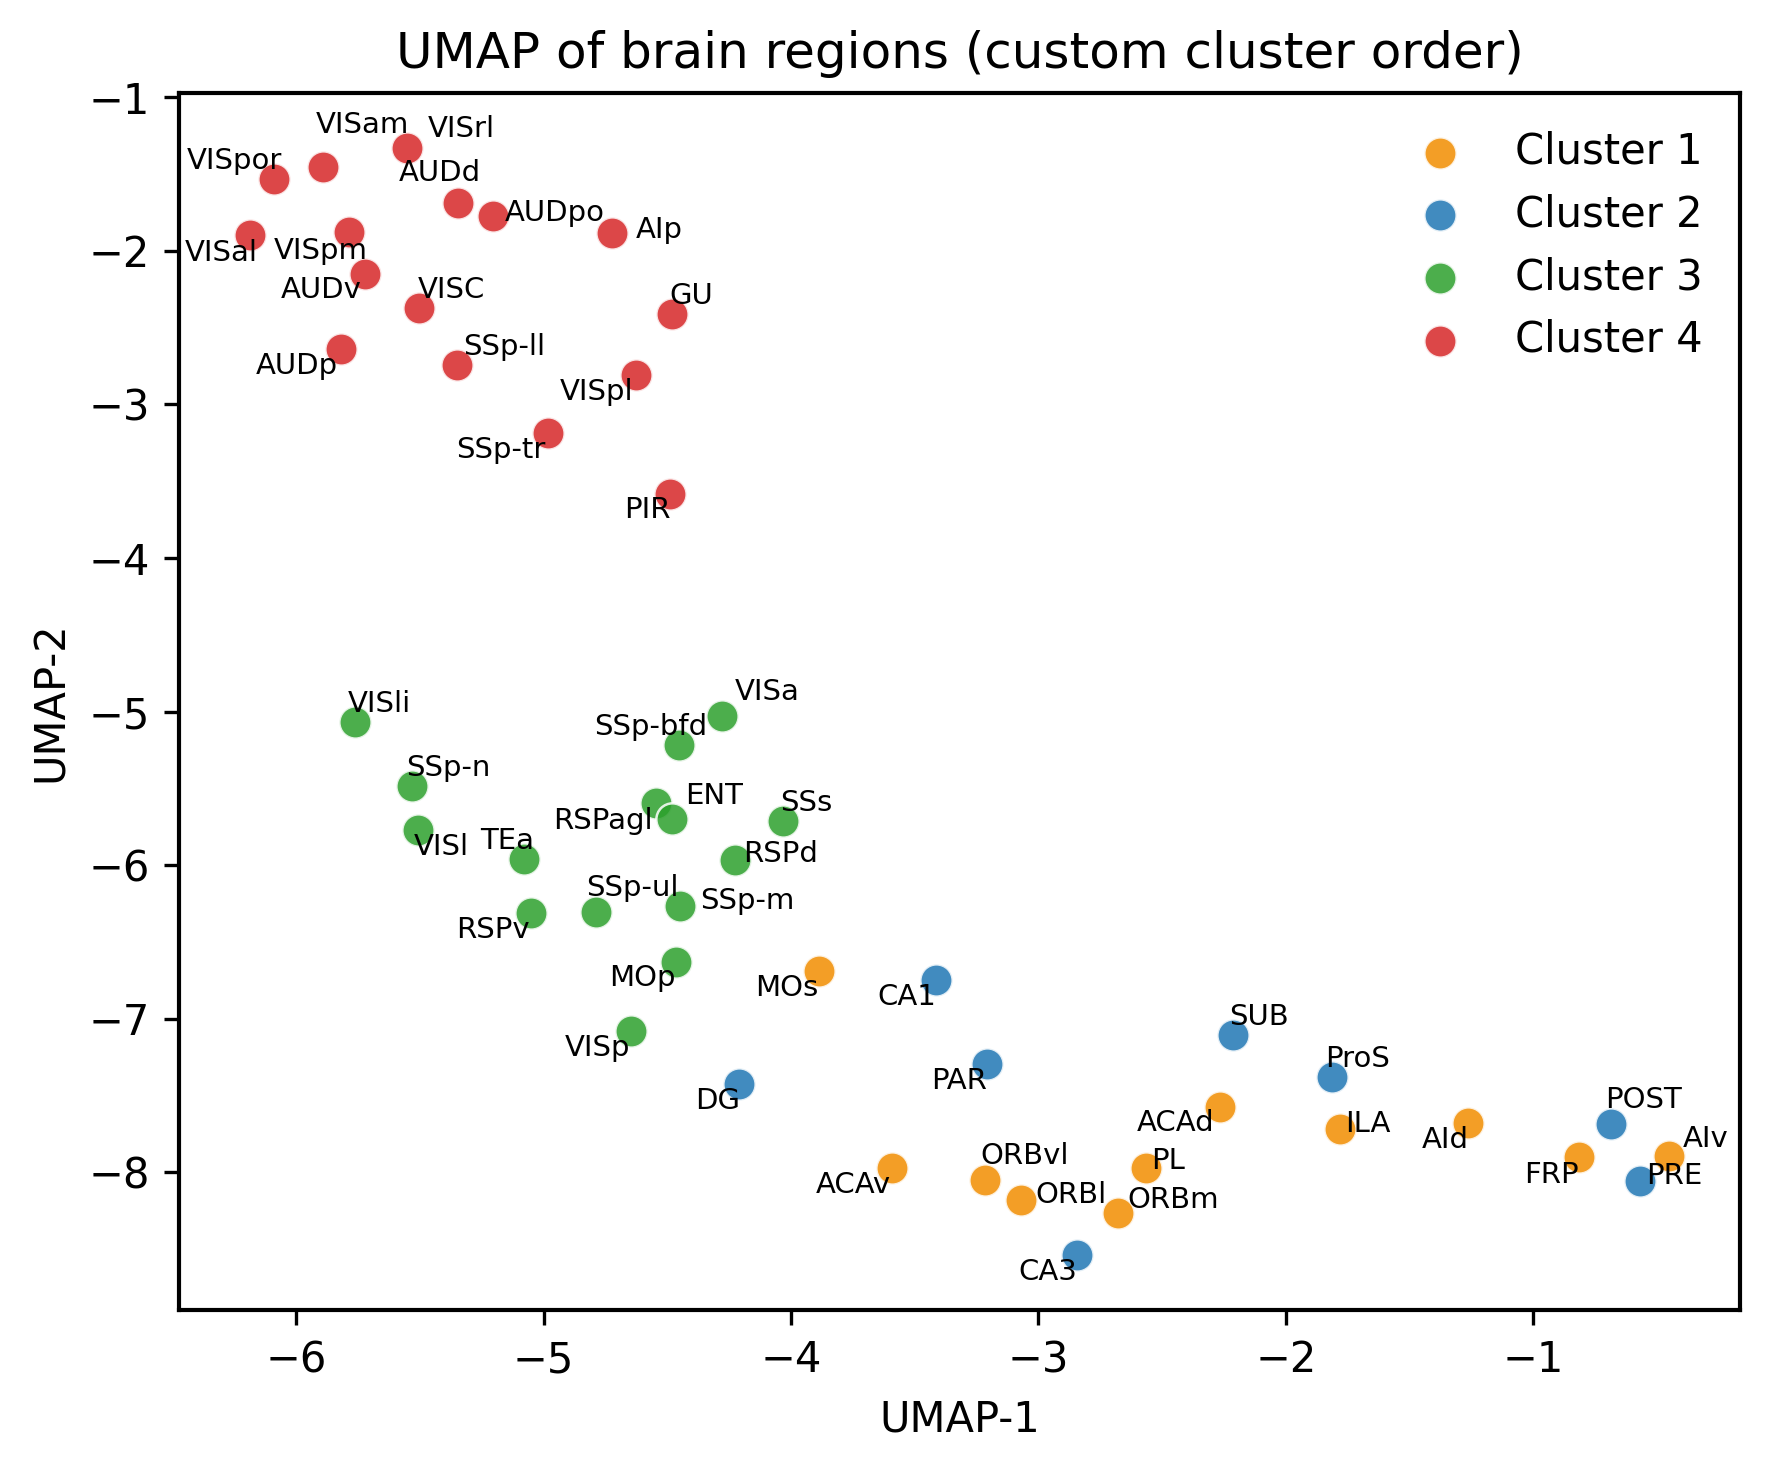

/var/folders/r5/559b8r_j54z7dqt6lc798x_m0000gn/T/ipykernel_51601/2328545693.py:229: RuntimeWarning: invalid value encountered in log10
  im = plt.imshow(np.nan_to_num(np.log10(1 + 8*NZ), nan=-100.0, posinf=-100.0, neginf=-100.0), aspect='auto', cmap='bwr', vmin=-1, vmax=1)


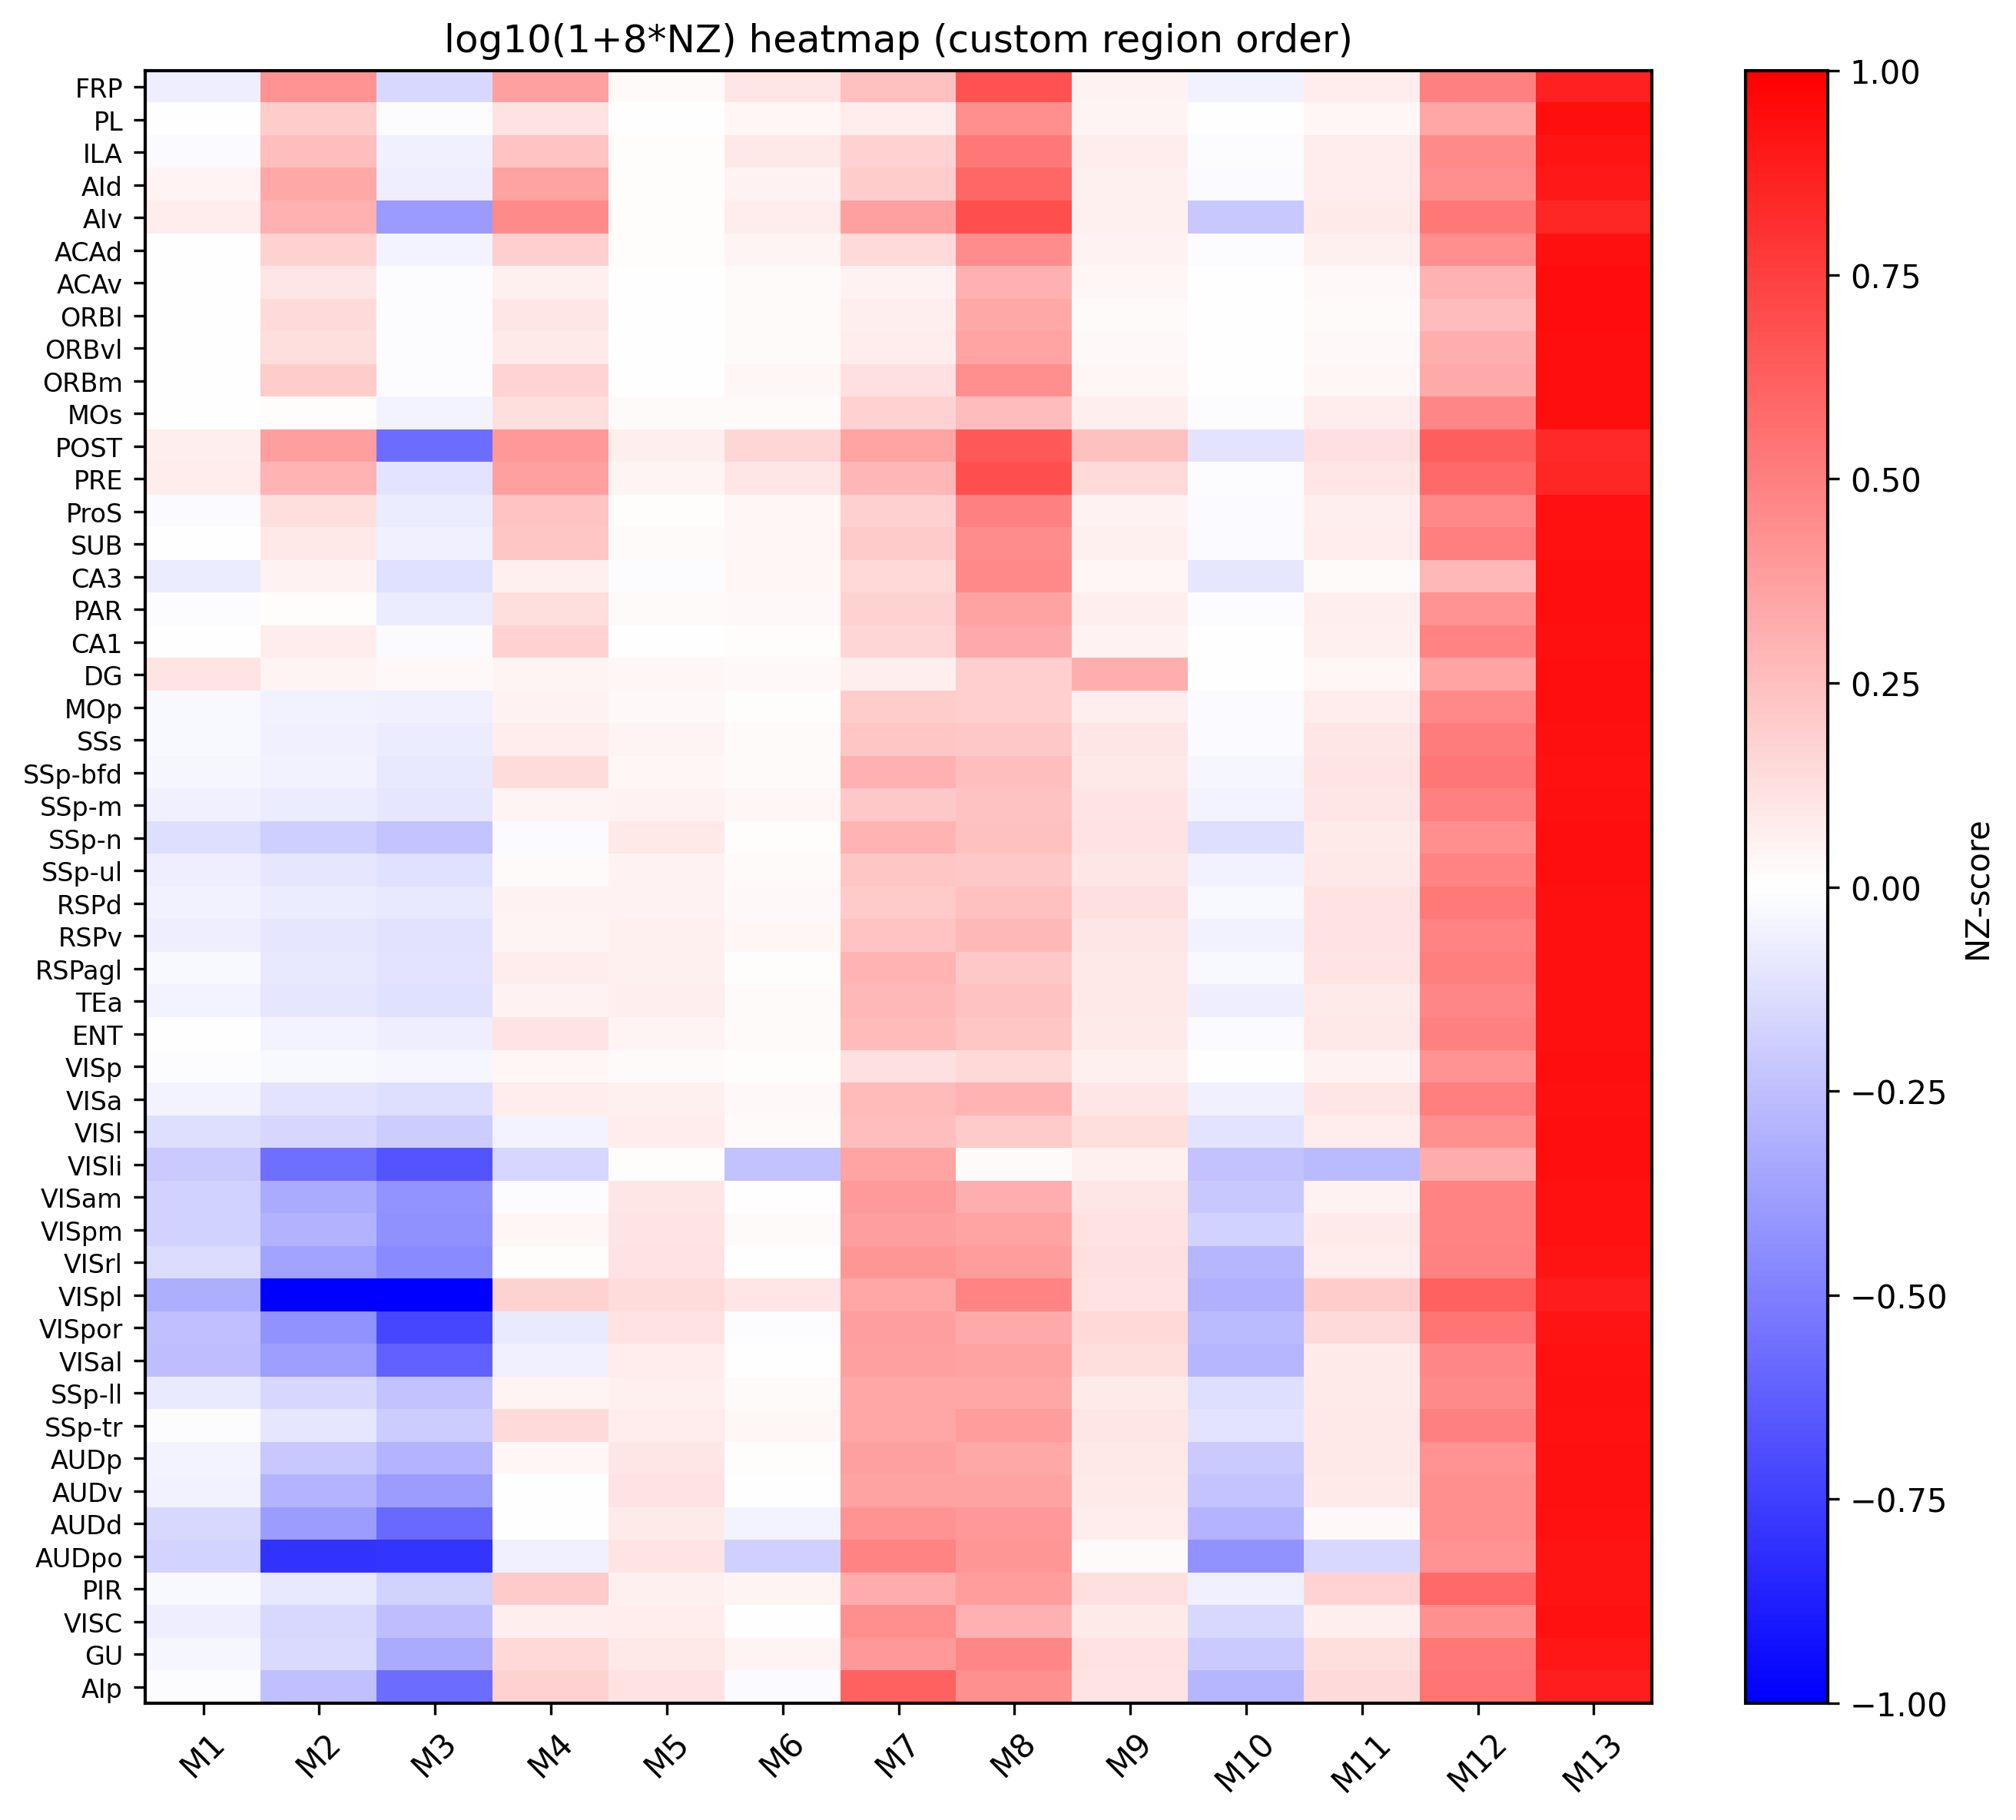

In [1]:
import pickle
import numpy as np
import umap
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering, dendrogram
from scipy.spatial.distance import pdist

import matplotlib as mpl

# ===== 提升整体分辨率 & 字体 =====
mpl.rcParams['figure.dpi'] = 300        # 屏幕显示分辨率
mpl.rcParams['savefig.dpi'] = 300       # 保存图片分辨率
mpl.rcParams['figure.figsize'] = (6, 4)
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# ==================== 1. 加载 & 提取数据 ====================
with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    data = pickle.load(f)["results"][5]

NZ, names, nodes, spars = [], [], [], []
for r, info in data.items():
    # 过滤掉不用的区域
    if r in {"SSp", "VPL", "PERI", "ECT", "PO", "PR"}:
        continue
    mr = info["motif_results"].get("0")
    if mr and (nz := np.asarray(mr["NZ"], float)).shape[0] == 13:
        names.append(r)
        NZ.append(nz)
        nodes.append(mr["node"])
        spars.append(mr["sparsity"])

NZ = np.vstack(NZ)
names = np.array(names)
nodes = np.array(nodes)
spars = np.array(spars, float)

# ==================== 2. UMAP + 聚类（这里只用来算 Z）====================
emb = umap.UMAP(
    n_neighbors=15,
    min_dist=0.15,
    metric='cosine',
    random_state=1
).fit_transform(NZ)

Z = optimal_leaf_ordering(linkage(emb, "ward"), pdist(emb))

# ========== 图1：层次聚类树（仍然用自动的叶子顺序，只用来看层次结构）==========
plt.figure(figsize=(6, 11))

rich_labels = [f"{r} (n={int(n)}, s={s:.3f})" for r, n, s in zip(names, nodes, spars)]

dendrogram(
    Z,
    orientation="left",
    labels=rich_labels,
    leaf_font_size=8.5,
    color_threshold=0,
    above_threshold_color='k'
)

plt.title("Hierarchical clustering (optimal leaf ordering)")
plt.xlabel("Distance")
plt.tight_layout()
plt.savefig("1.hierarchical_clustering_dendrogram.svg",
            bbox_inches='tight', dpi=300, transparent=True)
plt.show()

# ==================== 3. 按你给的 cluster 顺序重排 ====================

# ---- 你给的 4 个 cluster 顺序 ----
cluster1_names = [
    "FRP",
    "PL",
    "ILA",
    "AId",
    "AIv",
    "ACAd",
    "ACAv",
    "ORBl",
    "ORBvl",
    "ORBm",
    "MOs",
]

cluster2_names = [
    "POST",
    "PRE",
    "ProS",
    "SUB",
    "CA3",
    "PAR",
    "CA1",
    "DG",
]

cluster3_names = [
    "MOp",
    "SSs",
    "SSp-bfd",
    "SSp-m",
    "SSp-n",
    "SSp-ul",
    "RSPd",
    "RSPv",
    "RSPagl",
    "TEa",
    "ENT",
    "VISp",
    "VISa",
    "VISl",
    "VISli",
]

cluster4_names = [
    "VISam",
    "VISpm",
    "VISrl",
    "VISpl",
    "VISpor",
    "VISal",
    "SSp-ll",
    "SSp-tr",
    "AUDp",
    "AUDv",
    "AUDd",
    "AUDpo",
    "PIR",
    "VISC",
    "GU",
    "AIp",
]

# 合并成一个总顺序
custom_order_names = (
    cluster1_names +
    cluster2_names +
    cluster3_names +
    cluster4_names
)

# 建一个 name -> index 映射
name_to_idx = {r: i for i, r in enumerate(names)}

# 检查一下是否有名字对不上
missing = [r for r in custom_order_names if r not in name_to_idx]
extra   = [r for r in names if r not in custom_order_names]

if missing:
    print("[WARN] 这些区域在数据里找不到，会被忽略:", missing)
if extra:
    print("[WARN] 数据里还有这些区域不在你给的顺序里，会按原顺序附加在最后:", extra)

# 先按照你给的顺序挑出确实存在的
ordered_names_list = [r for r in custom_order_names if r in name_to_idx]
# 再把剩下的（如果有的话）按原顺序放在最后
ordered_names_list += [r for r in names if r not in ordered_names_list]

# 这就是你后续要用的“统一顺序”（按名字）
region_order = ordered_names_list  # <-- 以后你可以直接用这个 list

# 把它转换成索引顺序
order = np.array([name_to_idx[r] for r in region_order], dtype=int)


# 自定义 cluster 标签（1~4），按名字映射
name_to_cluster = {}
for r in cluster1_names:
    name_to_cluster[r] = 1
for r in cluster2_names:
    name_to_cluster[r] = 2
for r in cluster3_names:
    name_to_cluster[r] = 3
for r in cluster4_names:
    name_to_cluster[r] = 4

# 对没有出现在 4 个列表里的（如果有），给个 0 类
labels = np.array([name_to_cluster.get(r, 0) for r in names])

# 按新顺序重排所有数组
NZ     = sort_by_order(NZ)
names  = sort_by_order(names)
nodes  = sort_by_order(nodes)
spars  = sort_by_order(spars)
labels = sort_by_order(labels)
emb    = sort_by_order(emb)

# ==================== 图2：UMAP ====================
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 5))


colors = ["#F18D00","#1f77b4","#2ca02c","#d62728"]
for c in sorted(np.unique(labels)):
    lab = "Unassigned" if c == 0 else f"Cluster {c}"
    m = labels == c
    plt.scatter(emb[m, 0], emb[m, 1], label=lab, s=60, c=colors[c-1] ,alpha=0.85, edgecolors="white", linewidths=0.6)

texts = []
for (x, y), n in zip(emb, names):
    texts.append(plt.text(x, y, n, fontsize=7, ha="center", va="center"))

adjust_text(
    texts,
    x=emb[:, 0], y=emb[:, 1],
    expand_points=(1.2, 1.4),
    expand_text=(1.2, 1.4),
    force_points=0.15,
    force_text=0.25,
    # arrowprops=dict(arrowstyle='-', lw=0.4, color='0.4', alpha=0.7),
)

plt.legend(frameon=False)
plt.title("UMAP of brain regions (custom cluster order)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.savefig("Fig s4b.svg", bbox_inches="tight", dpi=300, transparent=True)
plt.show()
# ==================== 图3：NZ-score 热图 ====================
plt.figure(figsize=(9, 8))
im = plt.imshow(np.nan_to_num(np.log10(1 + 8*NZ), nan=-100.0, posinf=-100.0, neginf=-100.0), aspect='auto', cmap='bwr', vmin=-1, vmax=1)
plt.colorbar(im, label="NZ-score")

# y 轴用当前 names（已经是按你给的顺序排好的）
plt.yticks(range(len(names)), names, fontsize=8)
plt.xticks(range(13), [f"M{i+1}" for i in range(13)], rotation=45)
plt.title("log10(1+8*NZ) heatmap (custom region order)")
plt.tight_layout()
plt.savefig("3.nz_score_heatmap.svg",
            bbox_inches='tight', dpi=300, transparent=True)
plt.show()

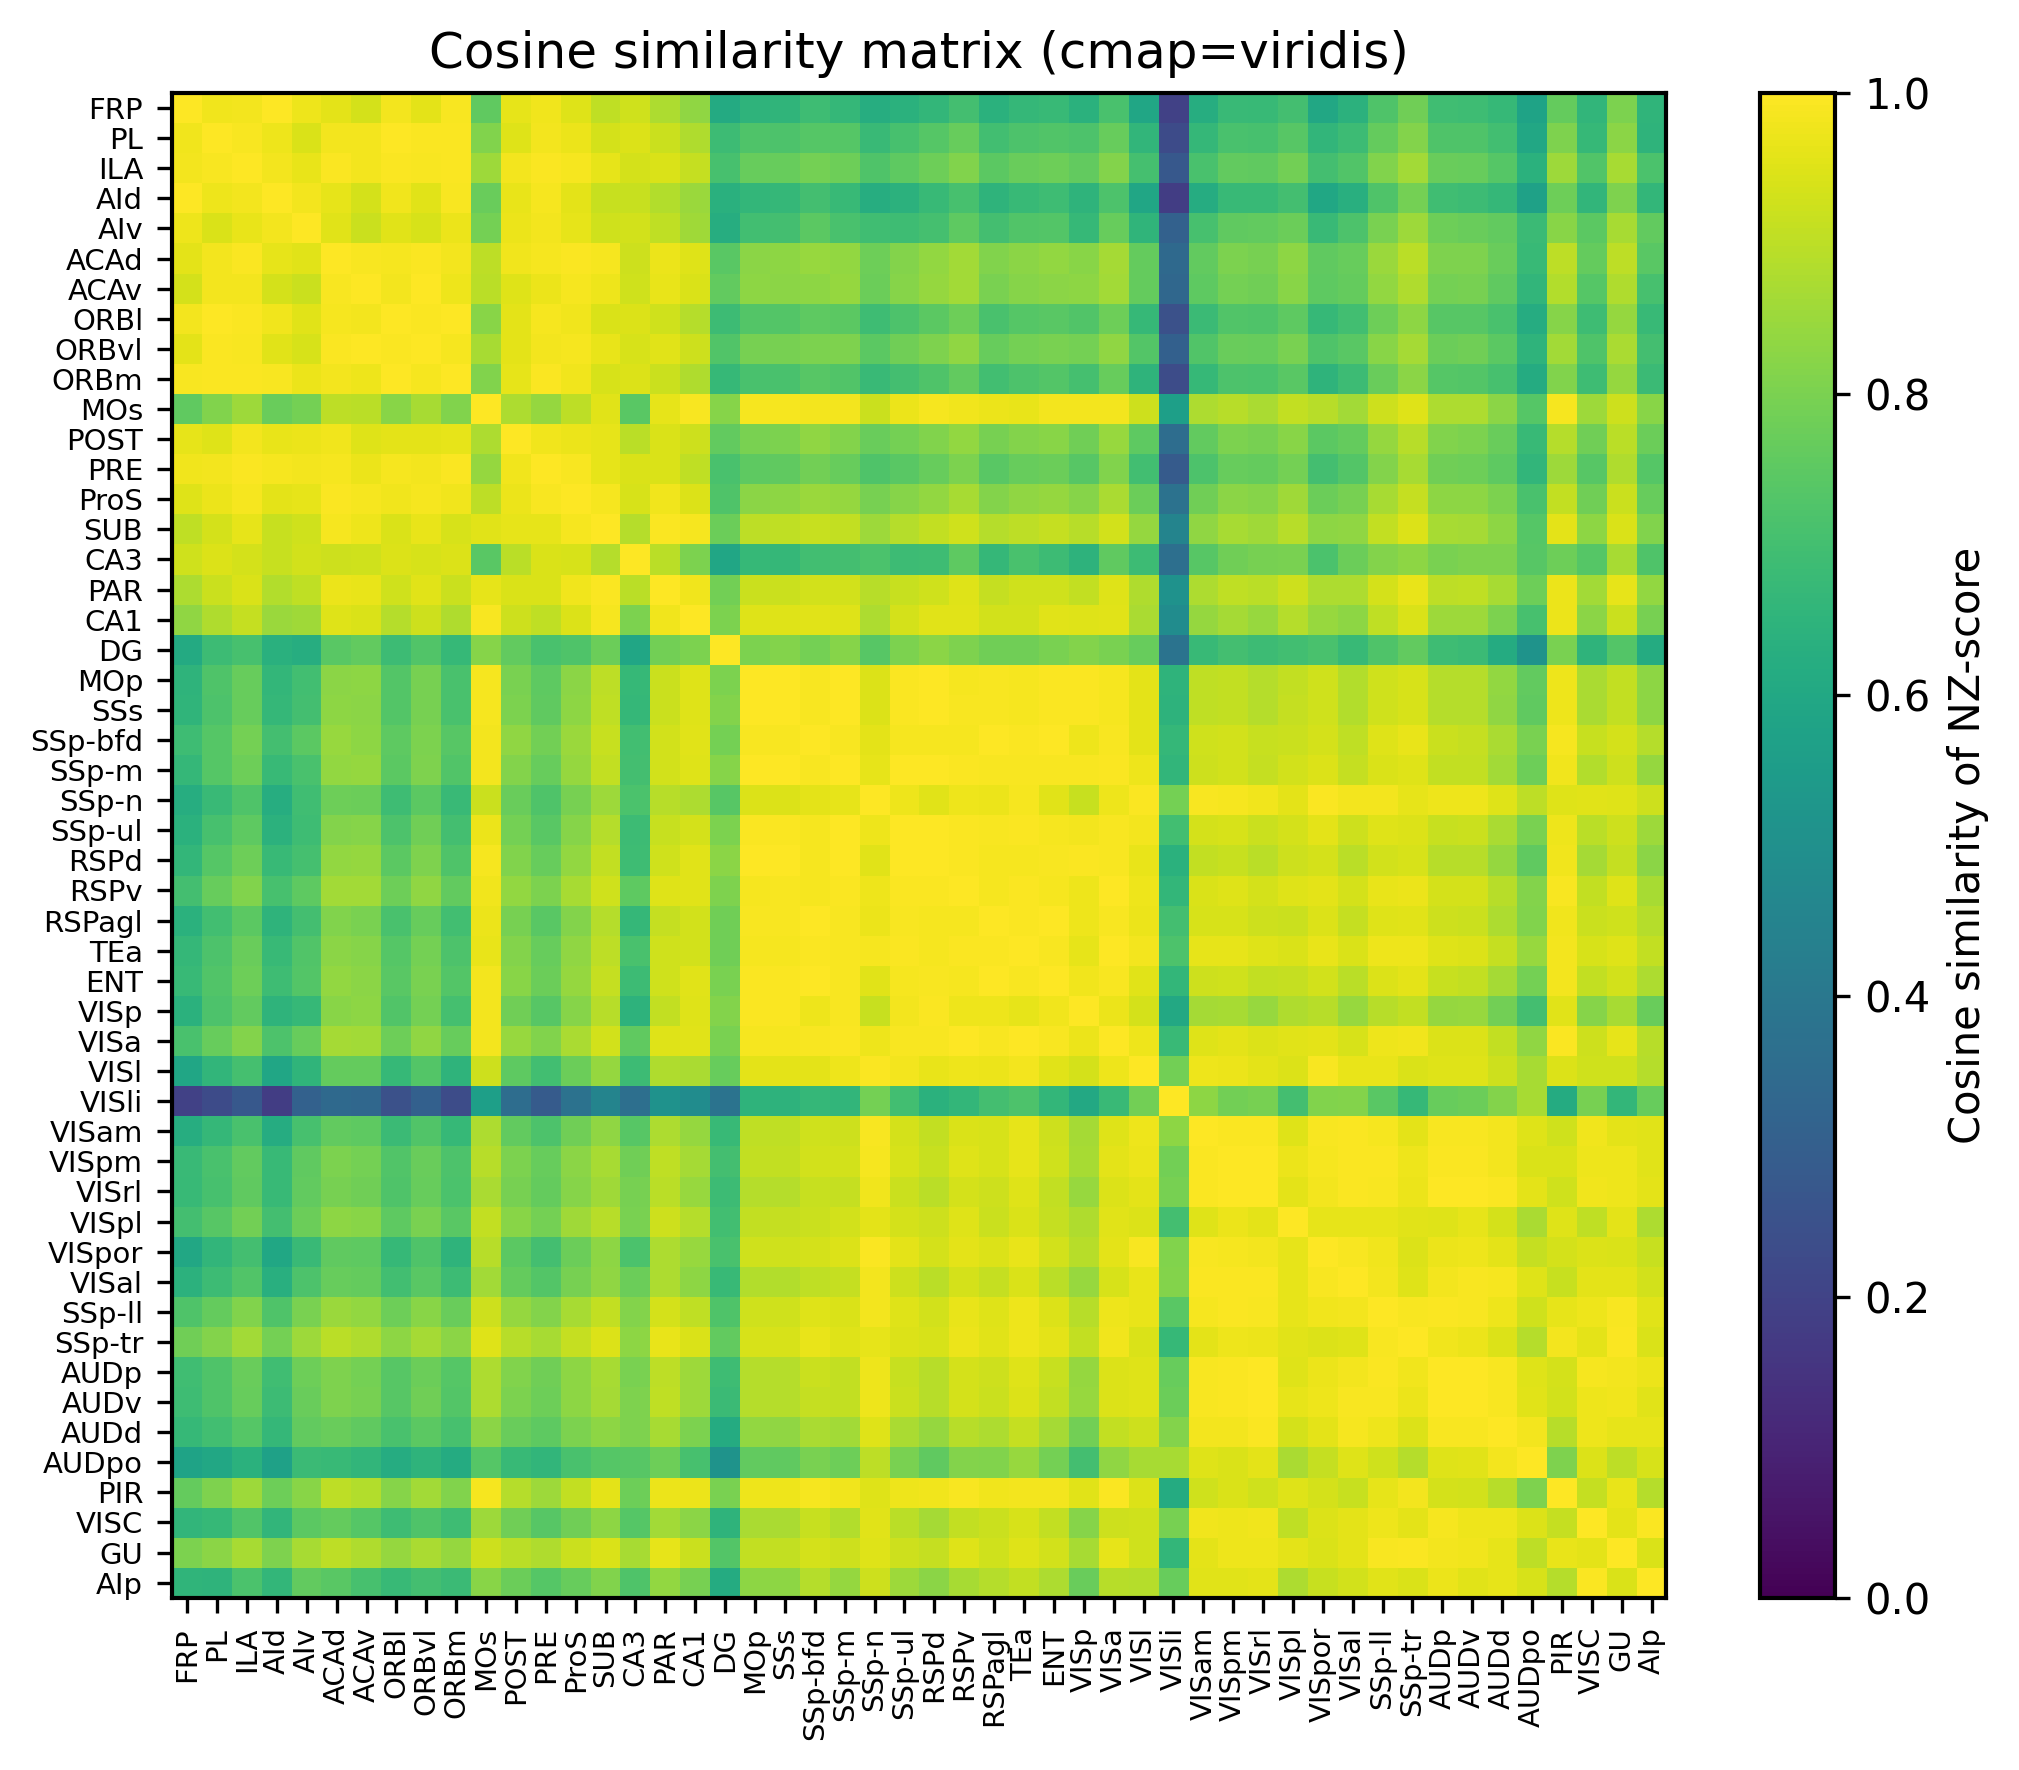

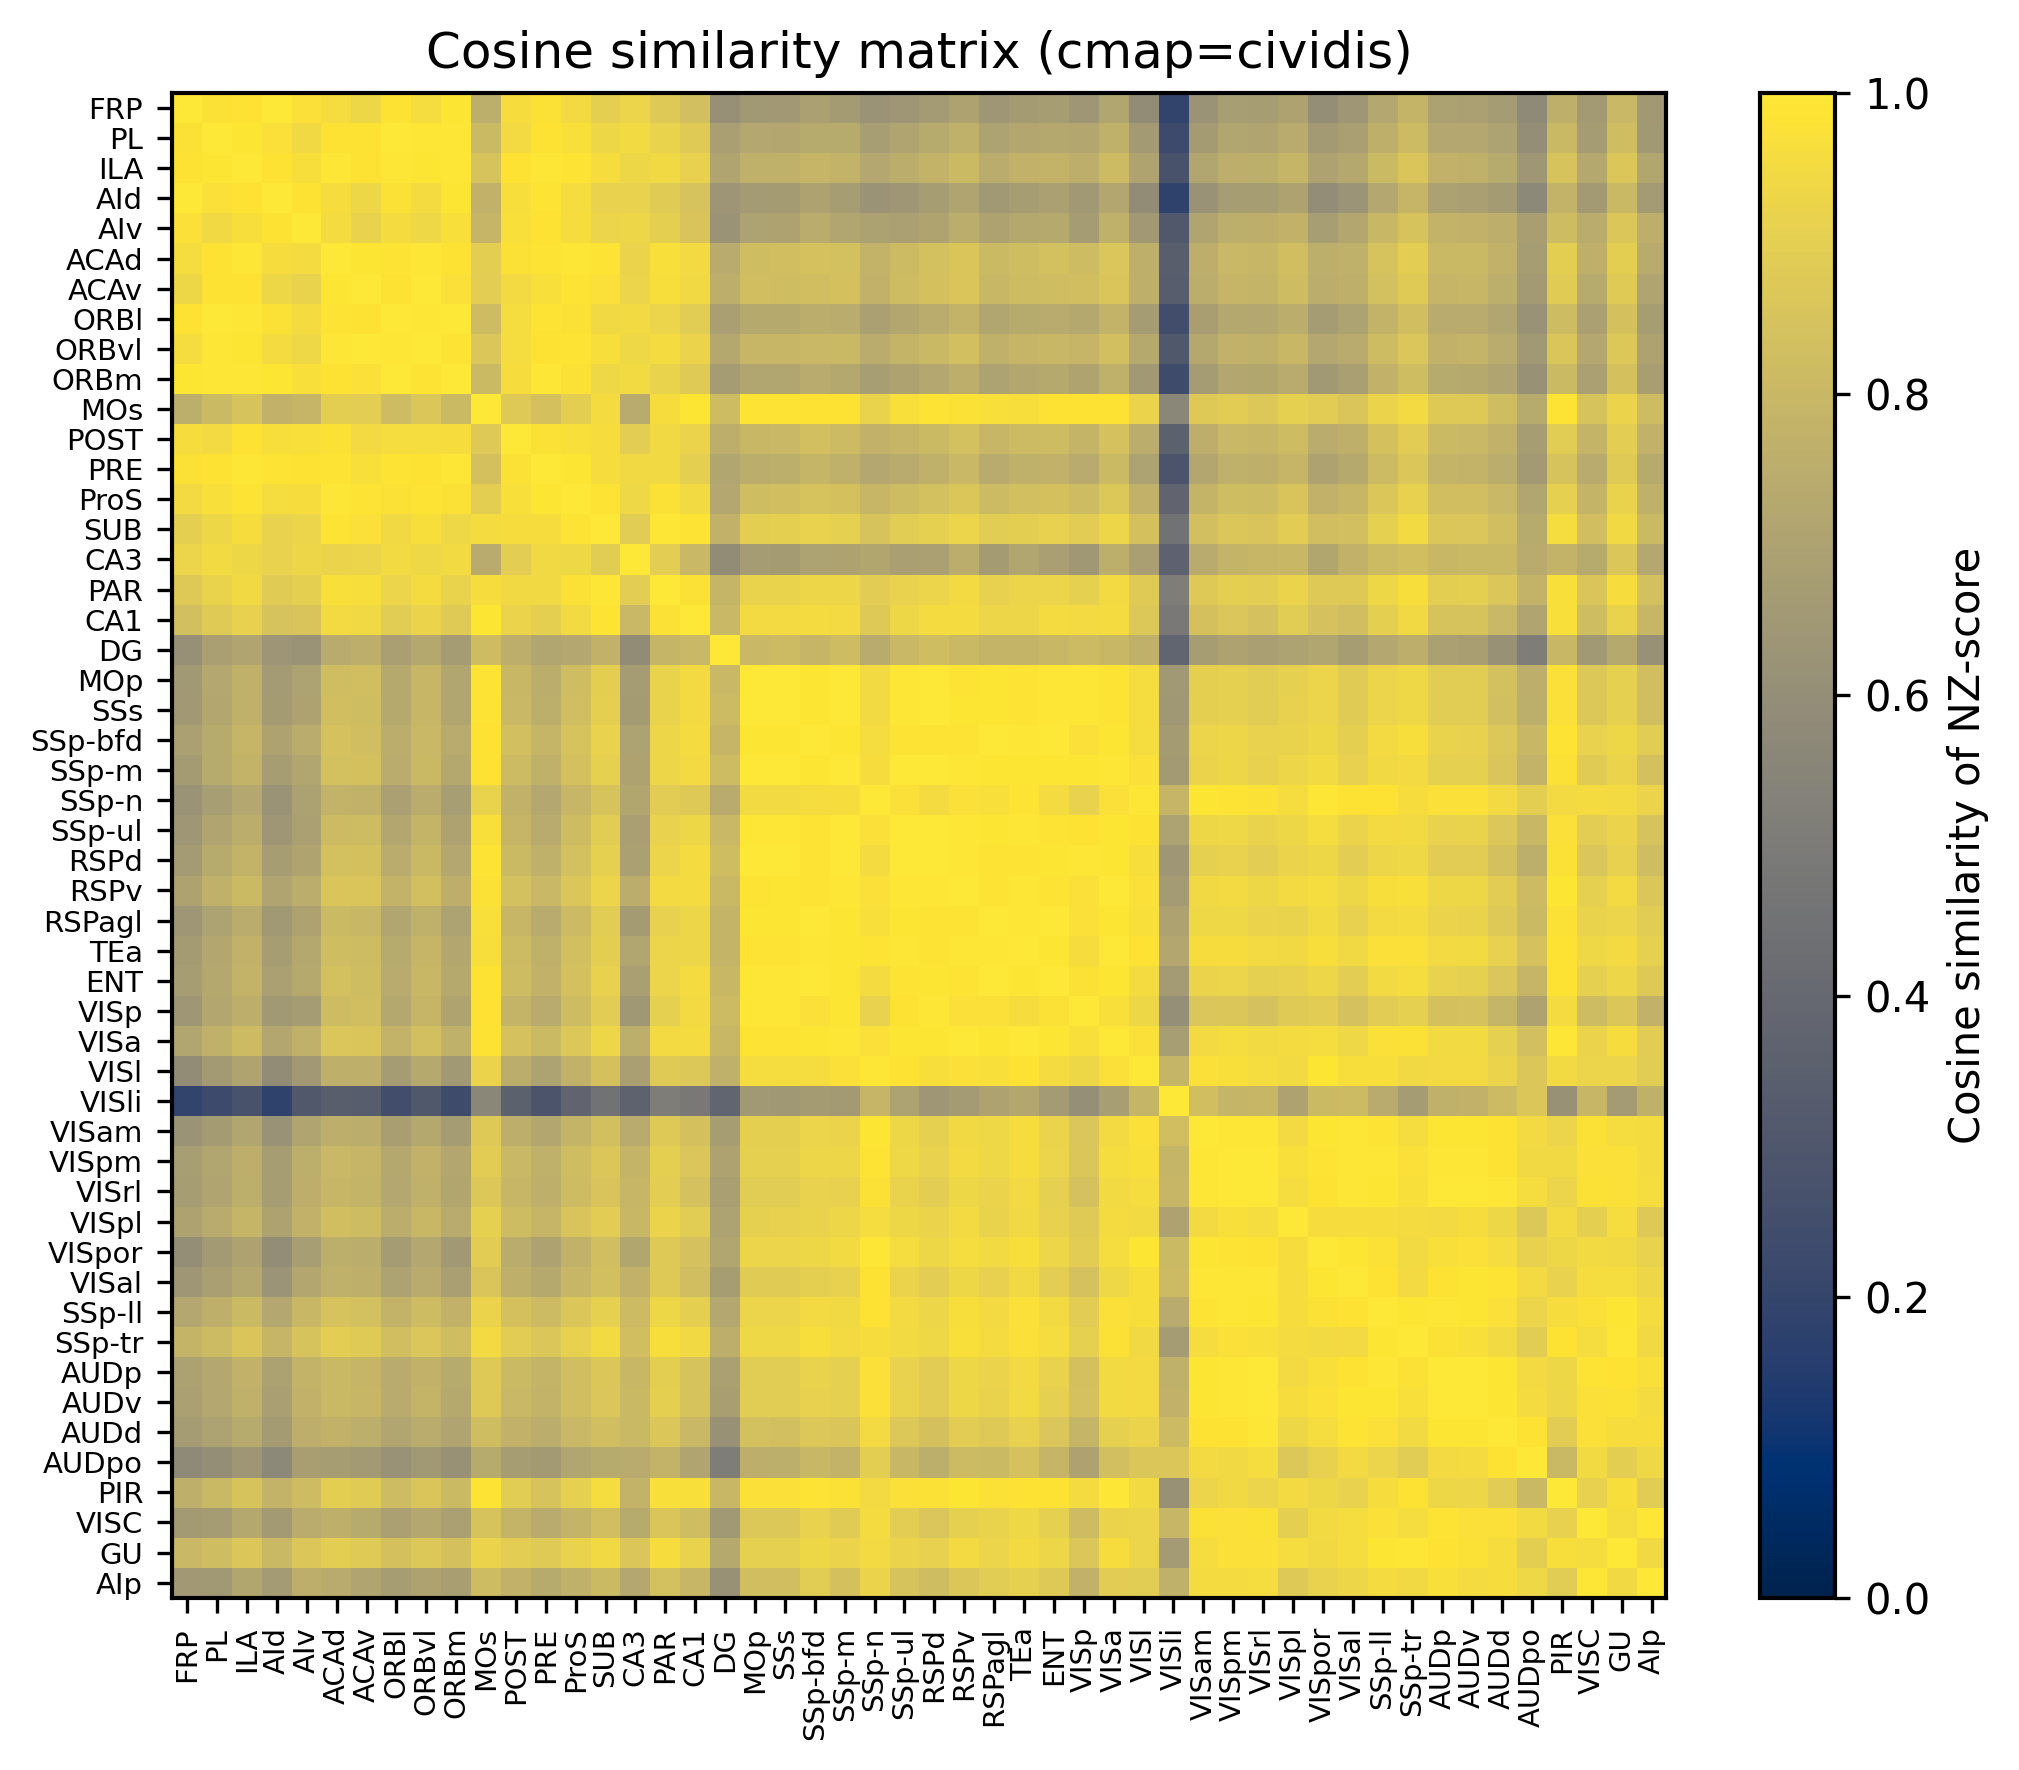

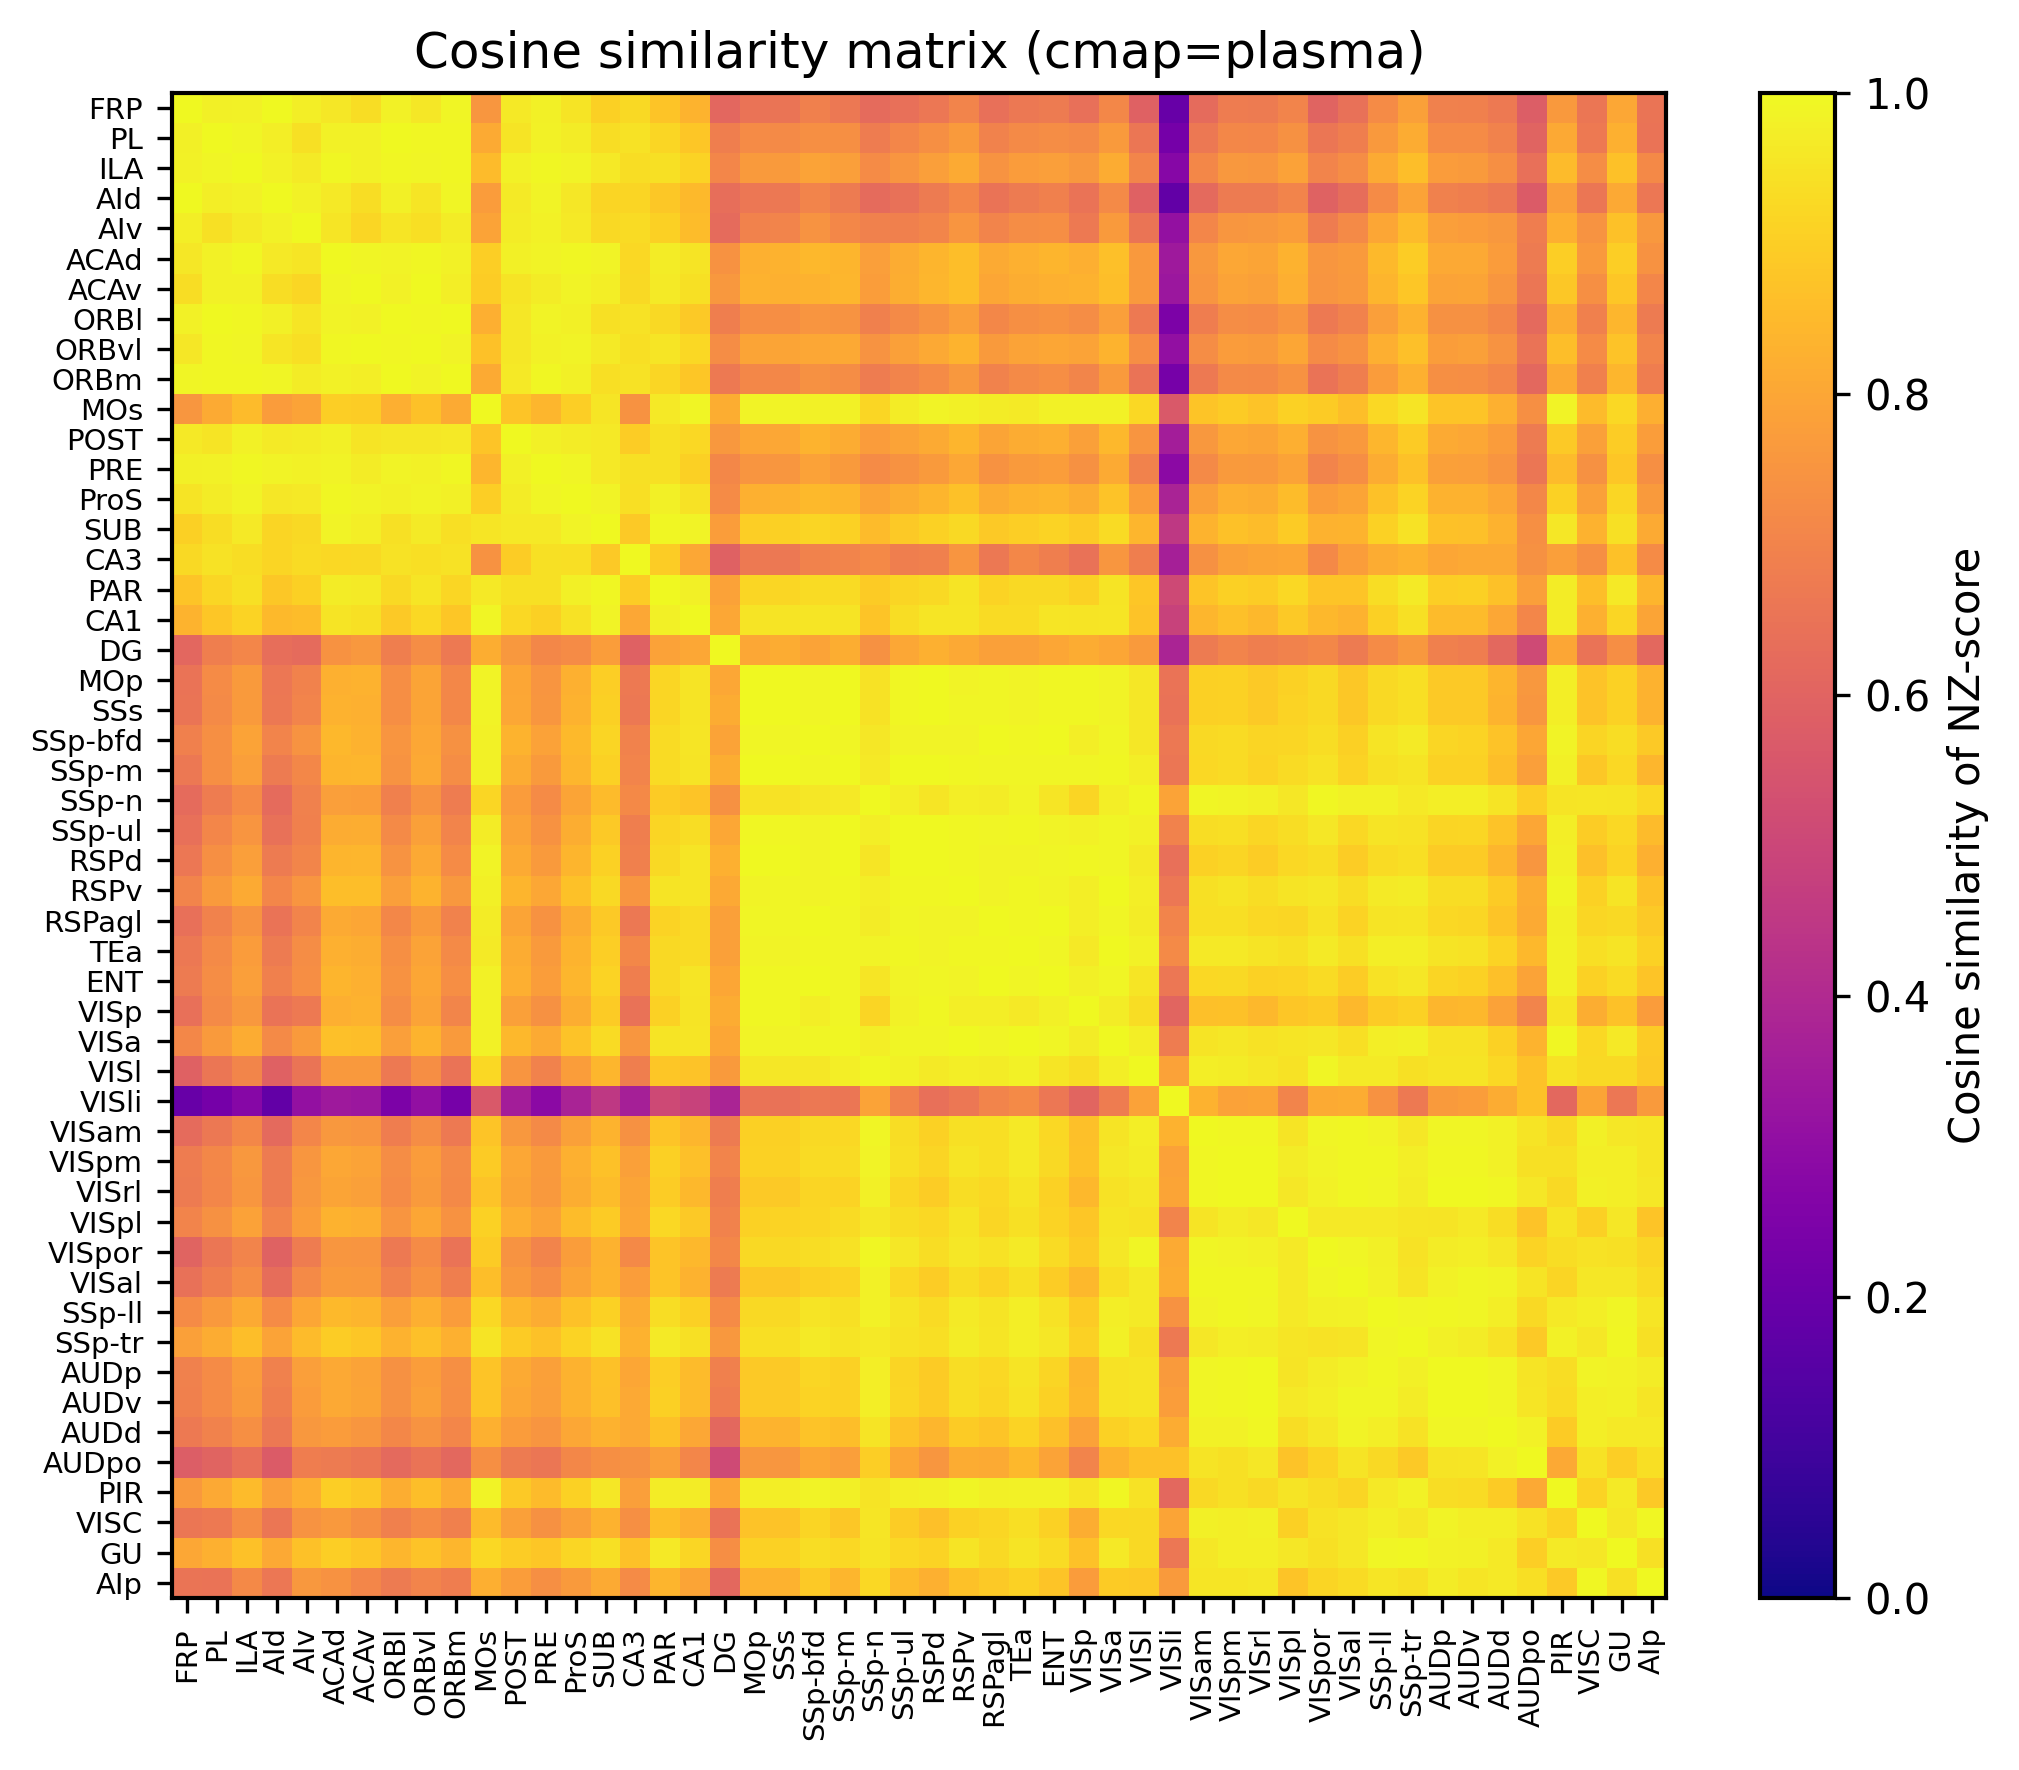

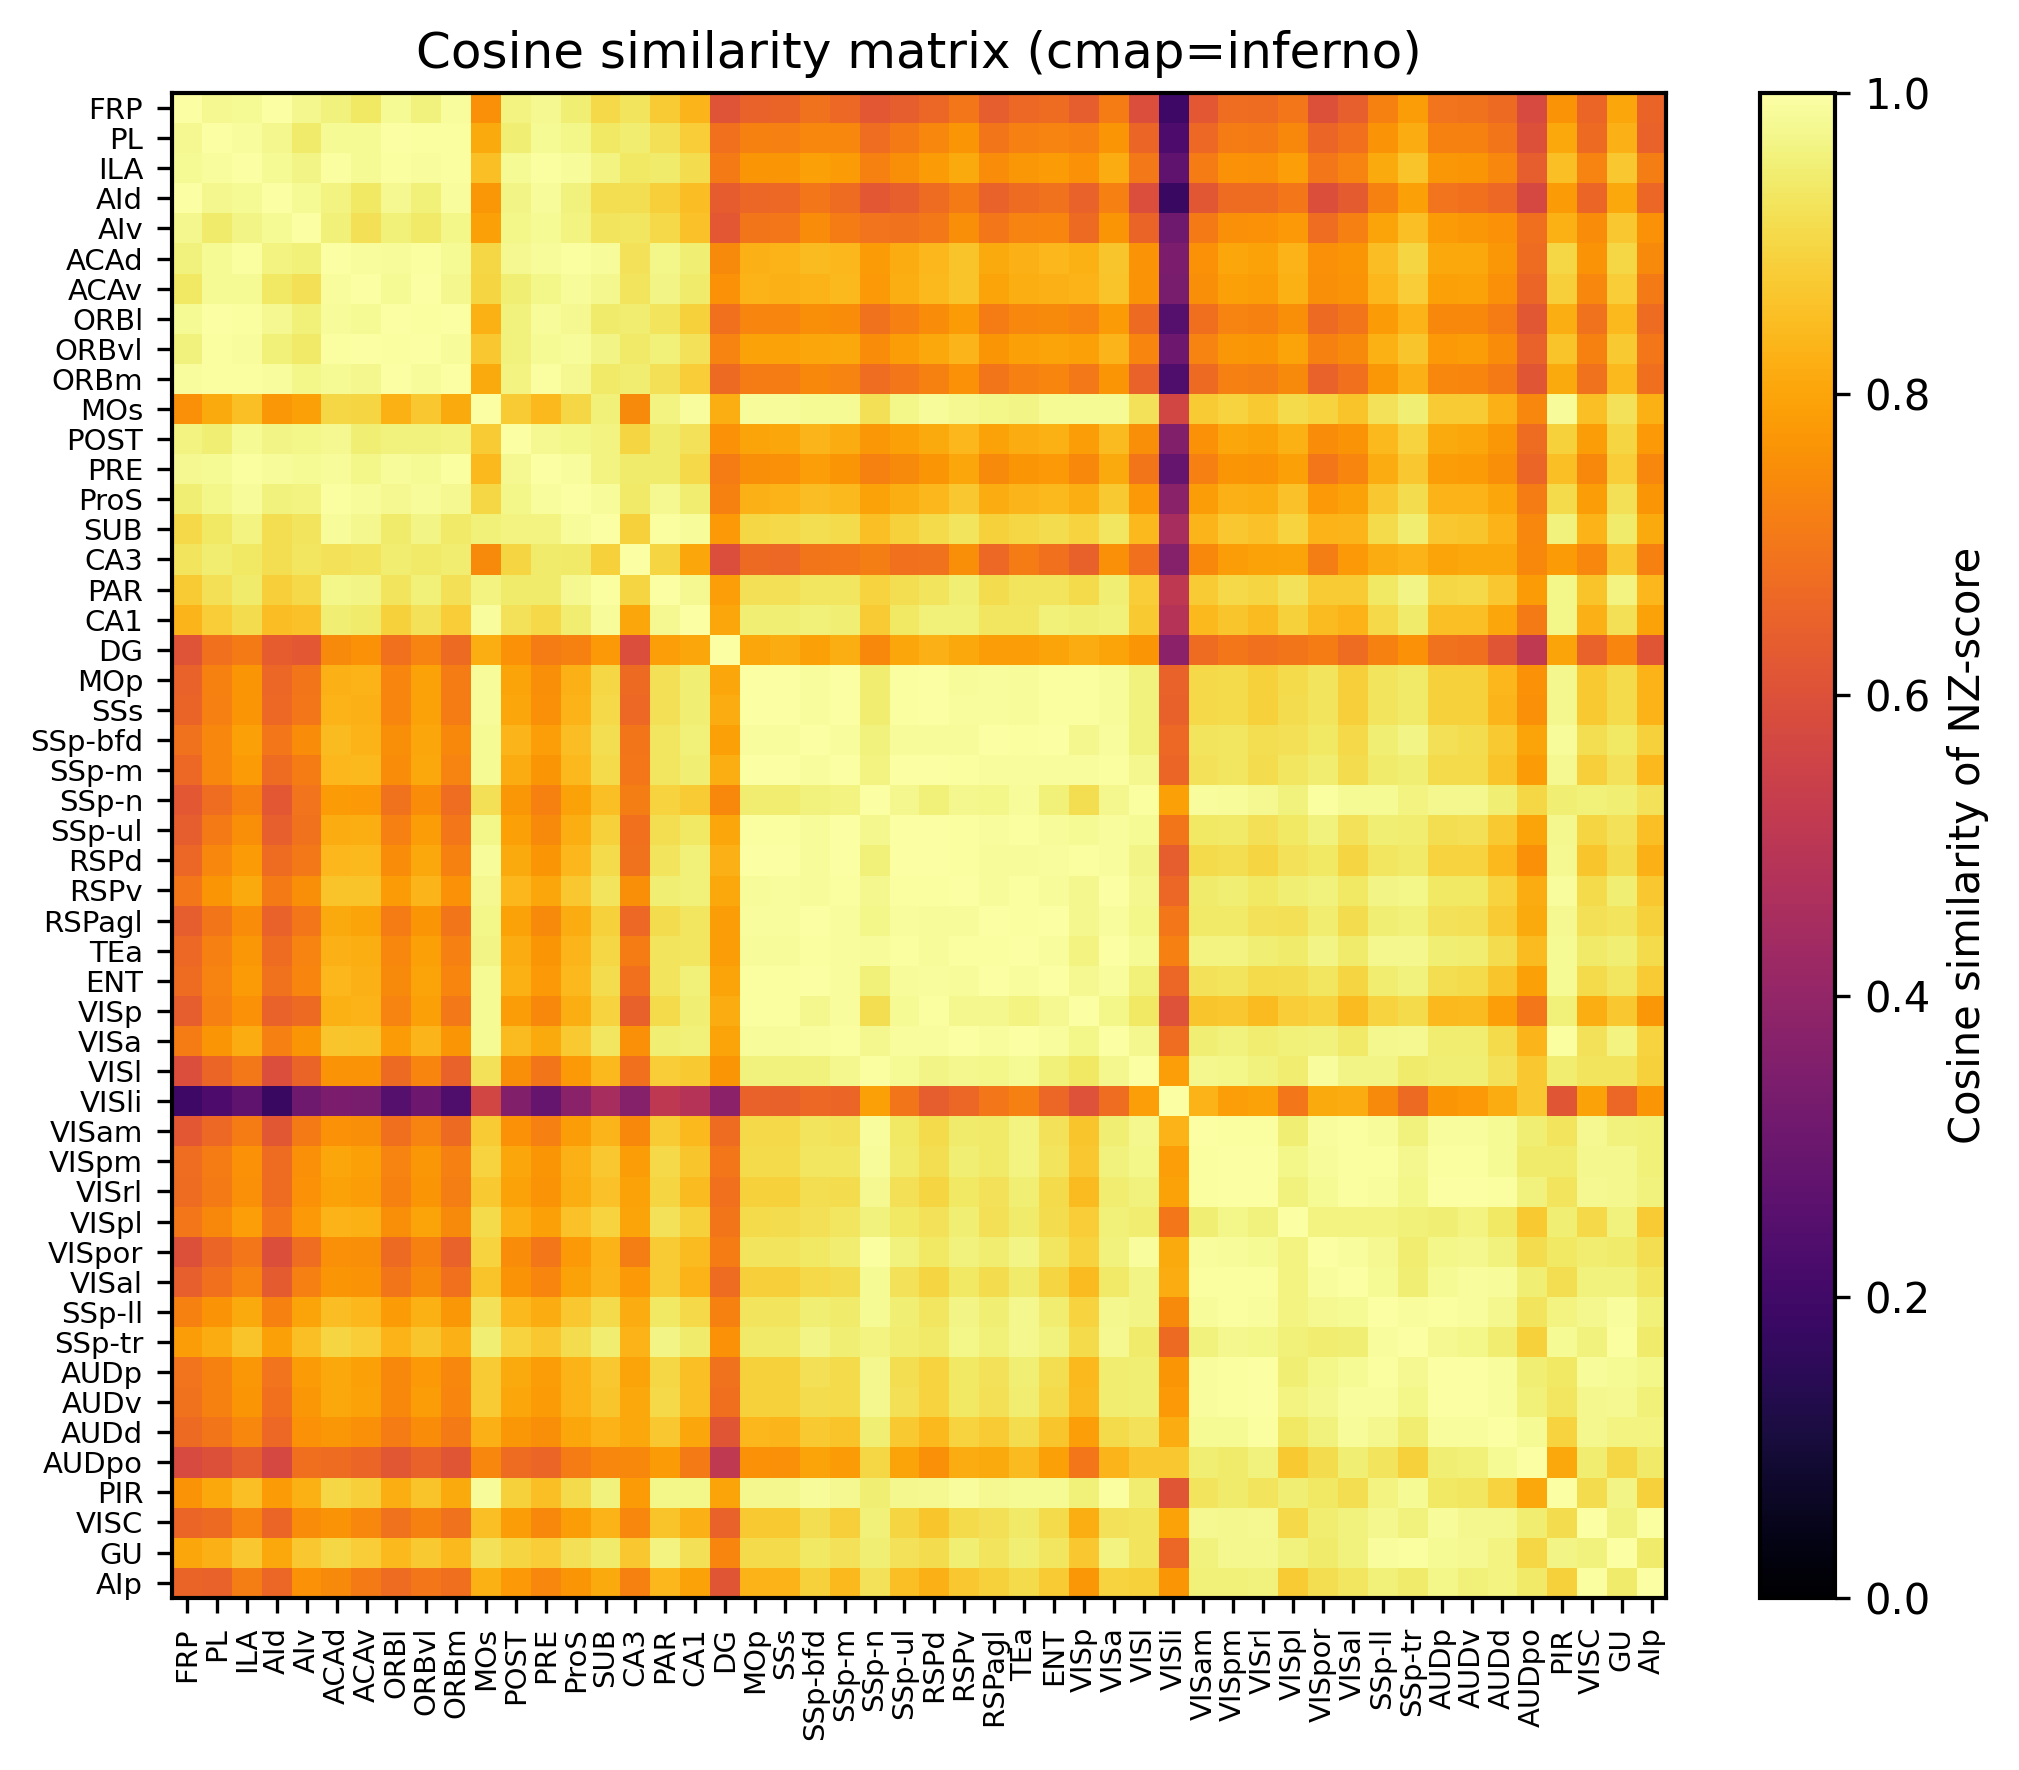

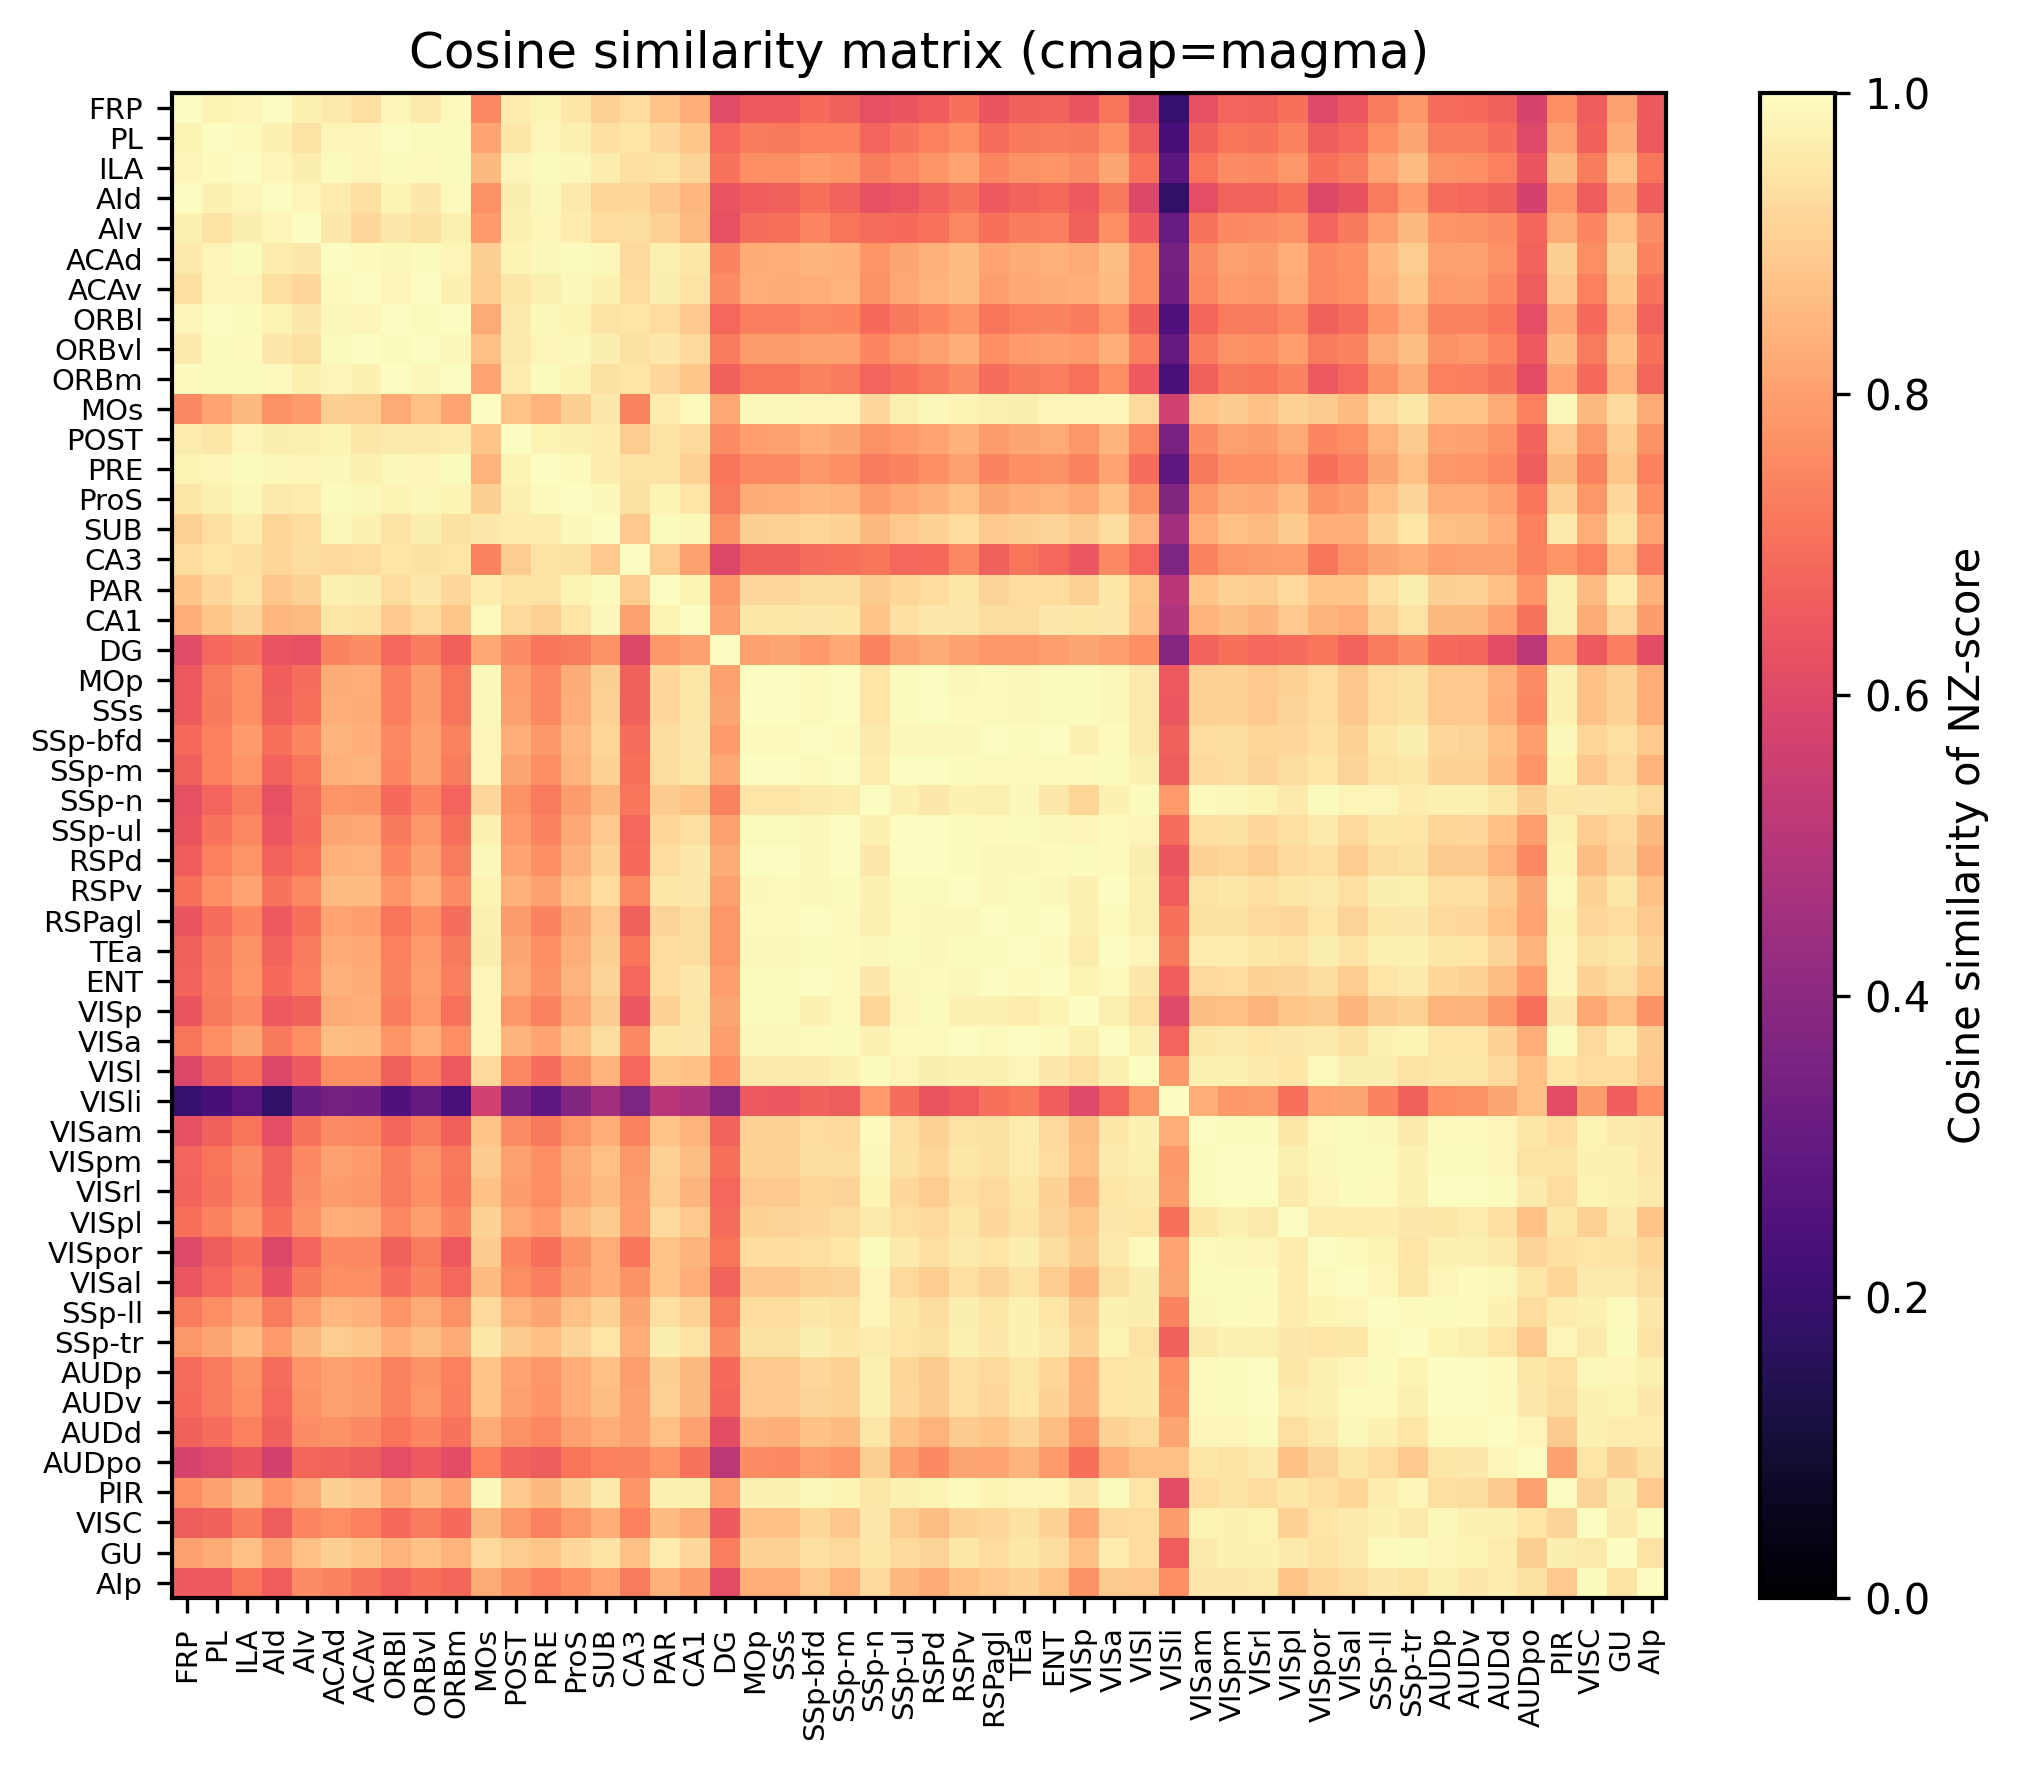

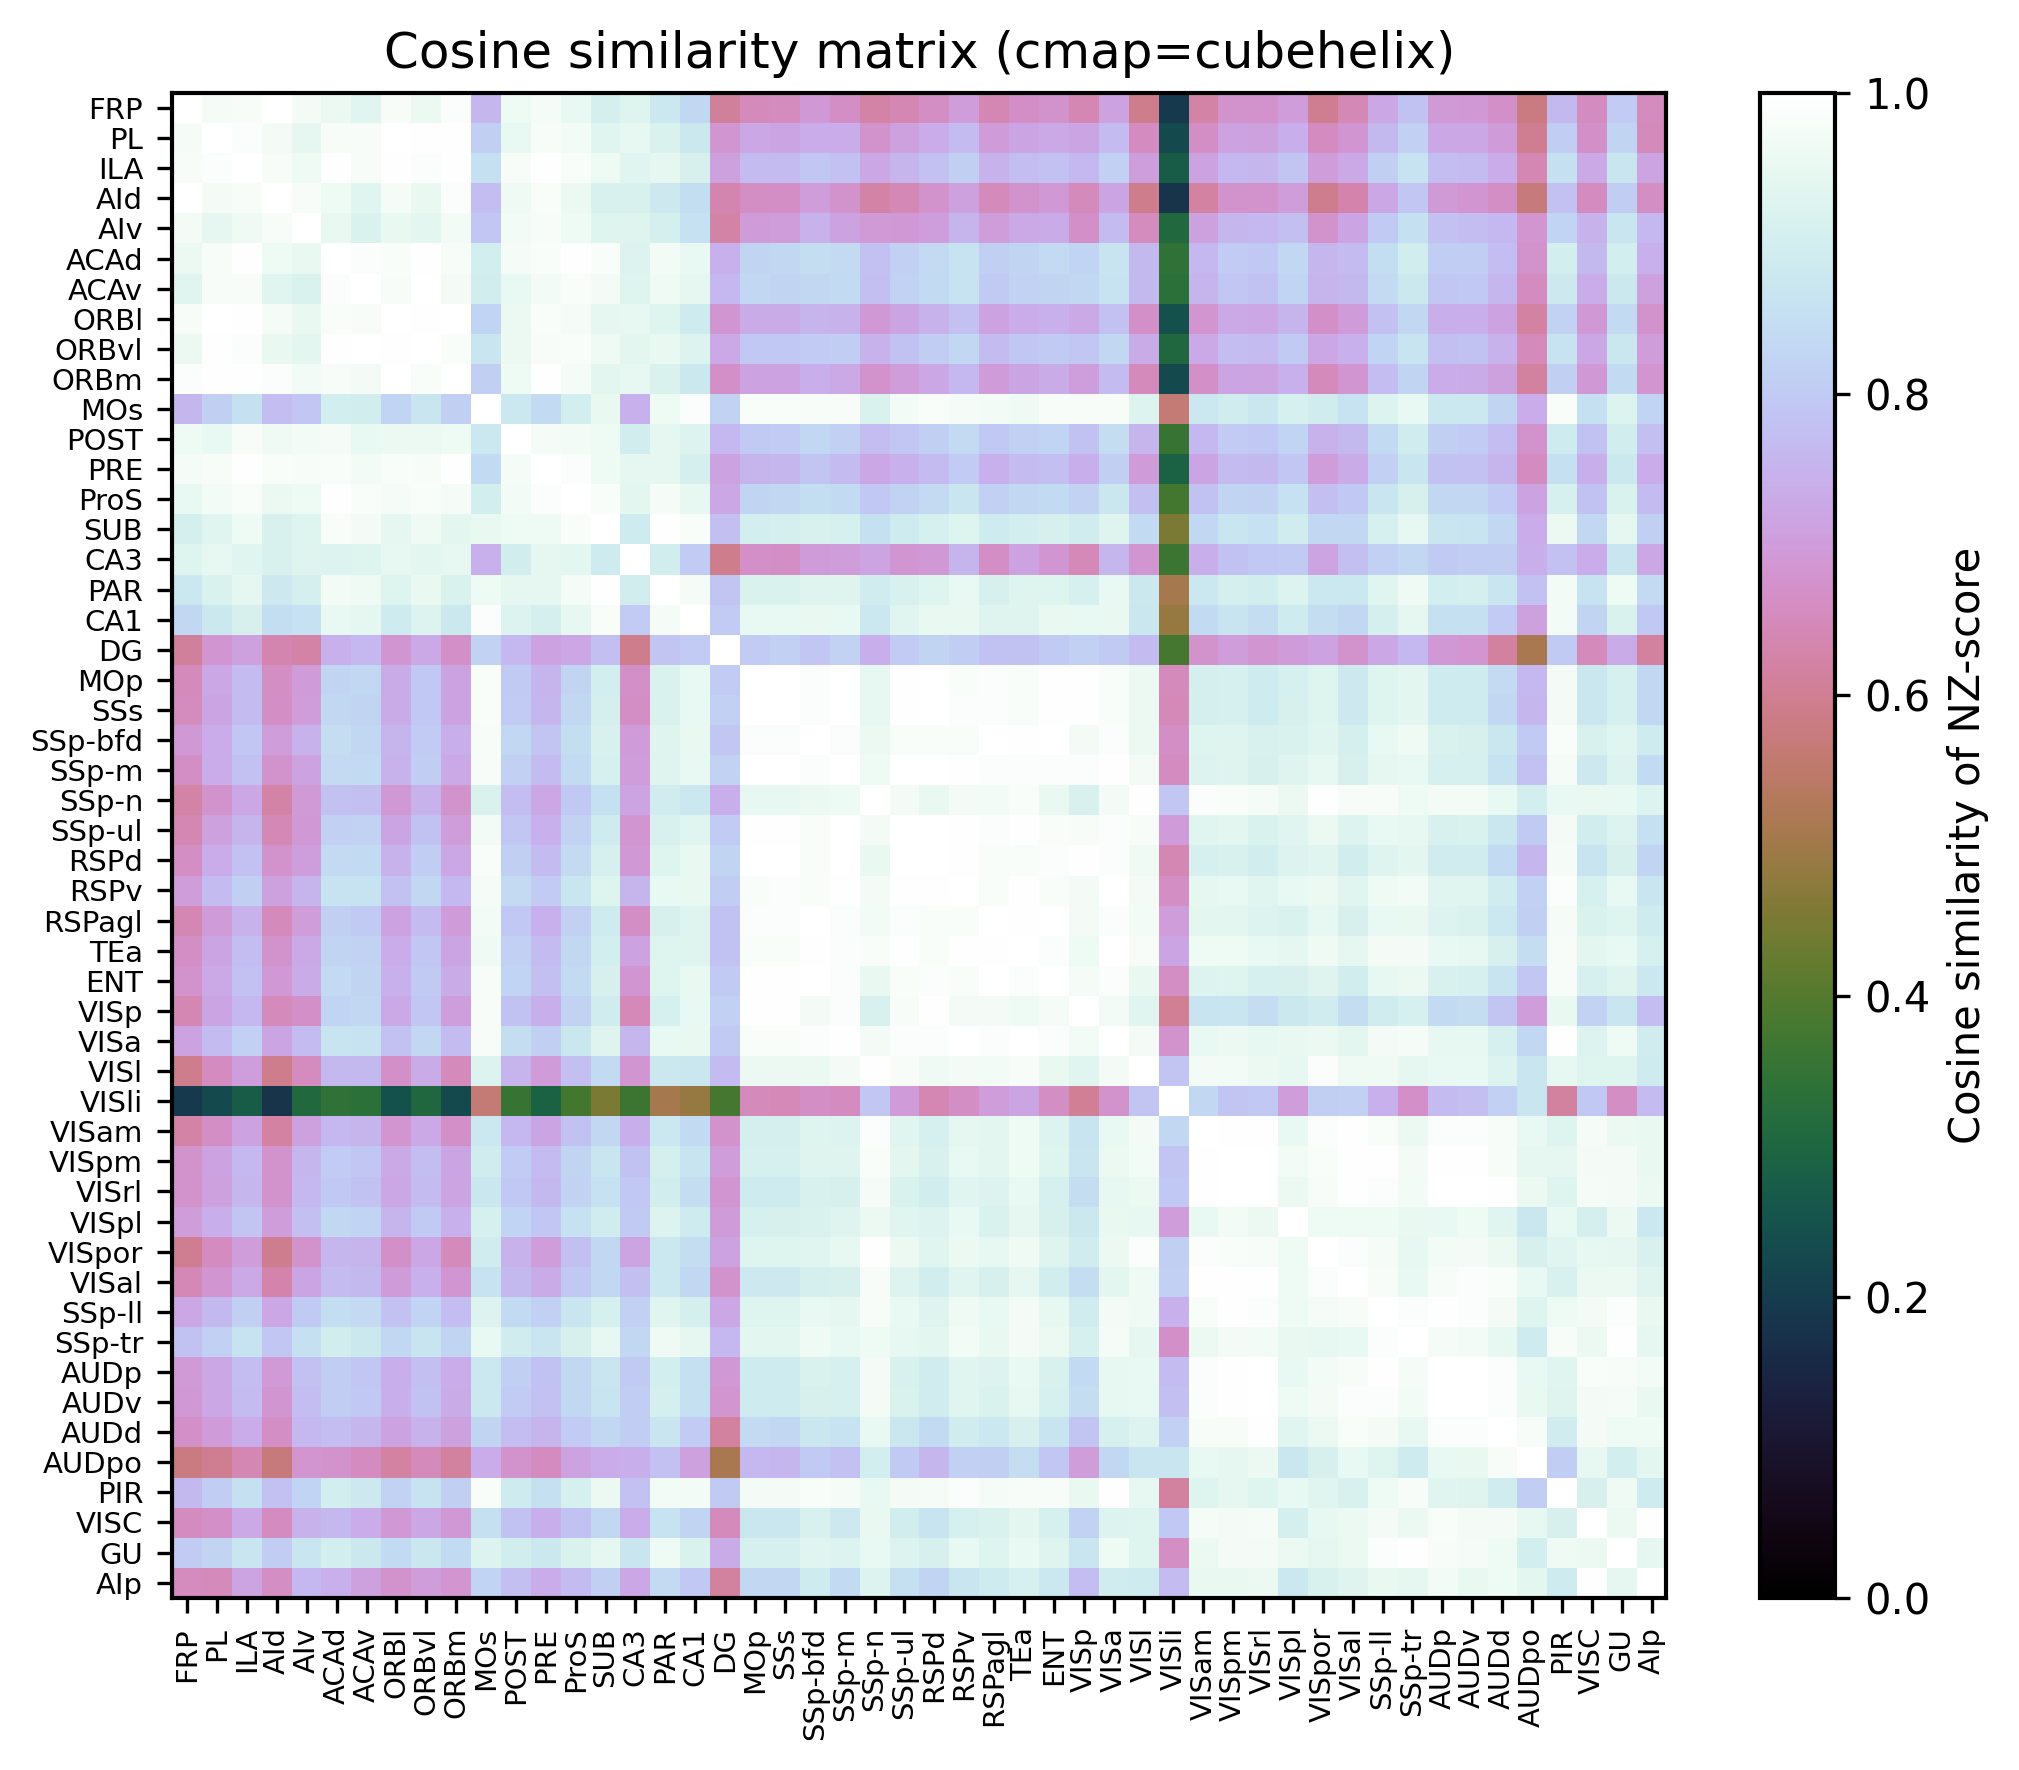

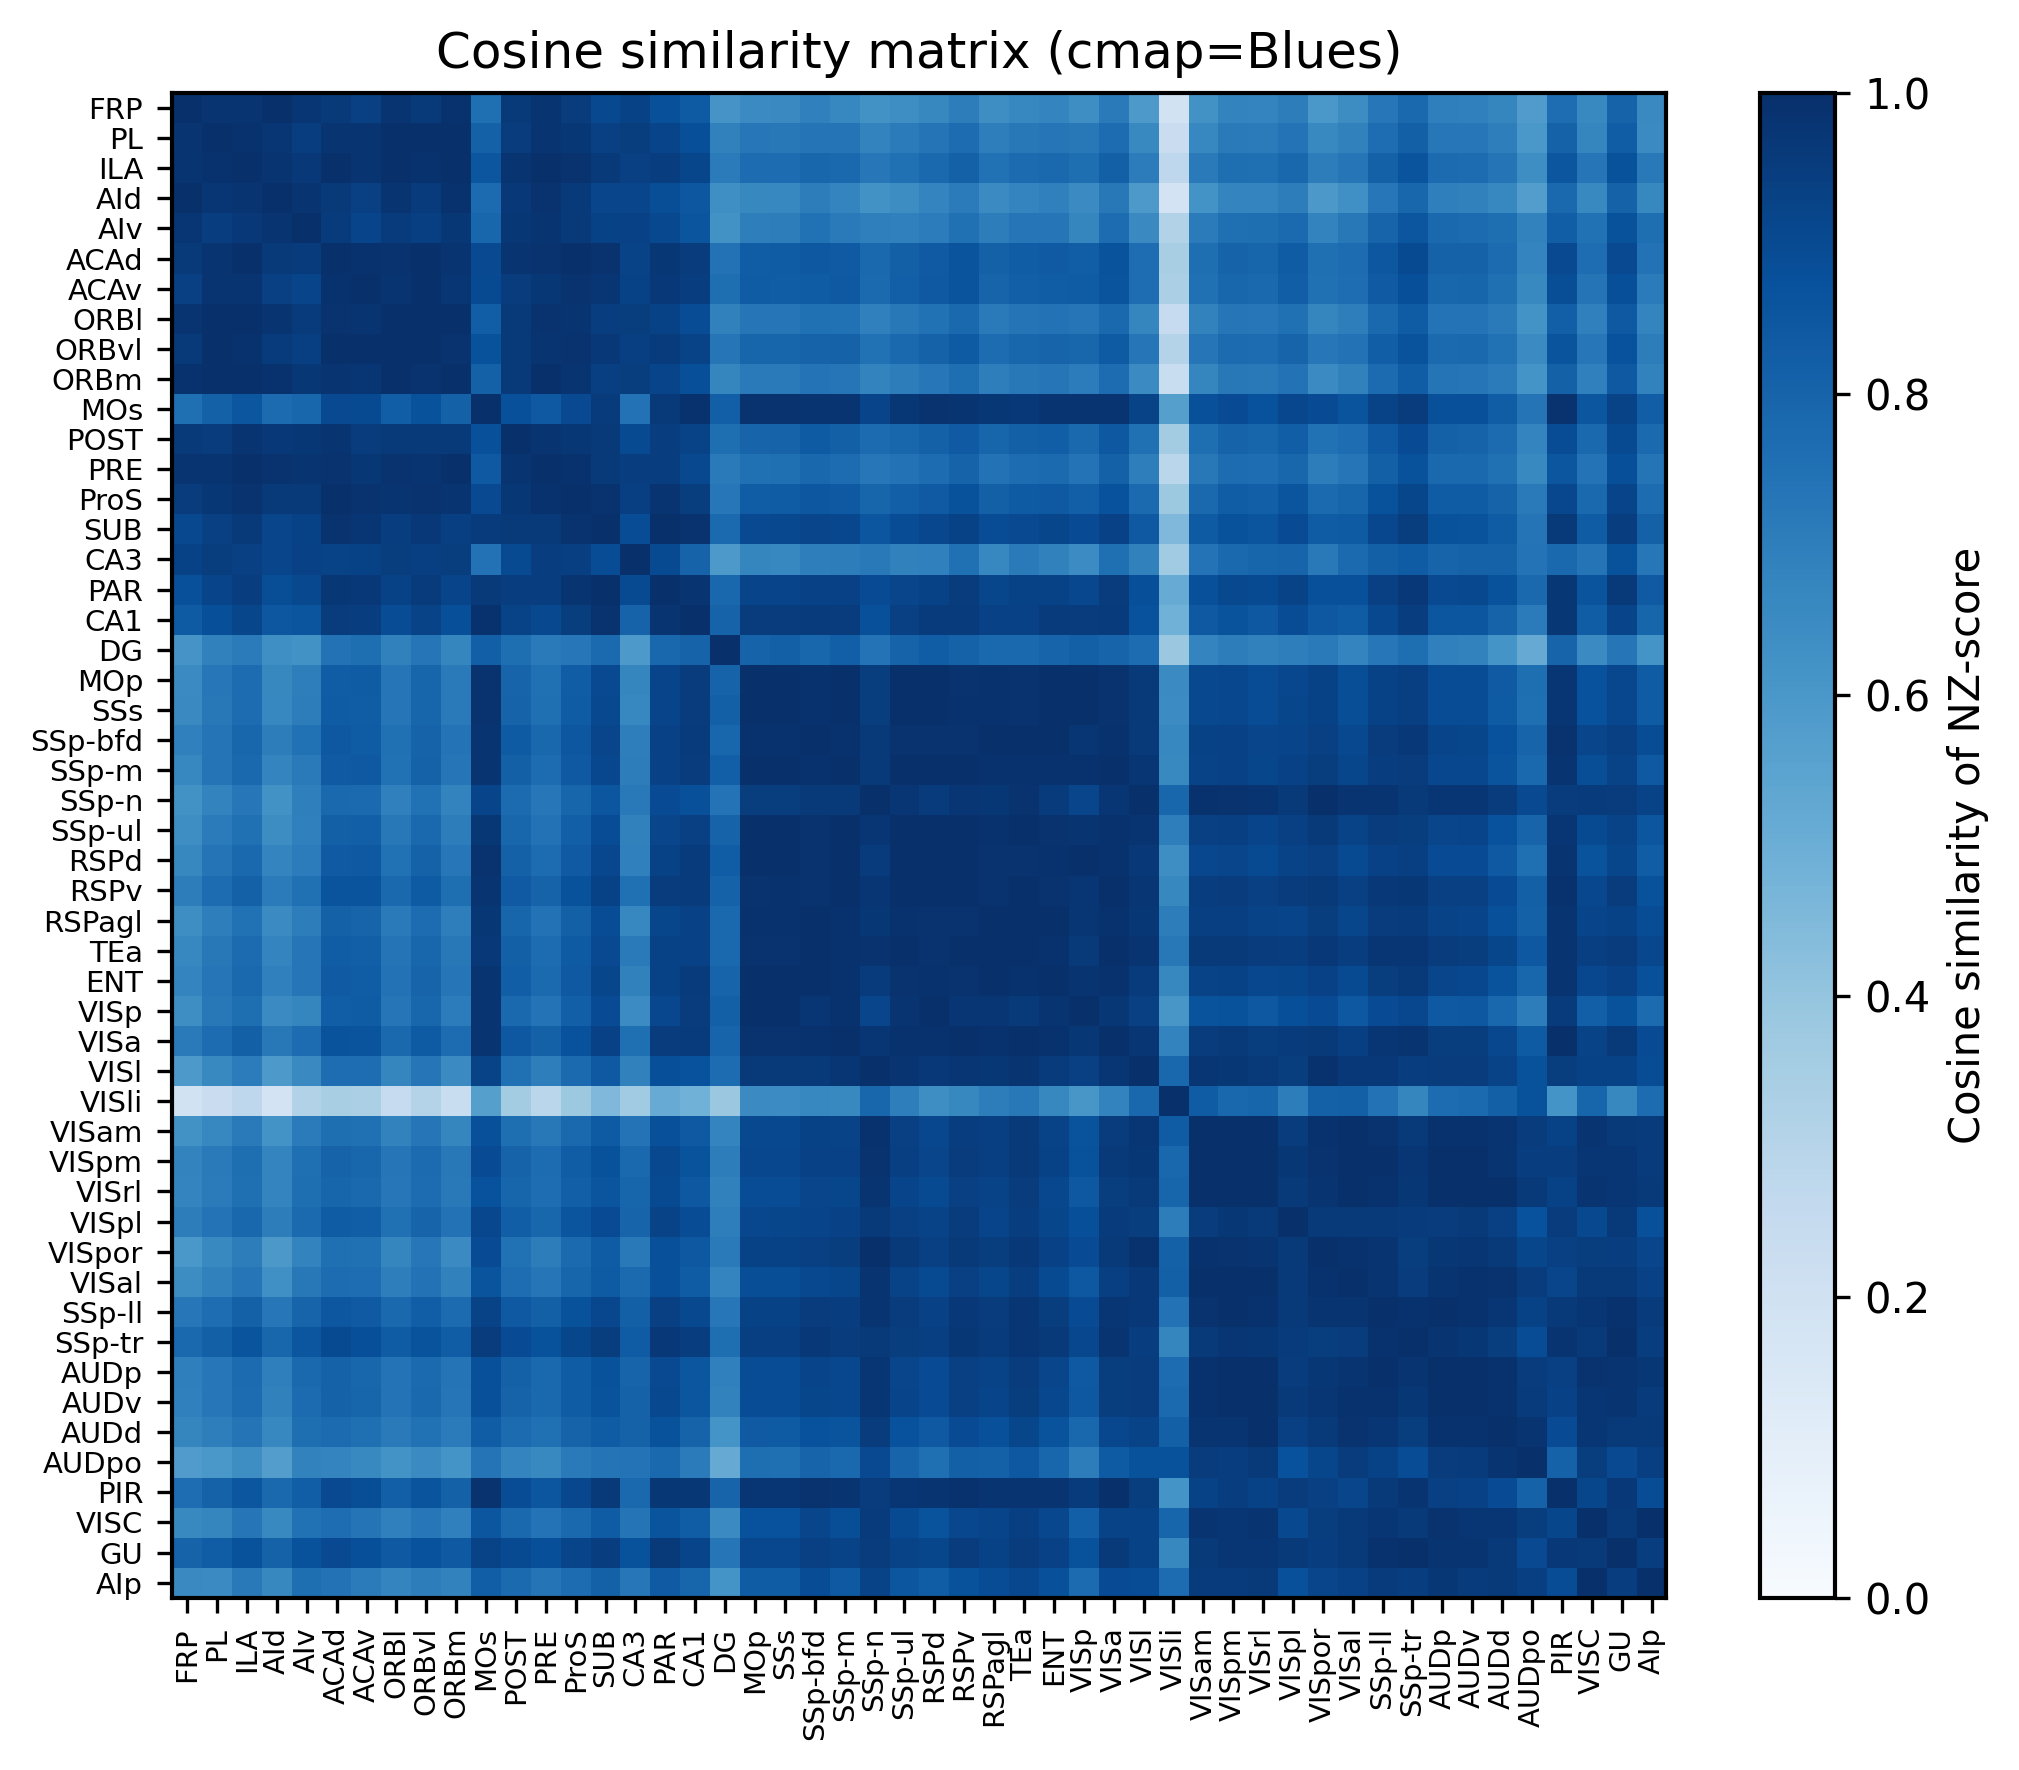

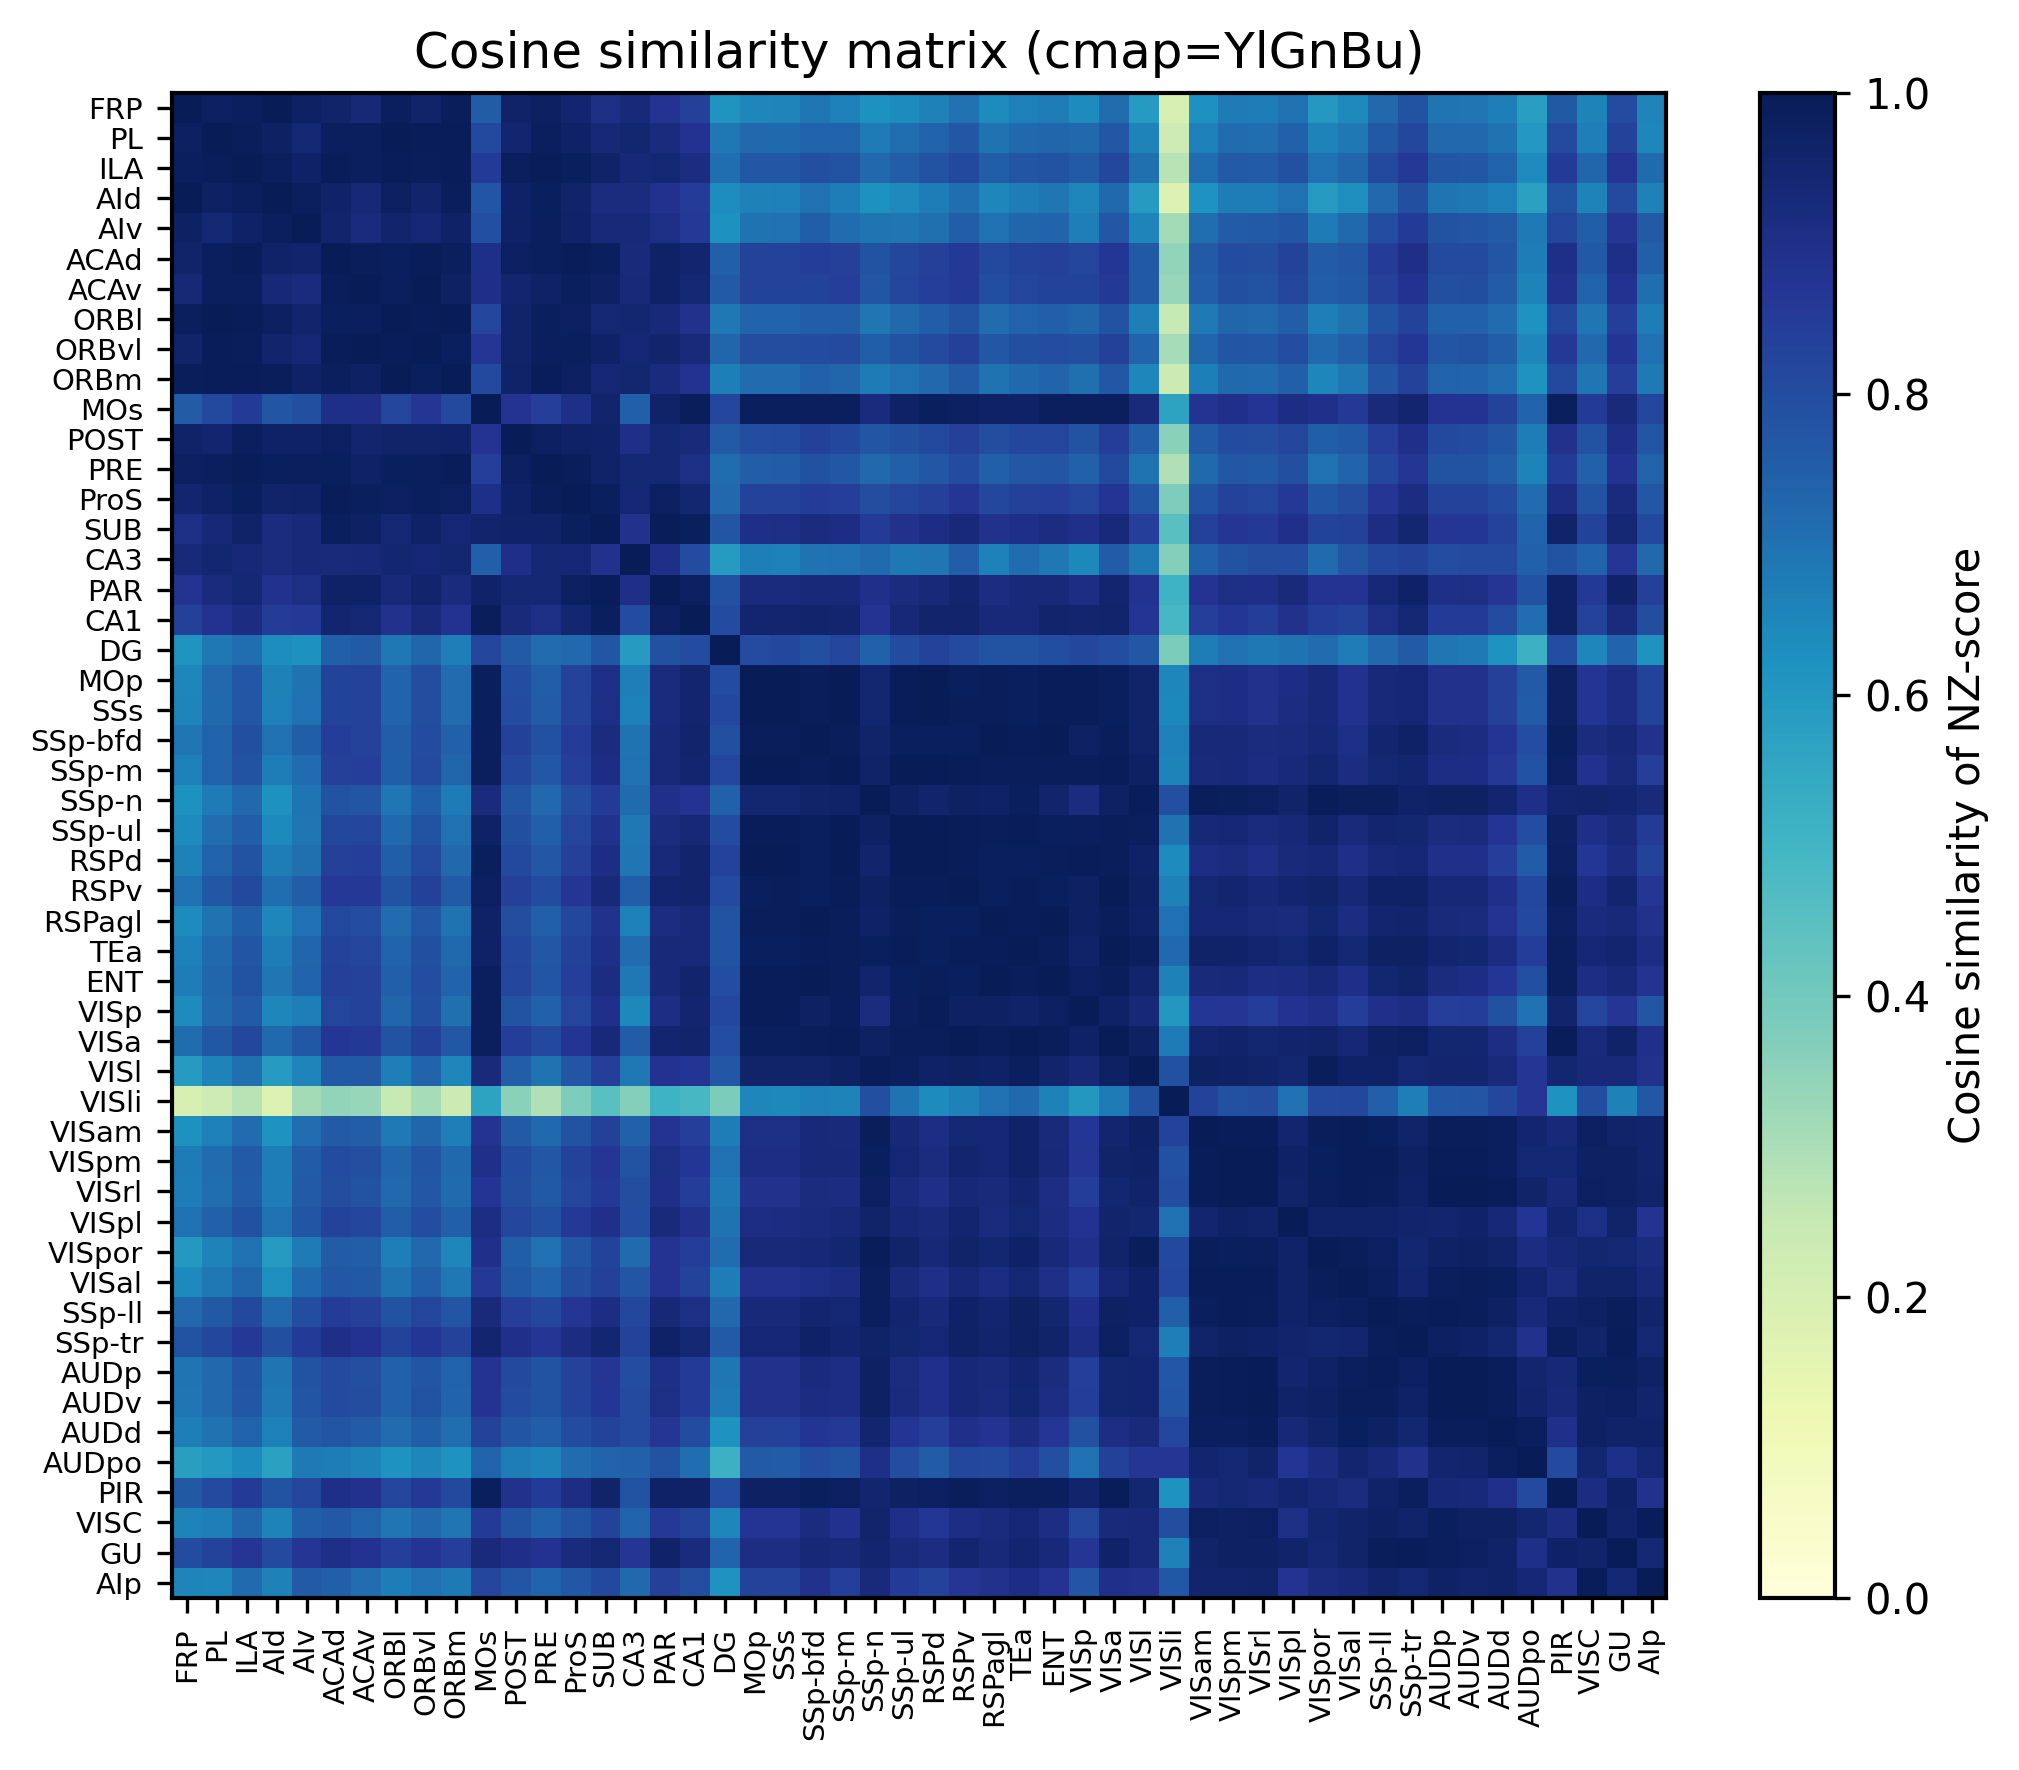

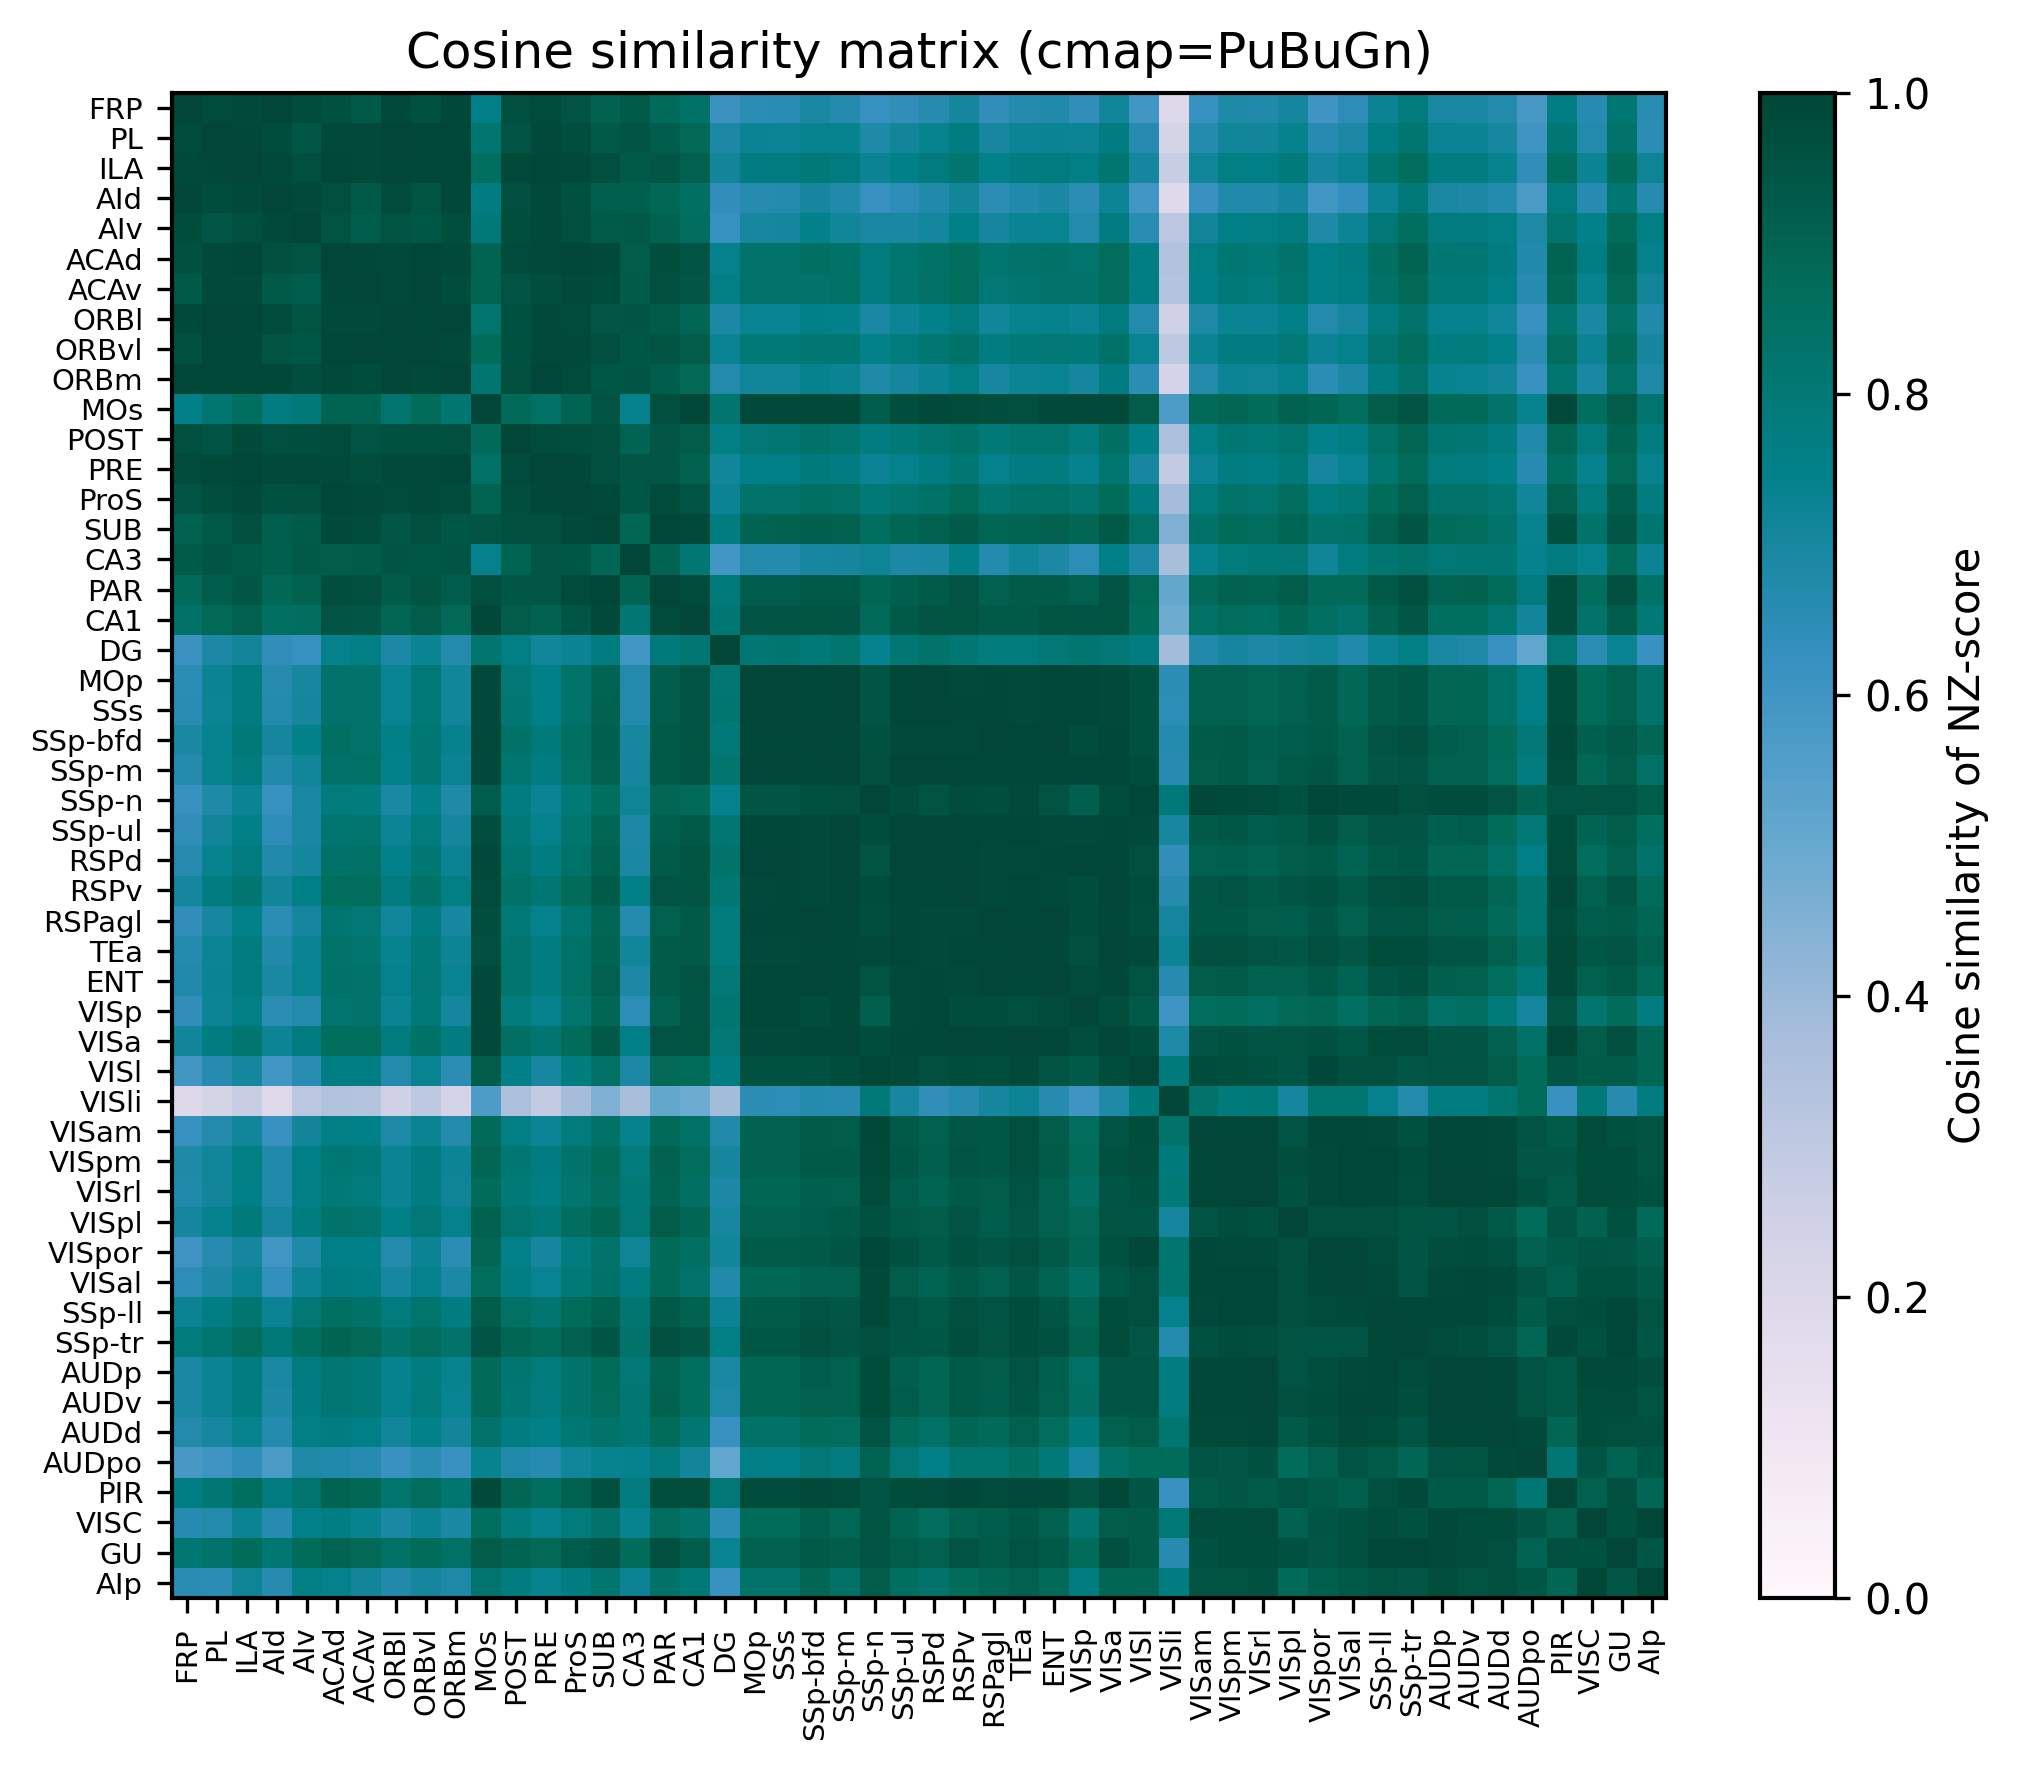

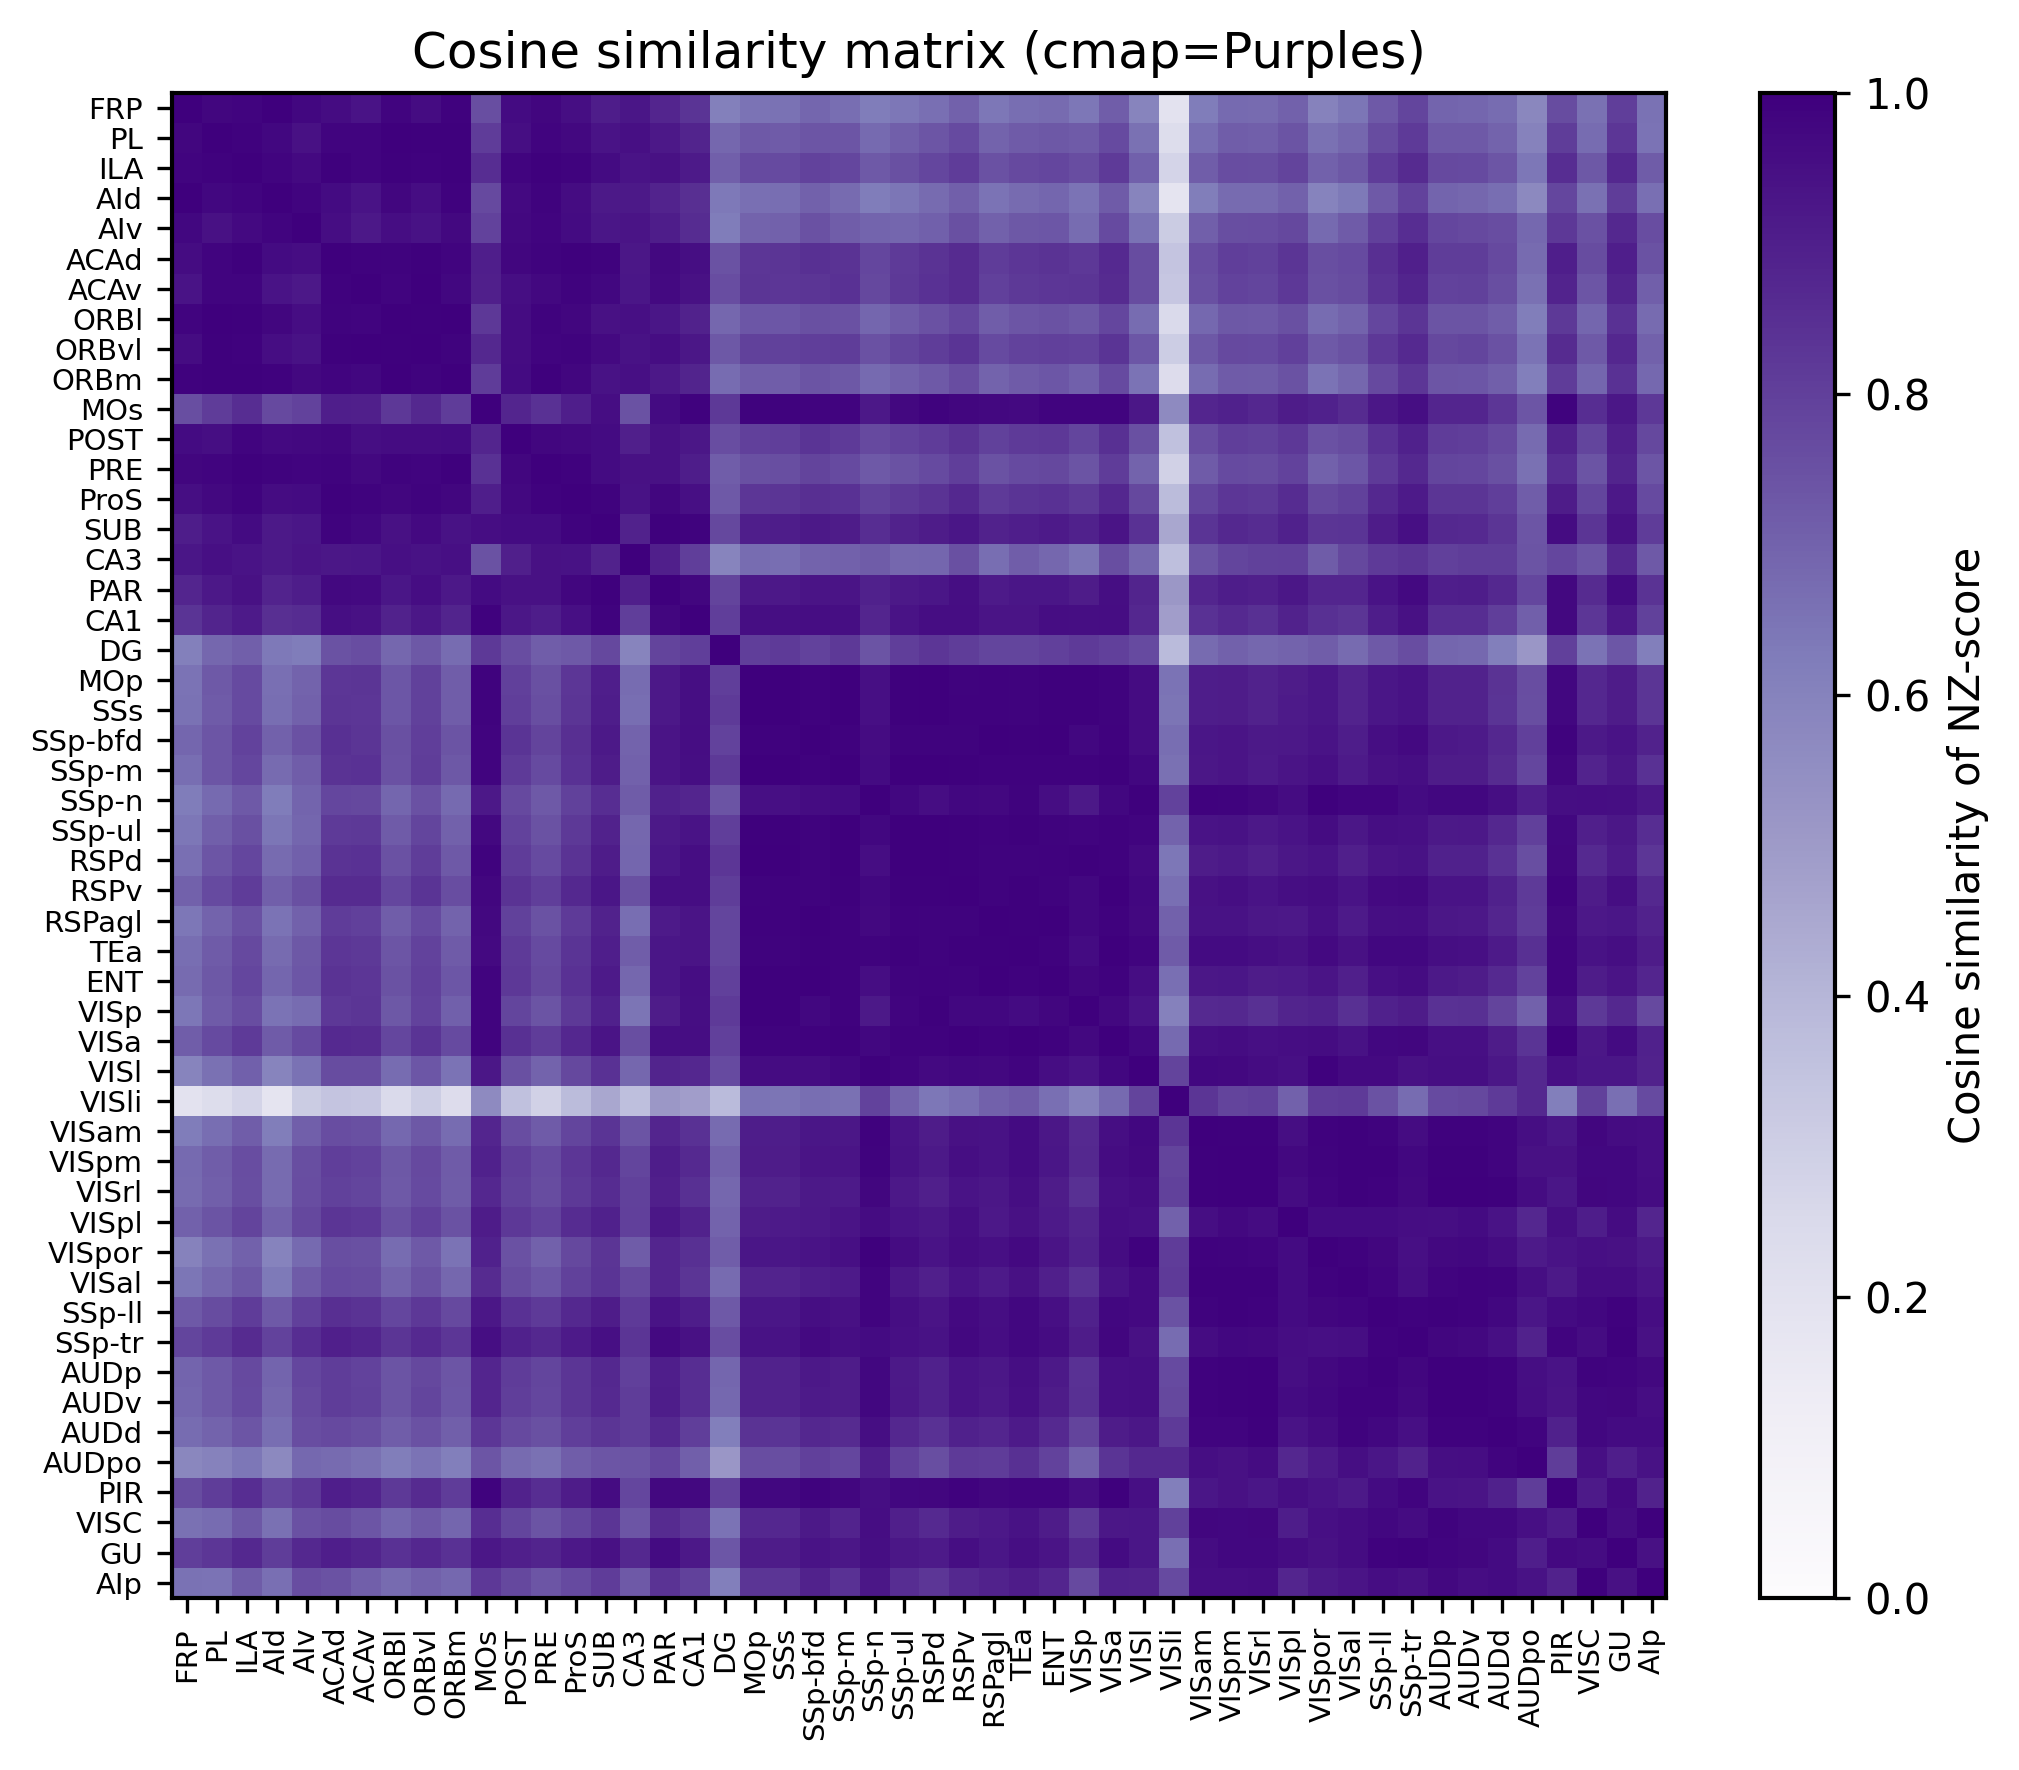

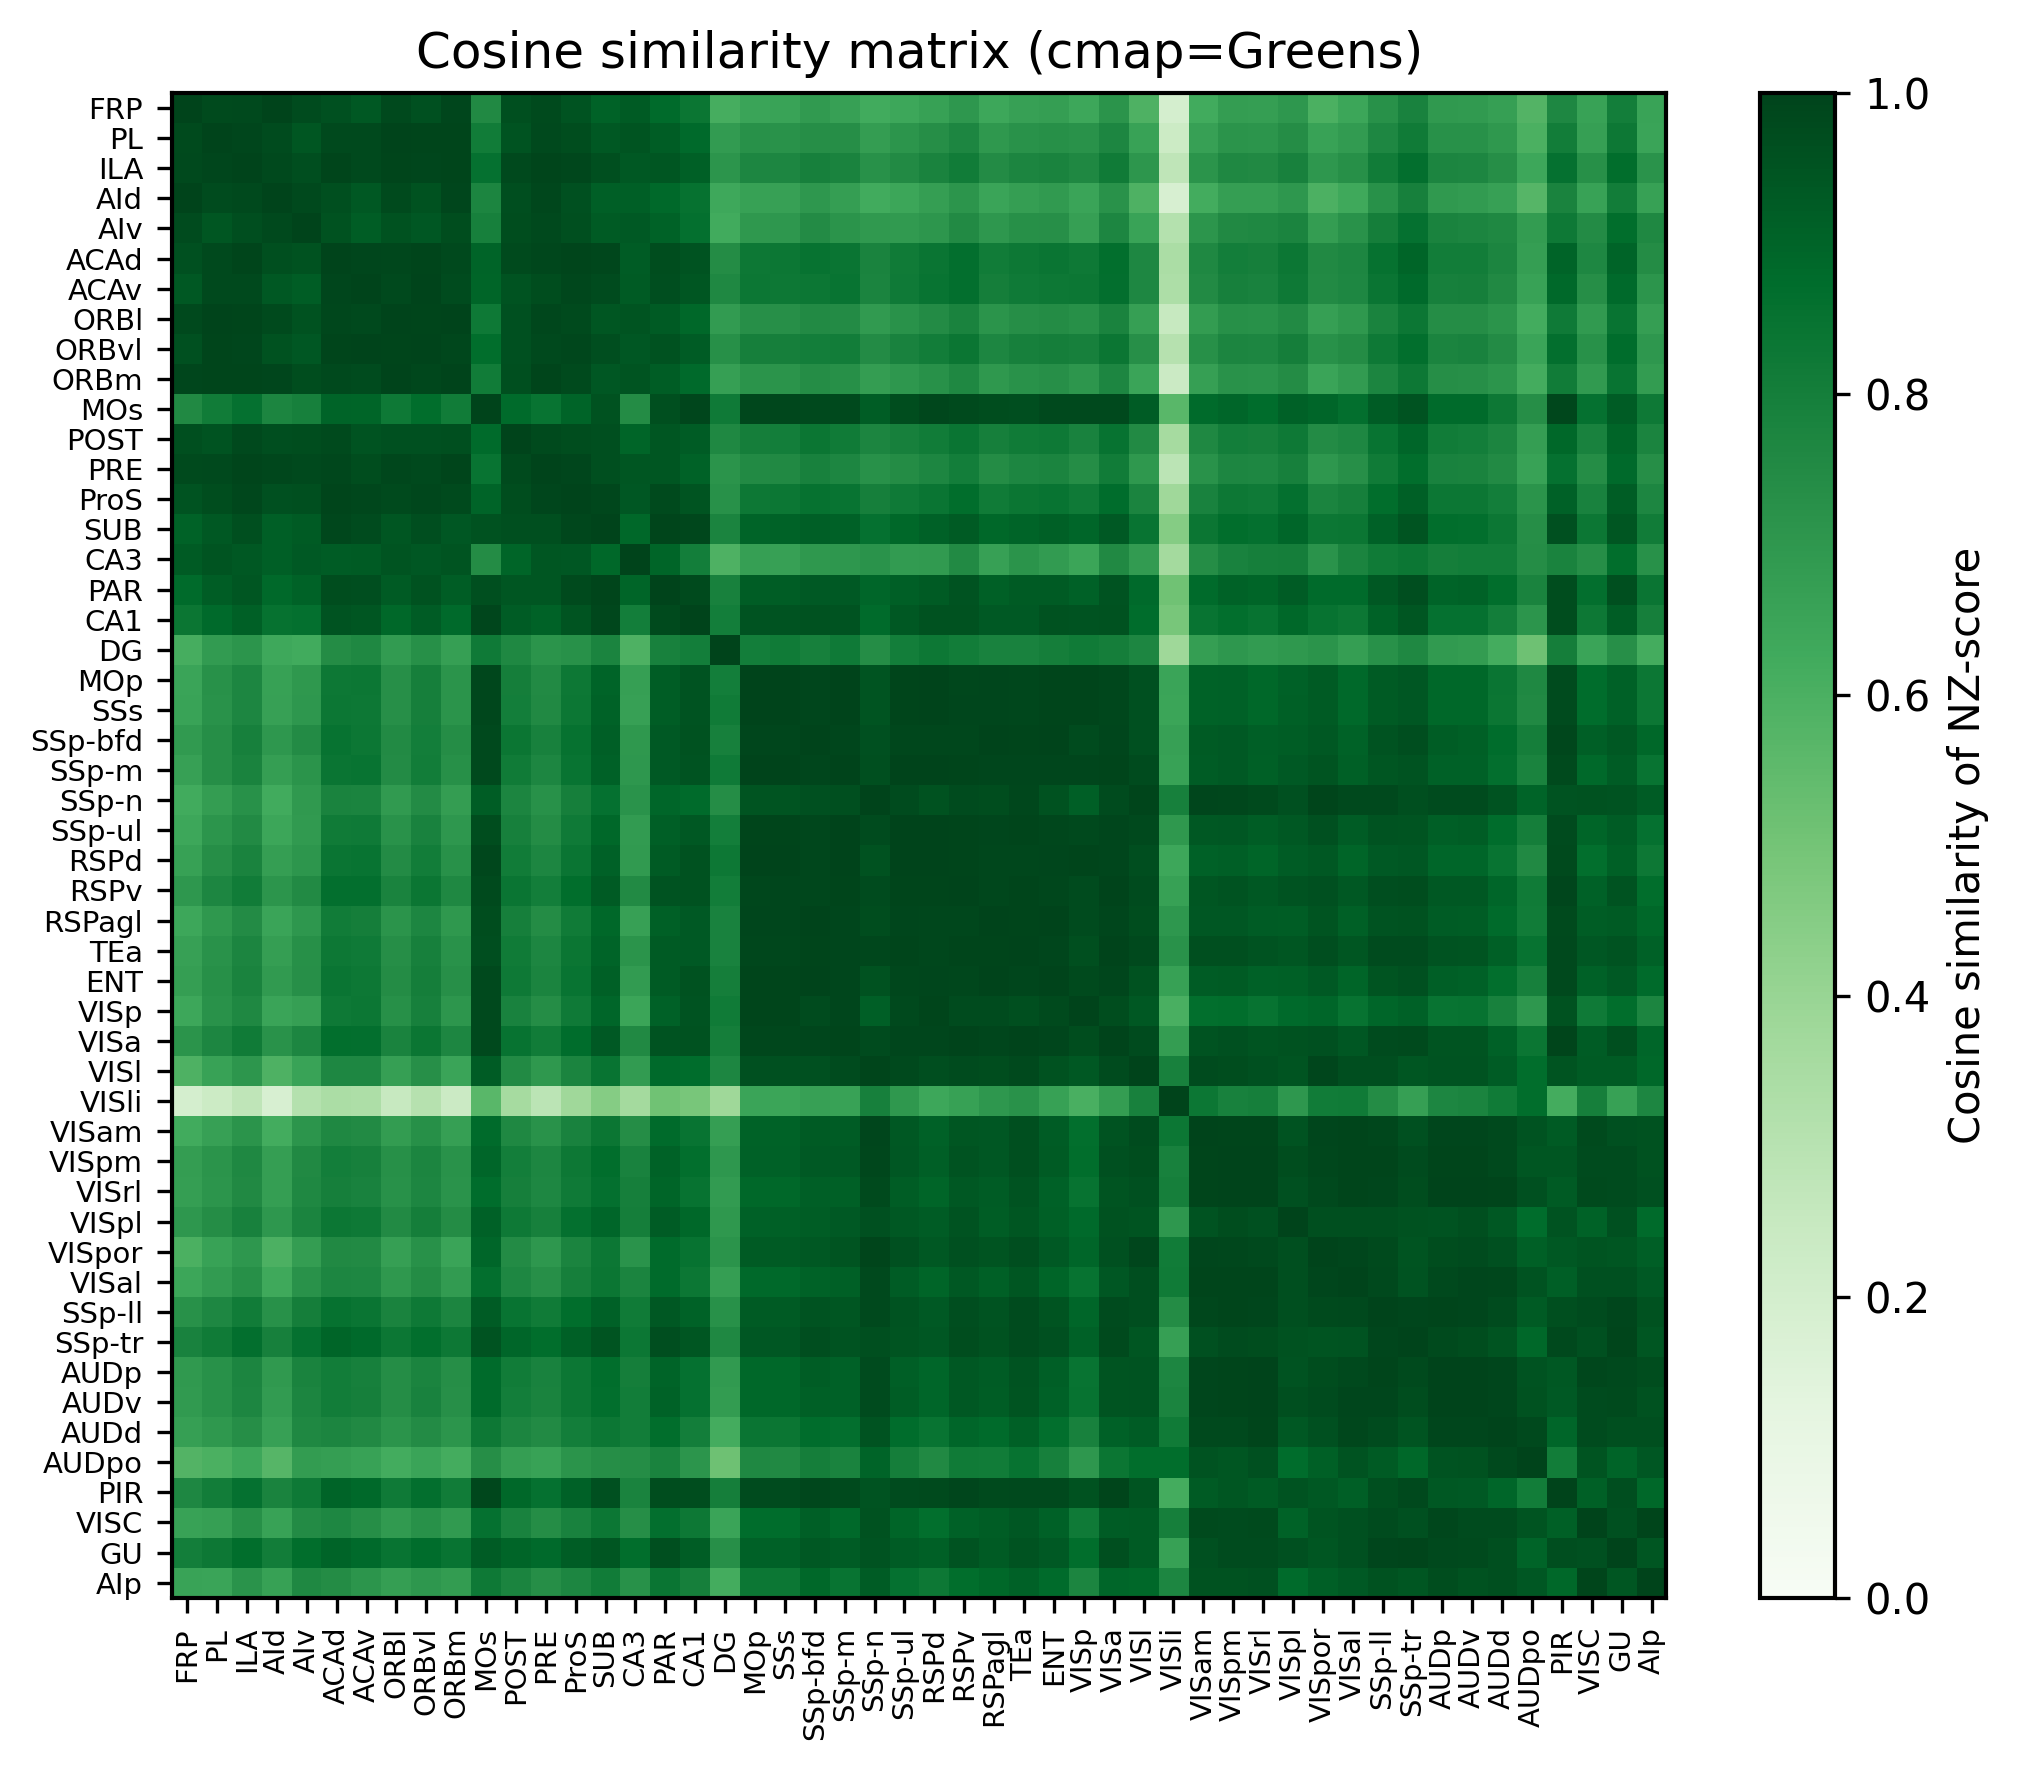

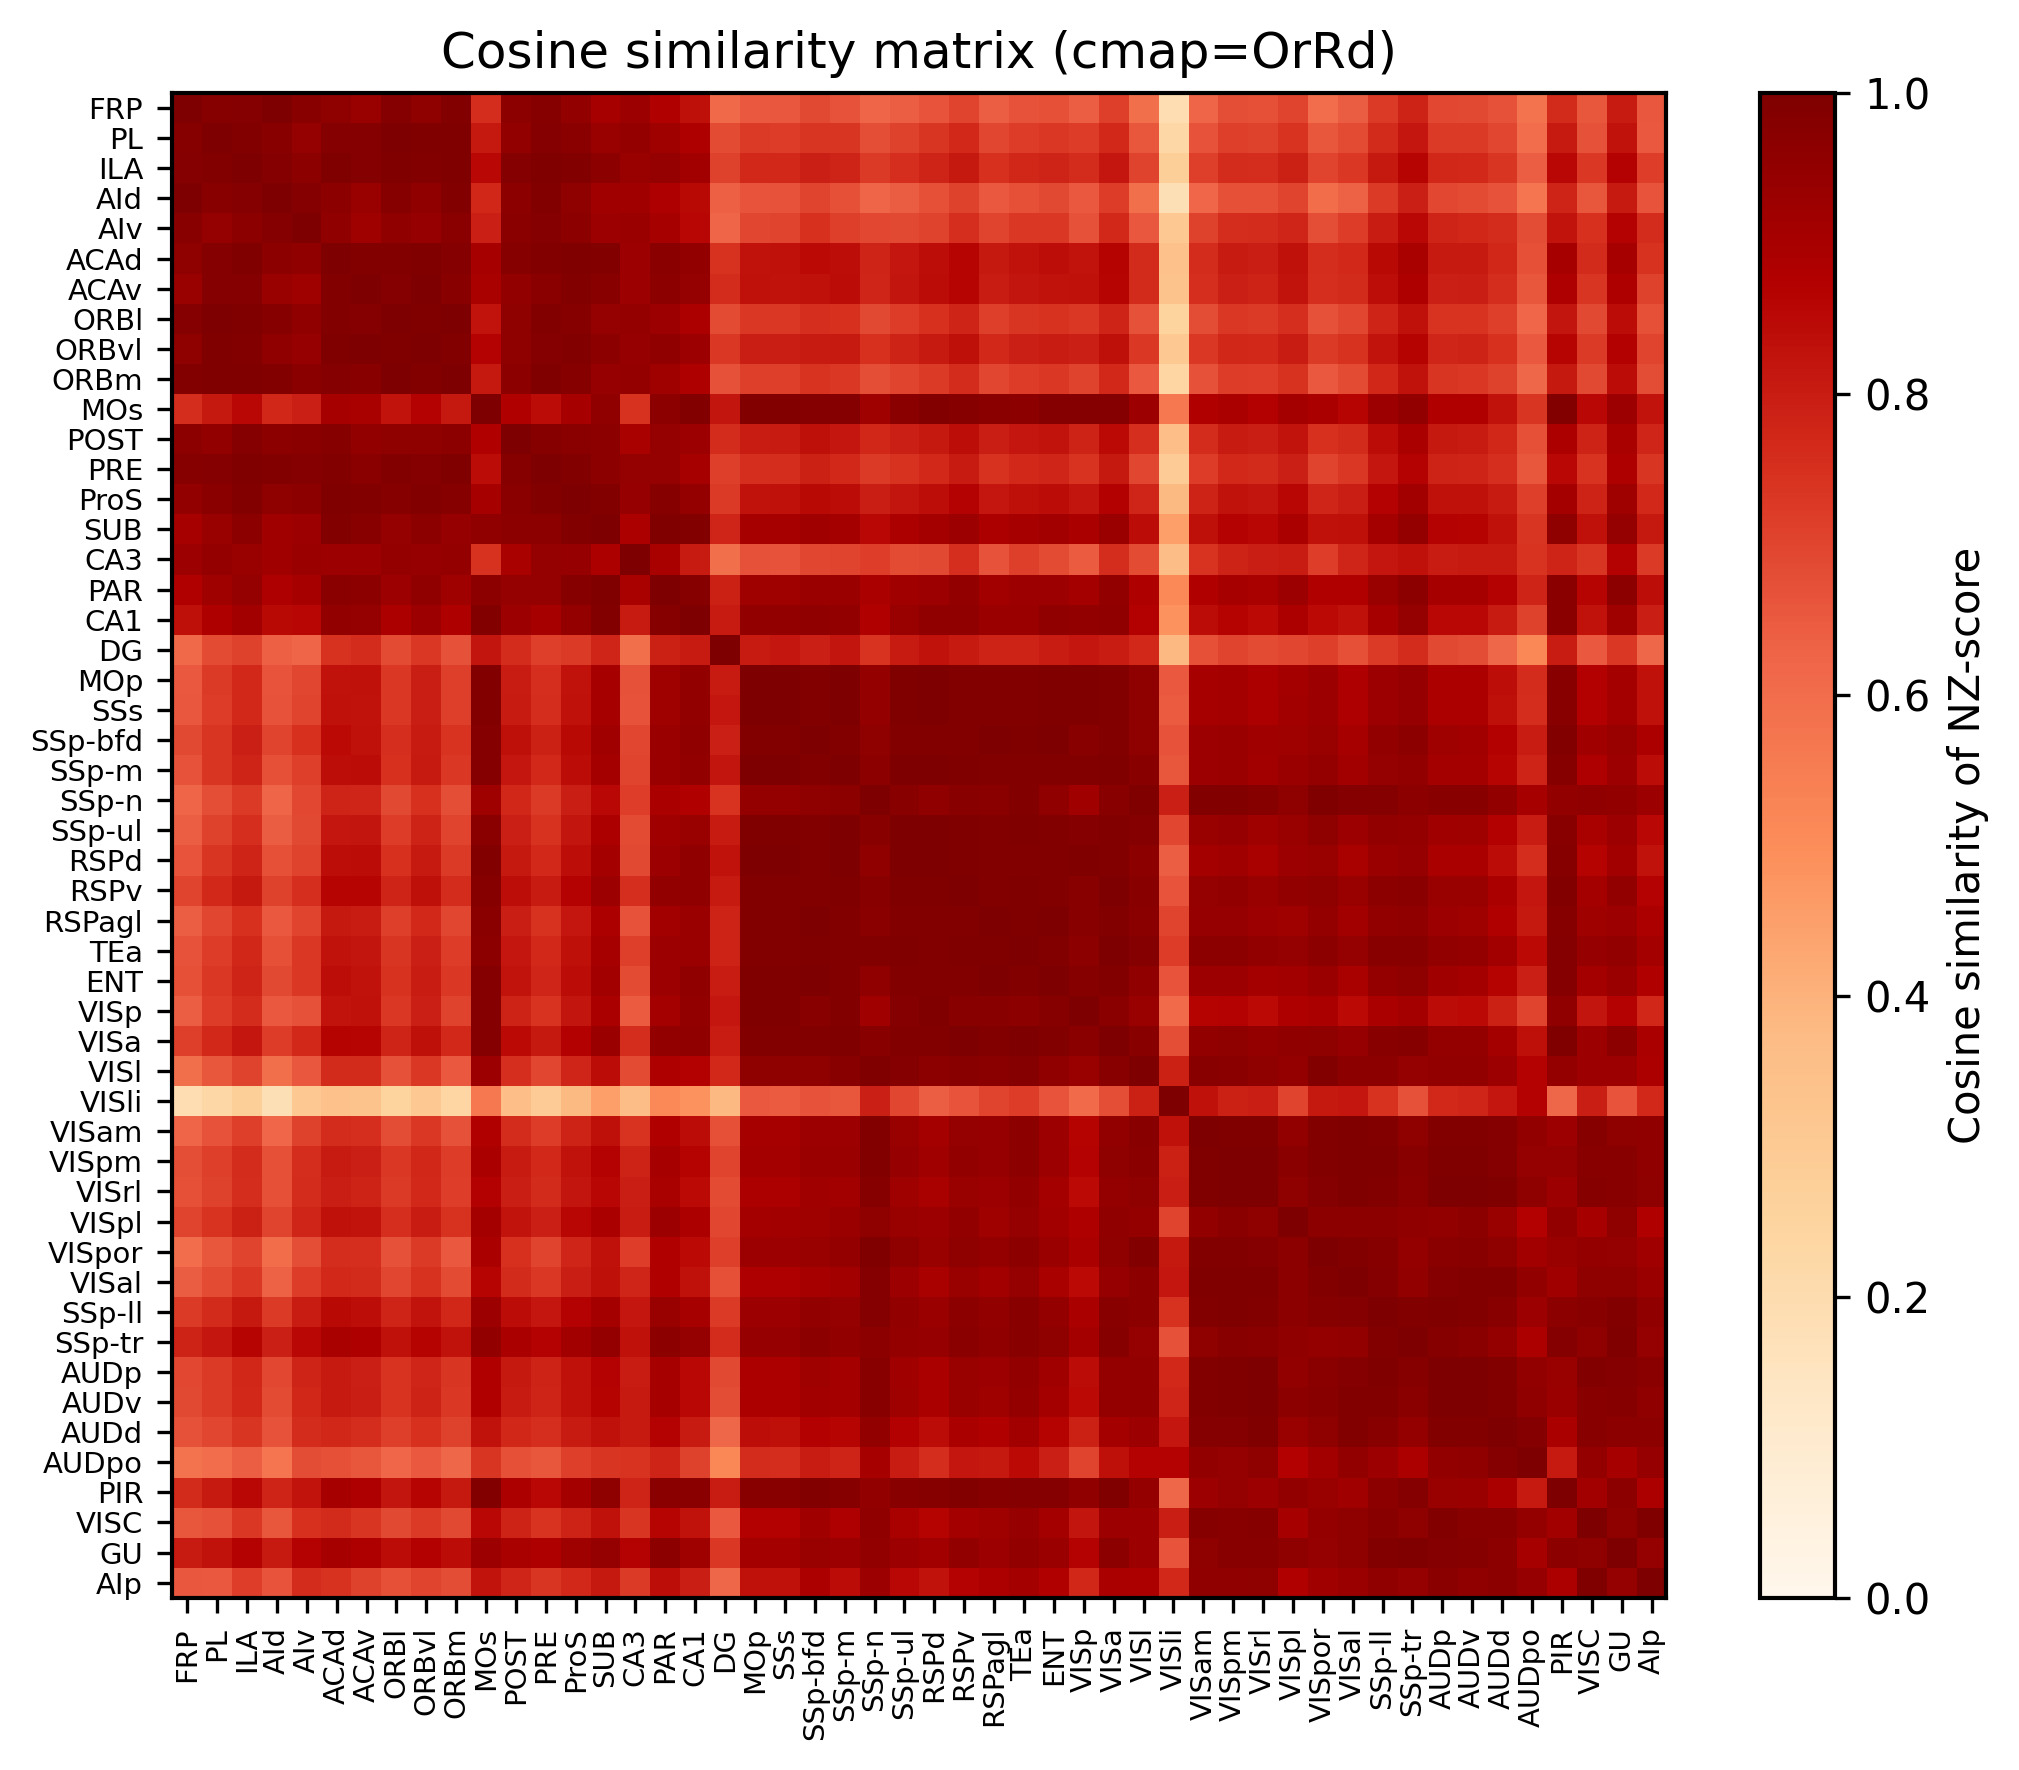

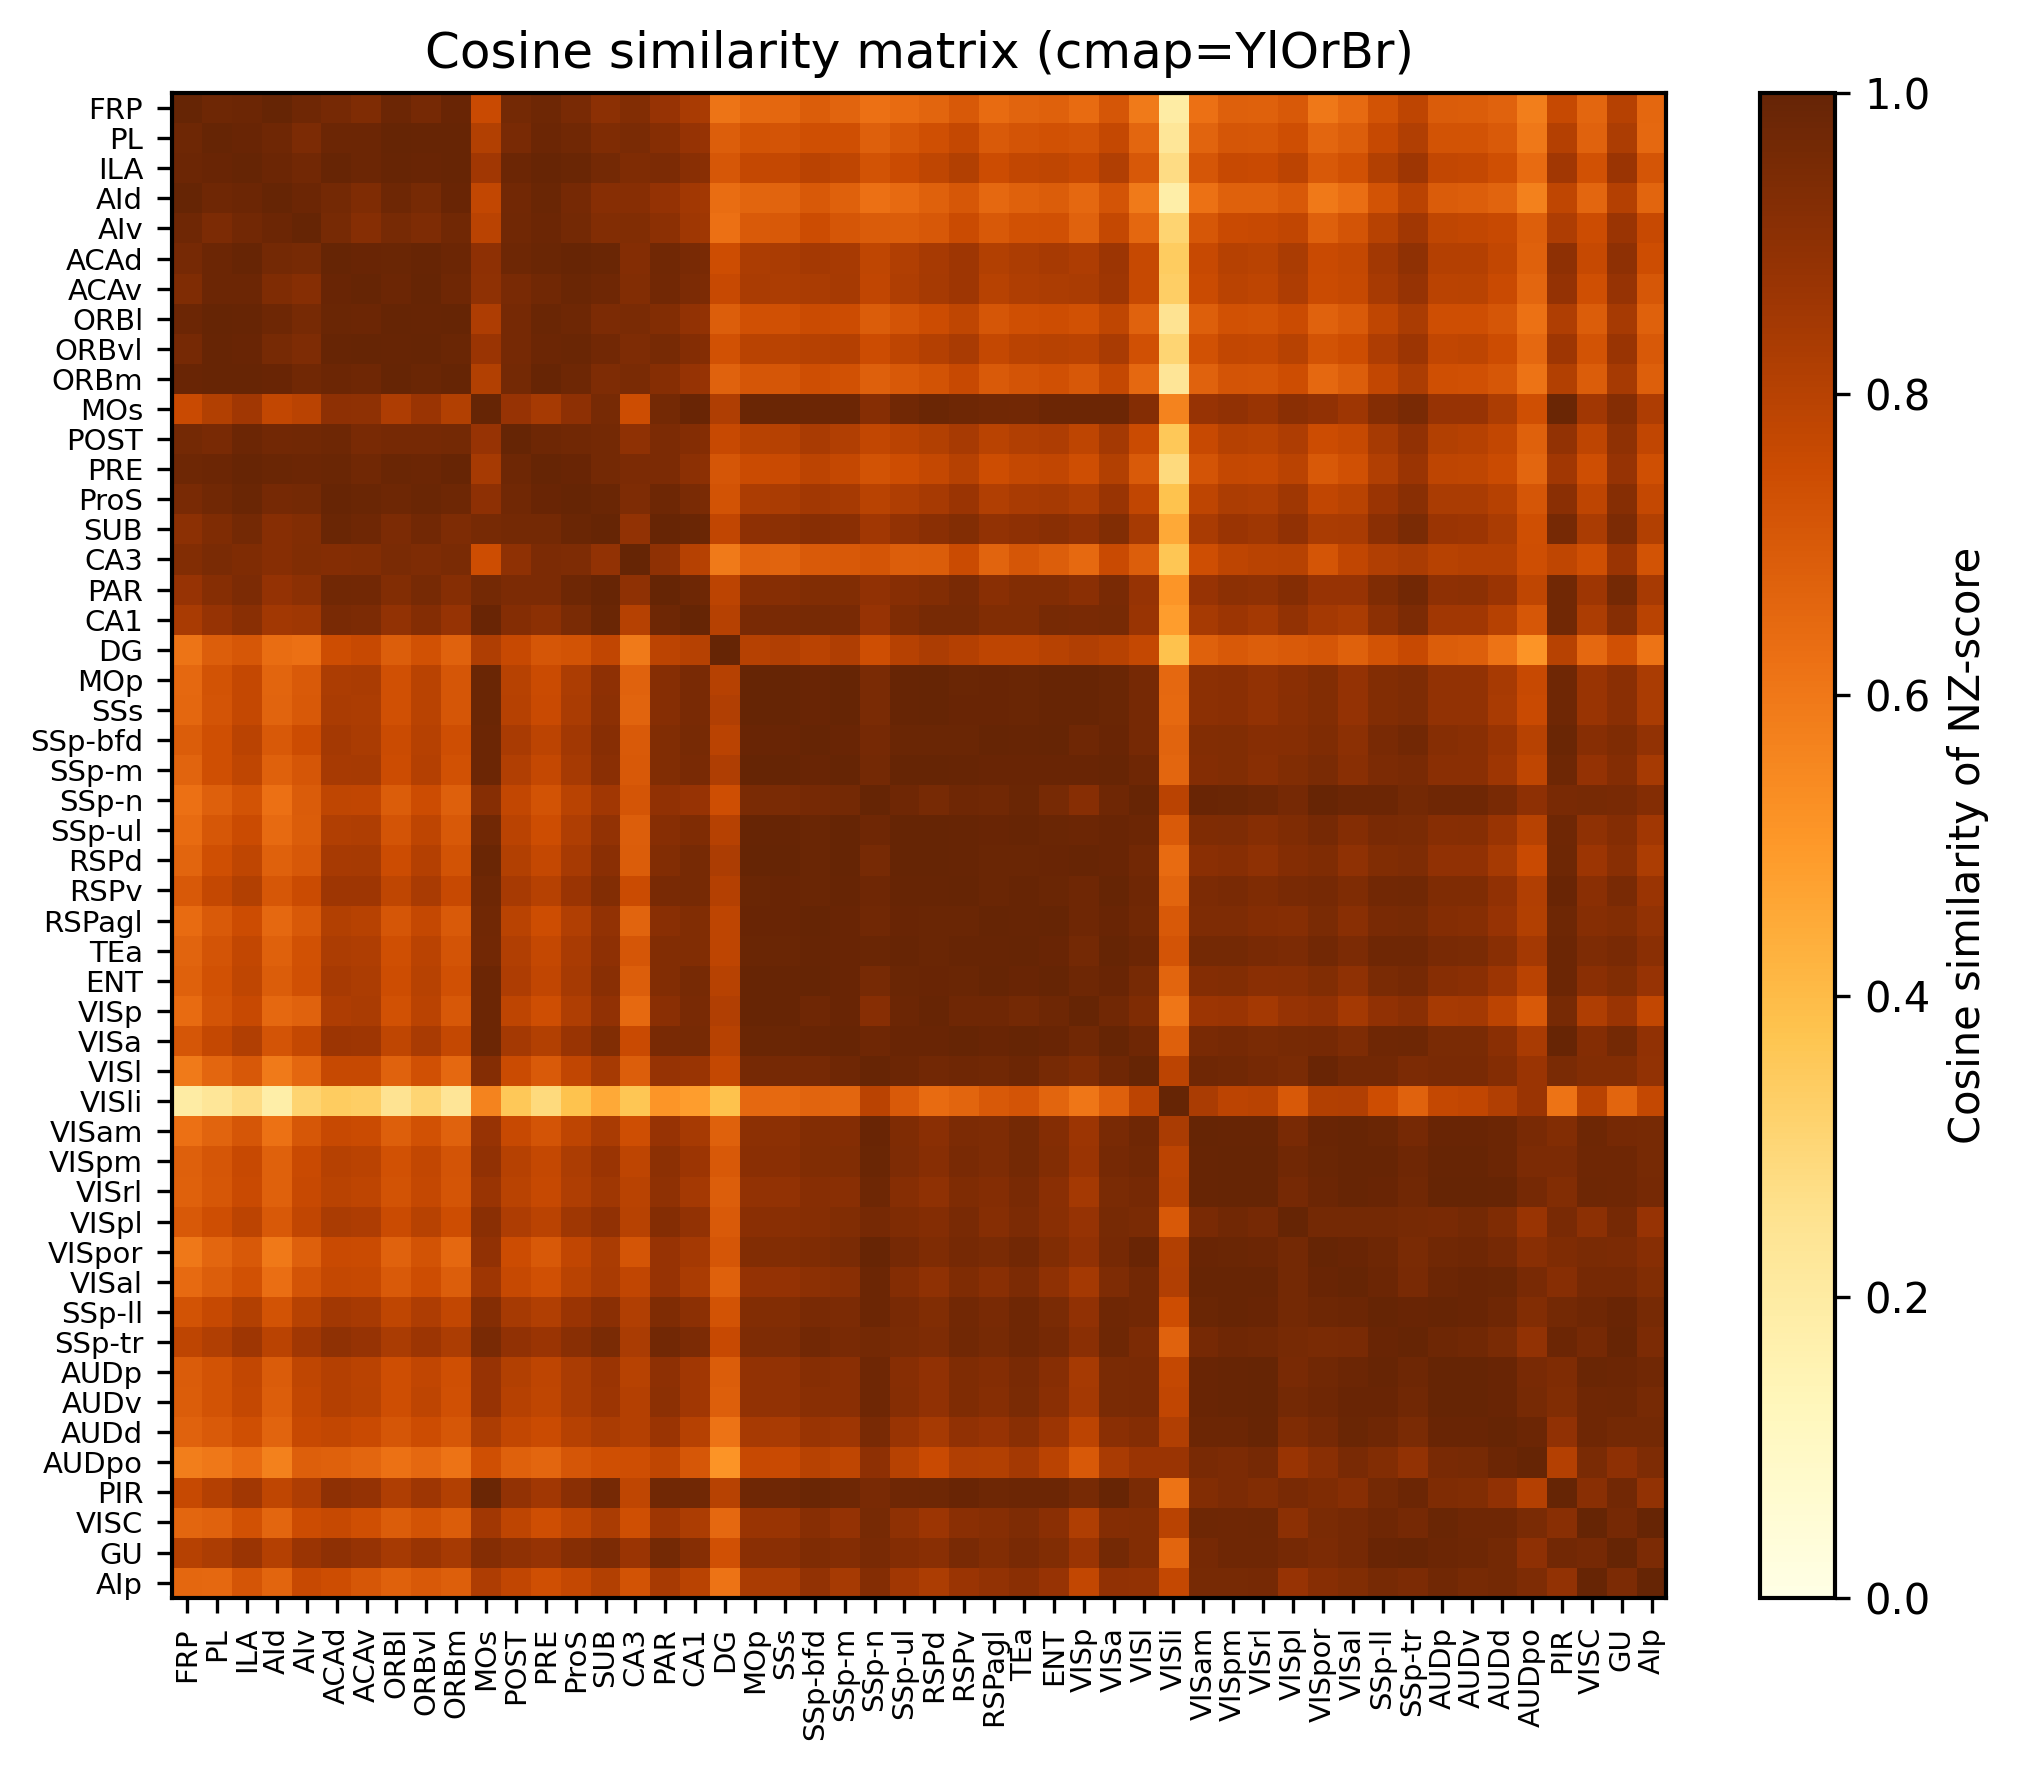

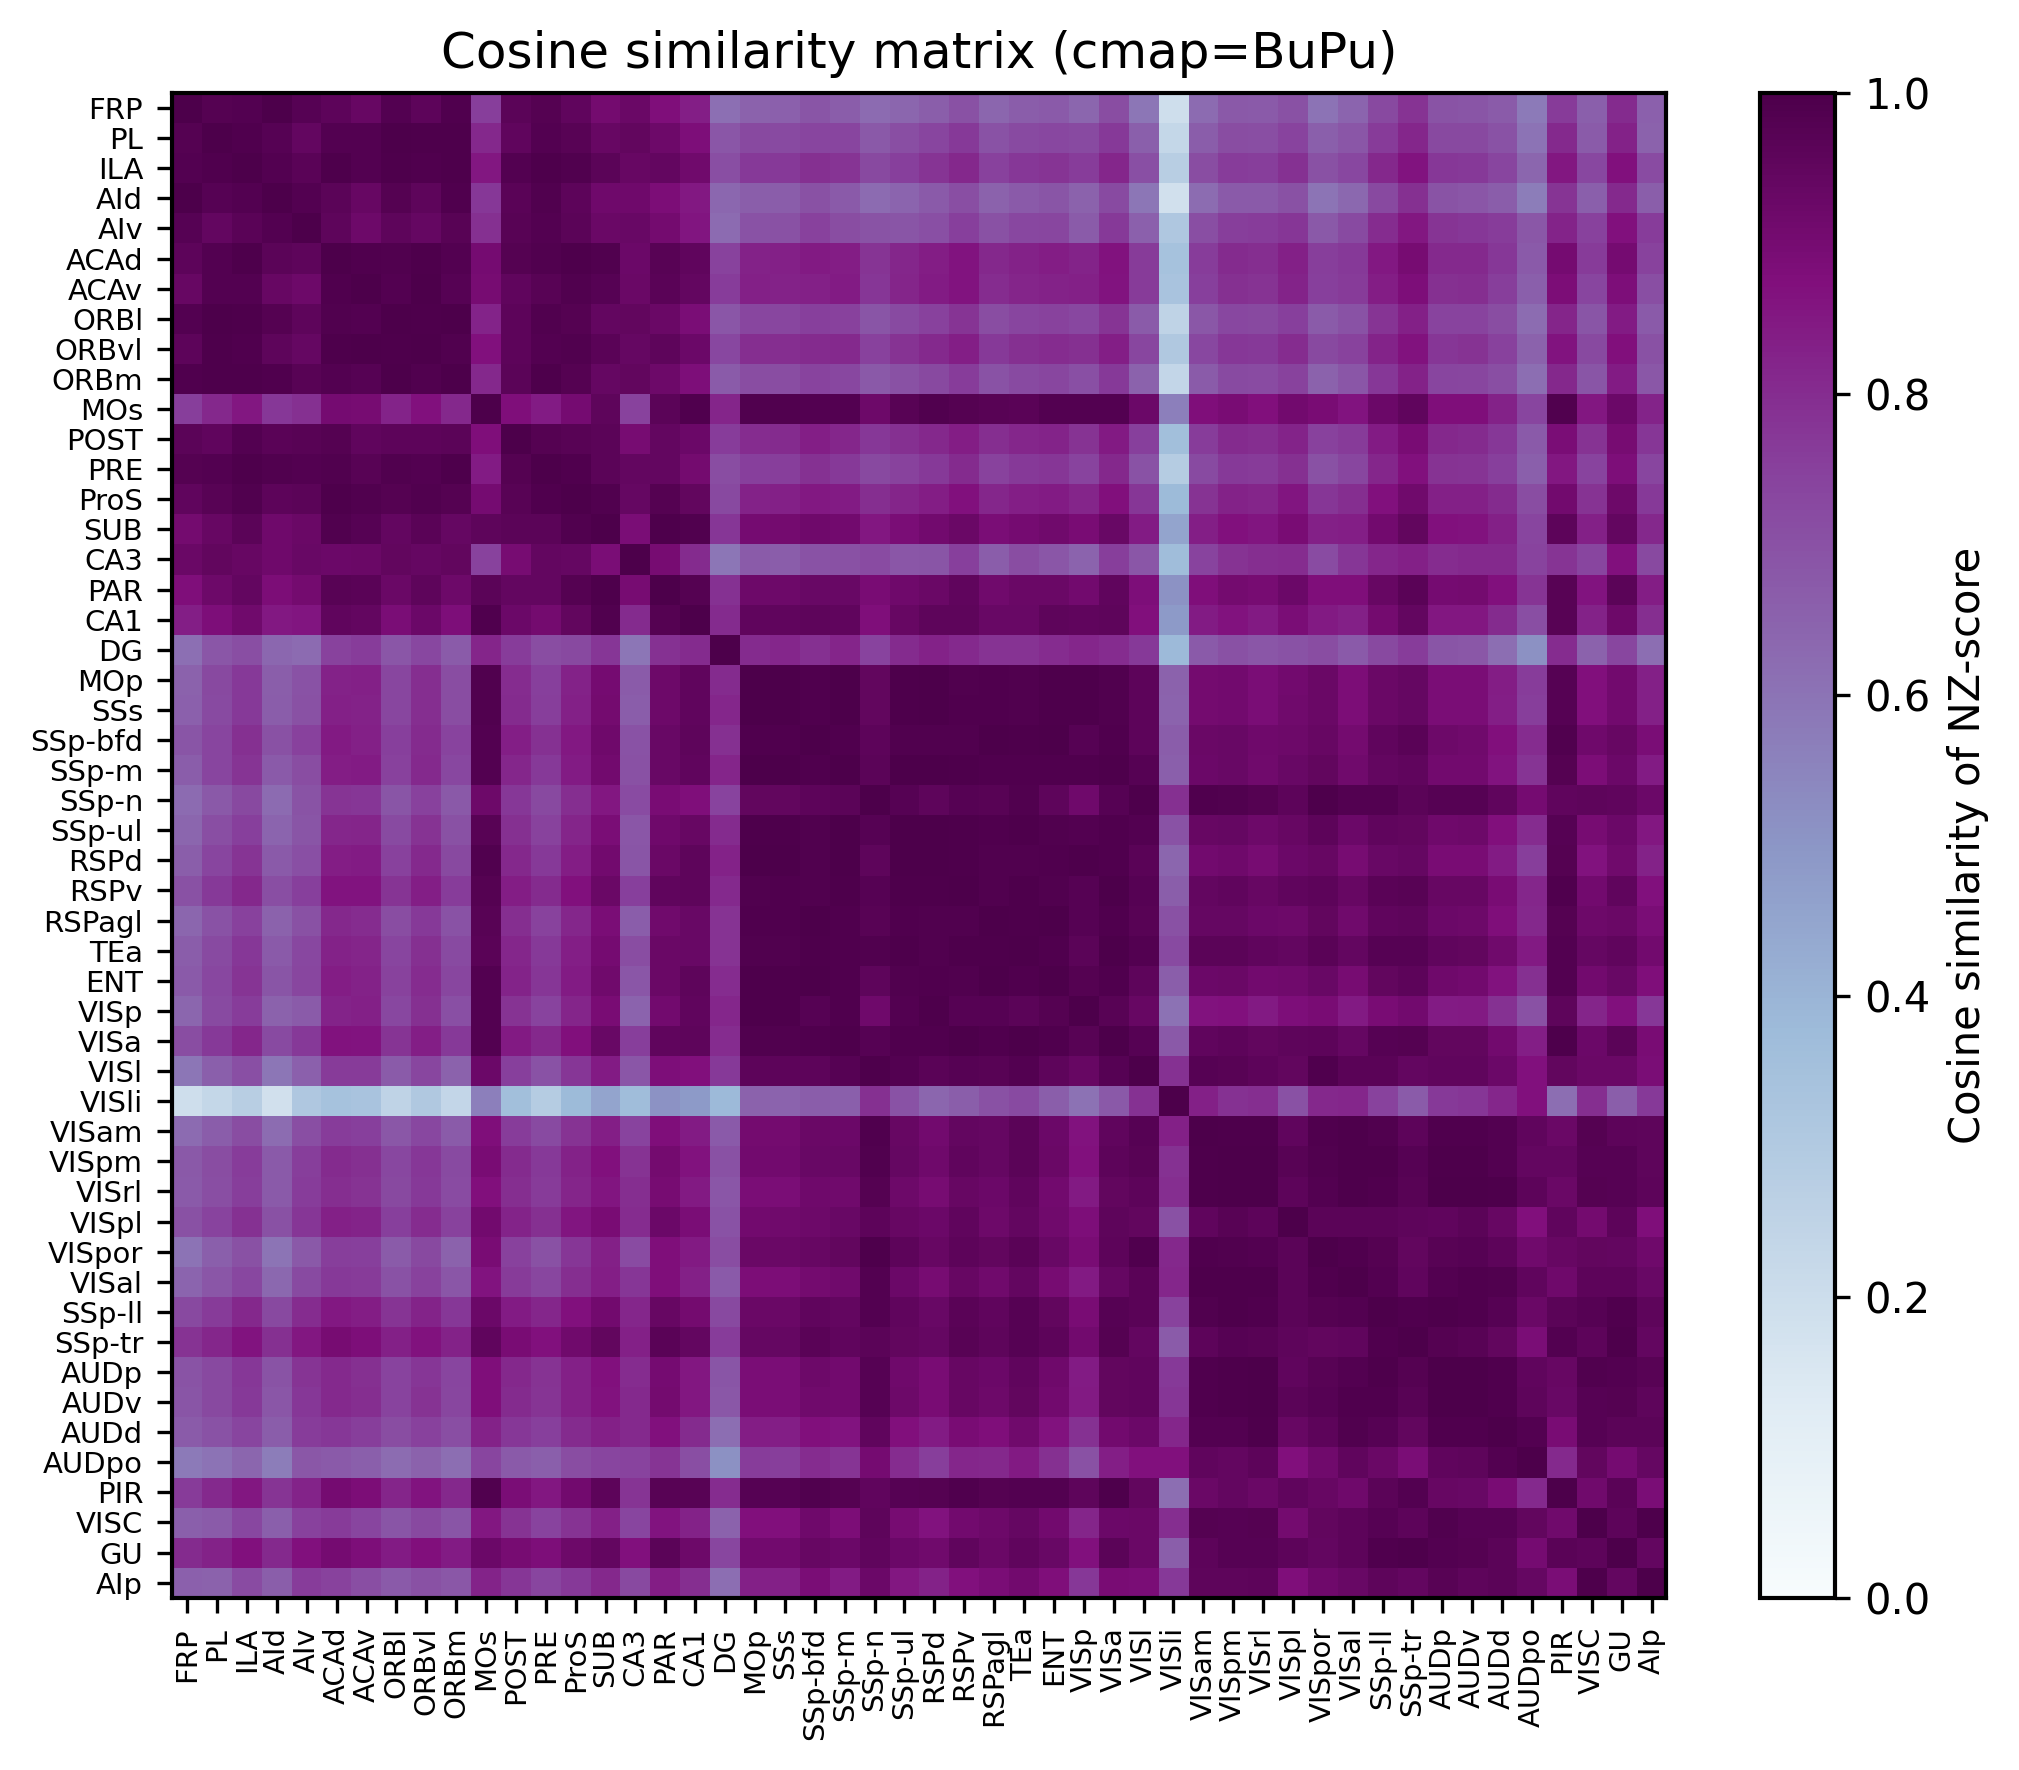

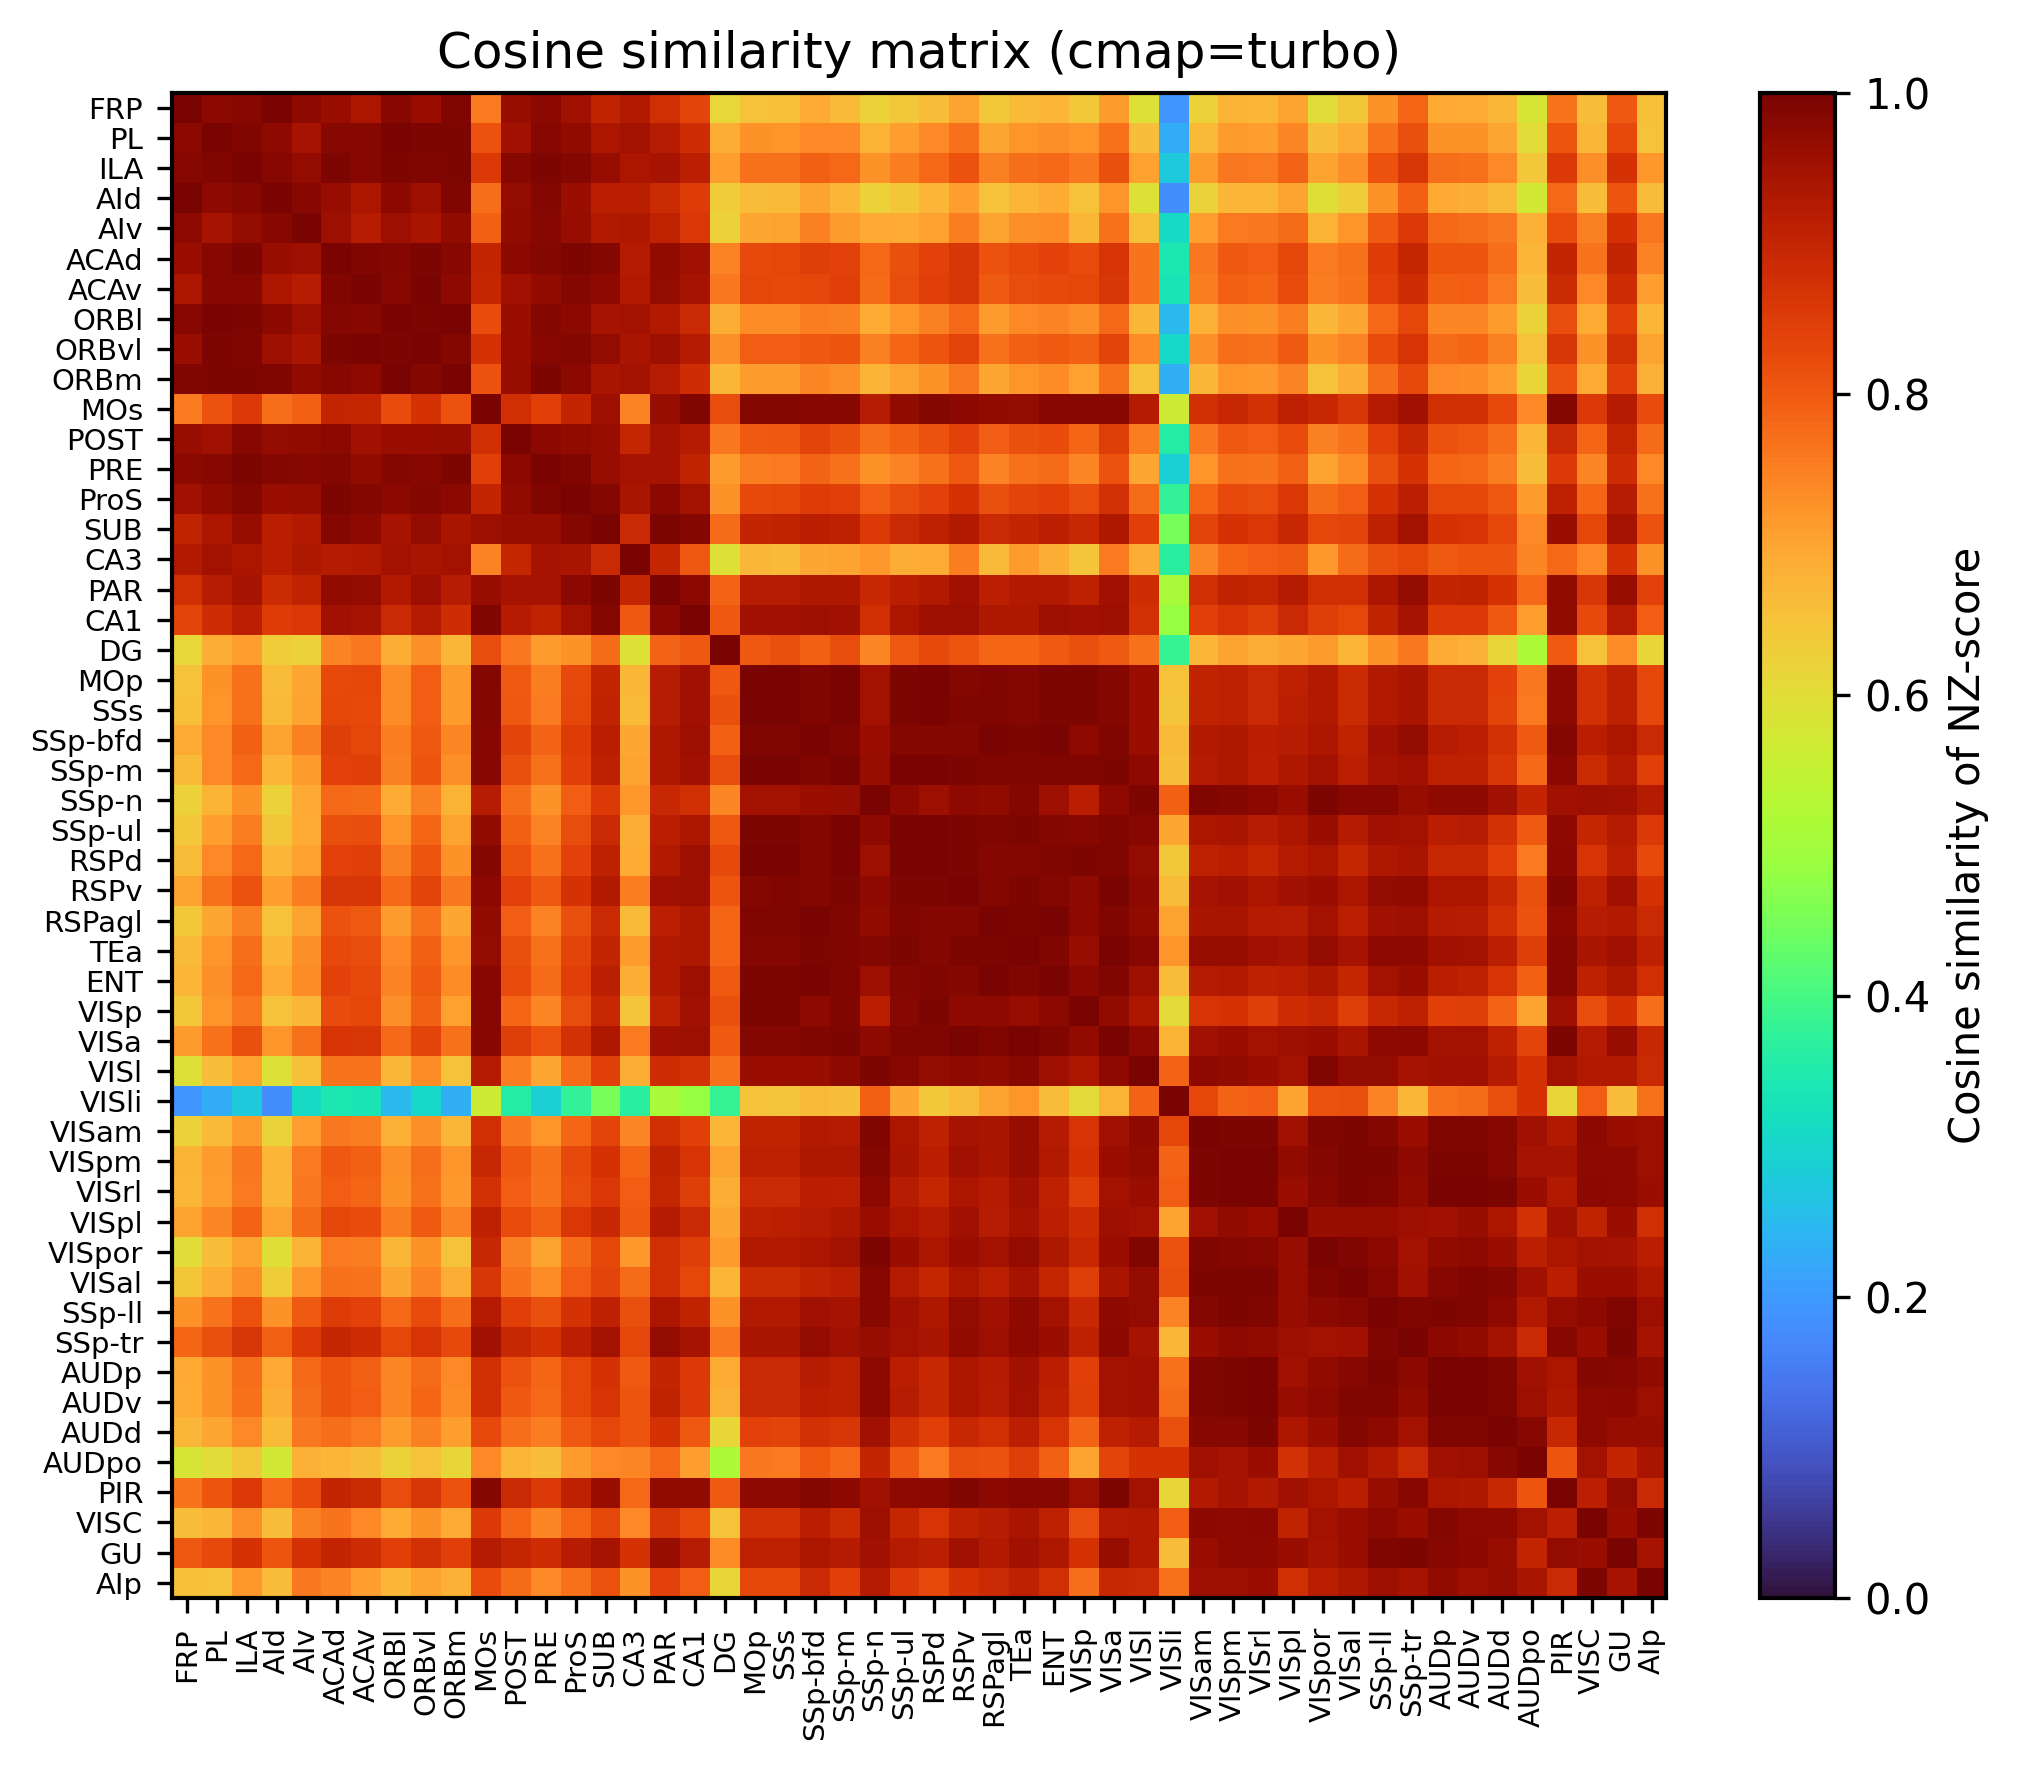

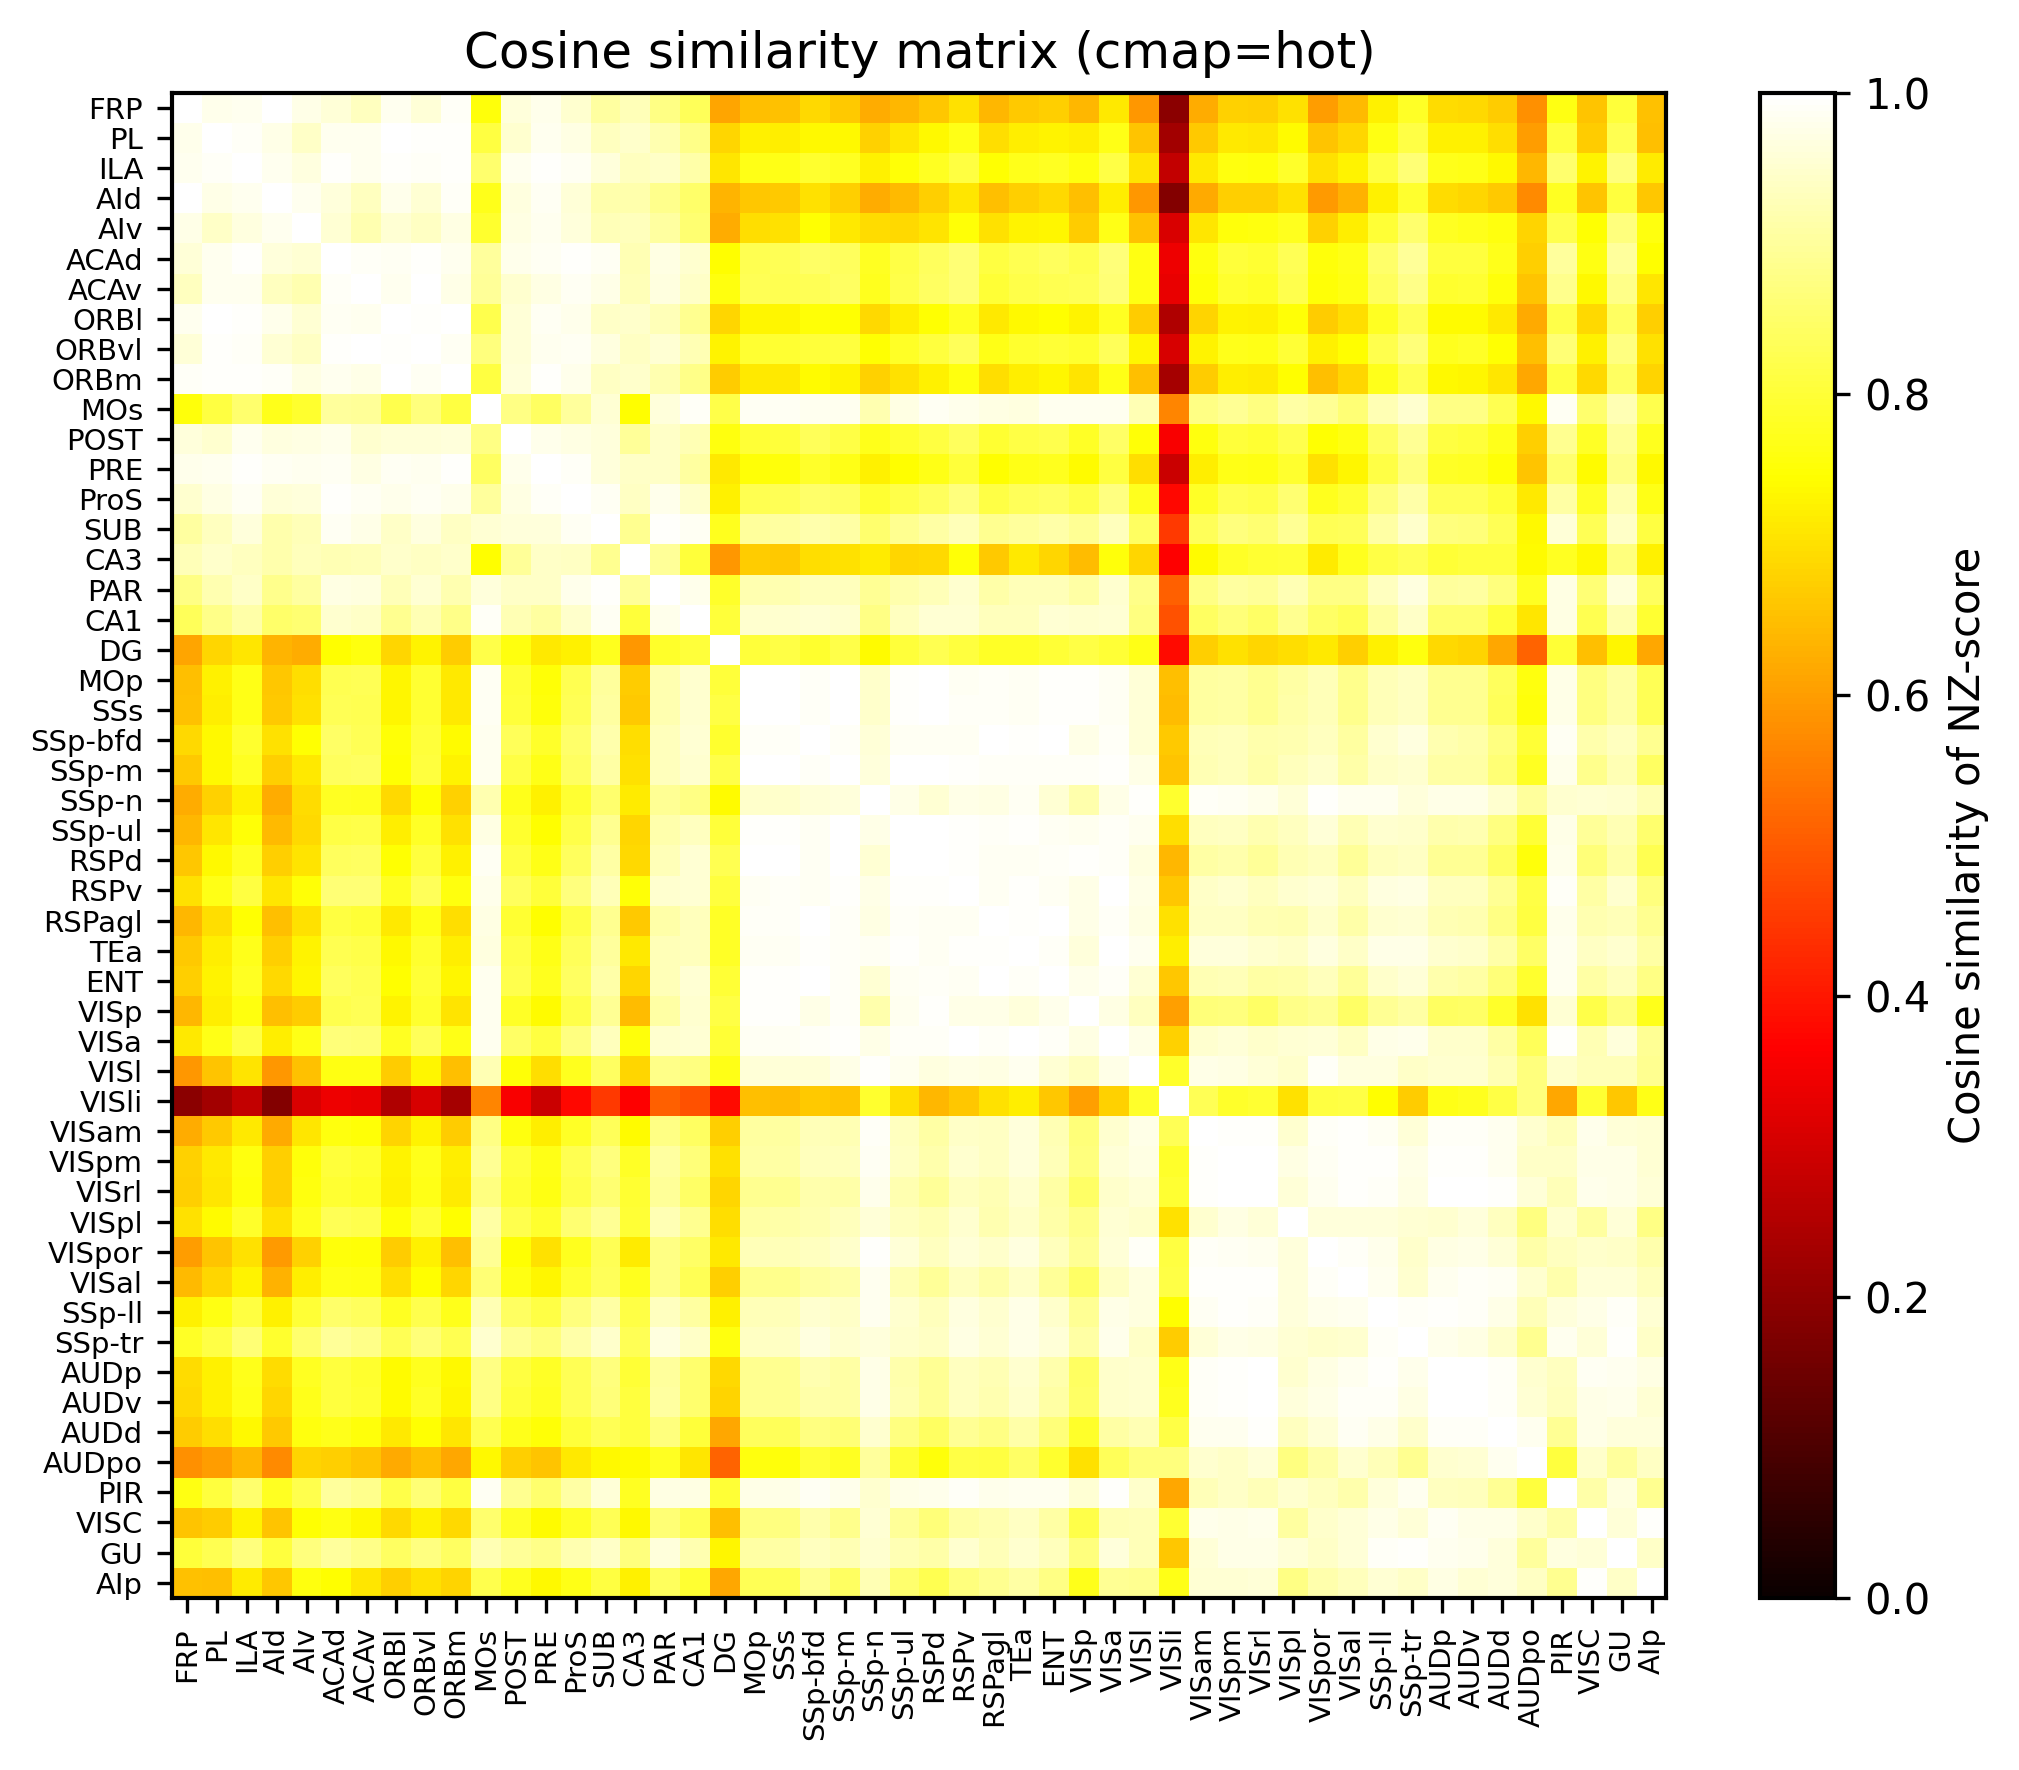

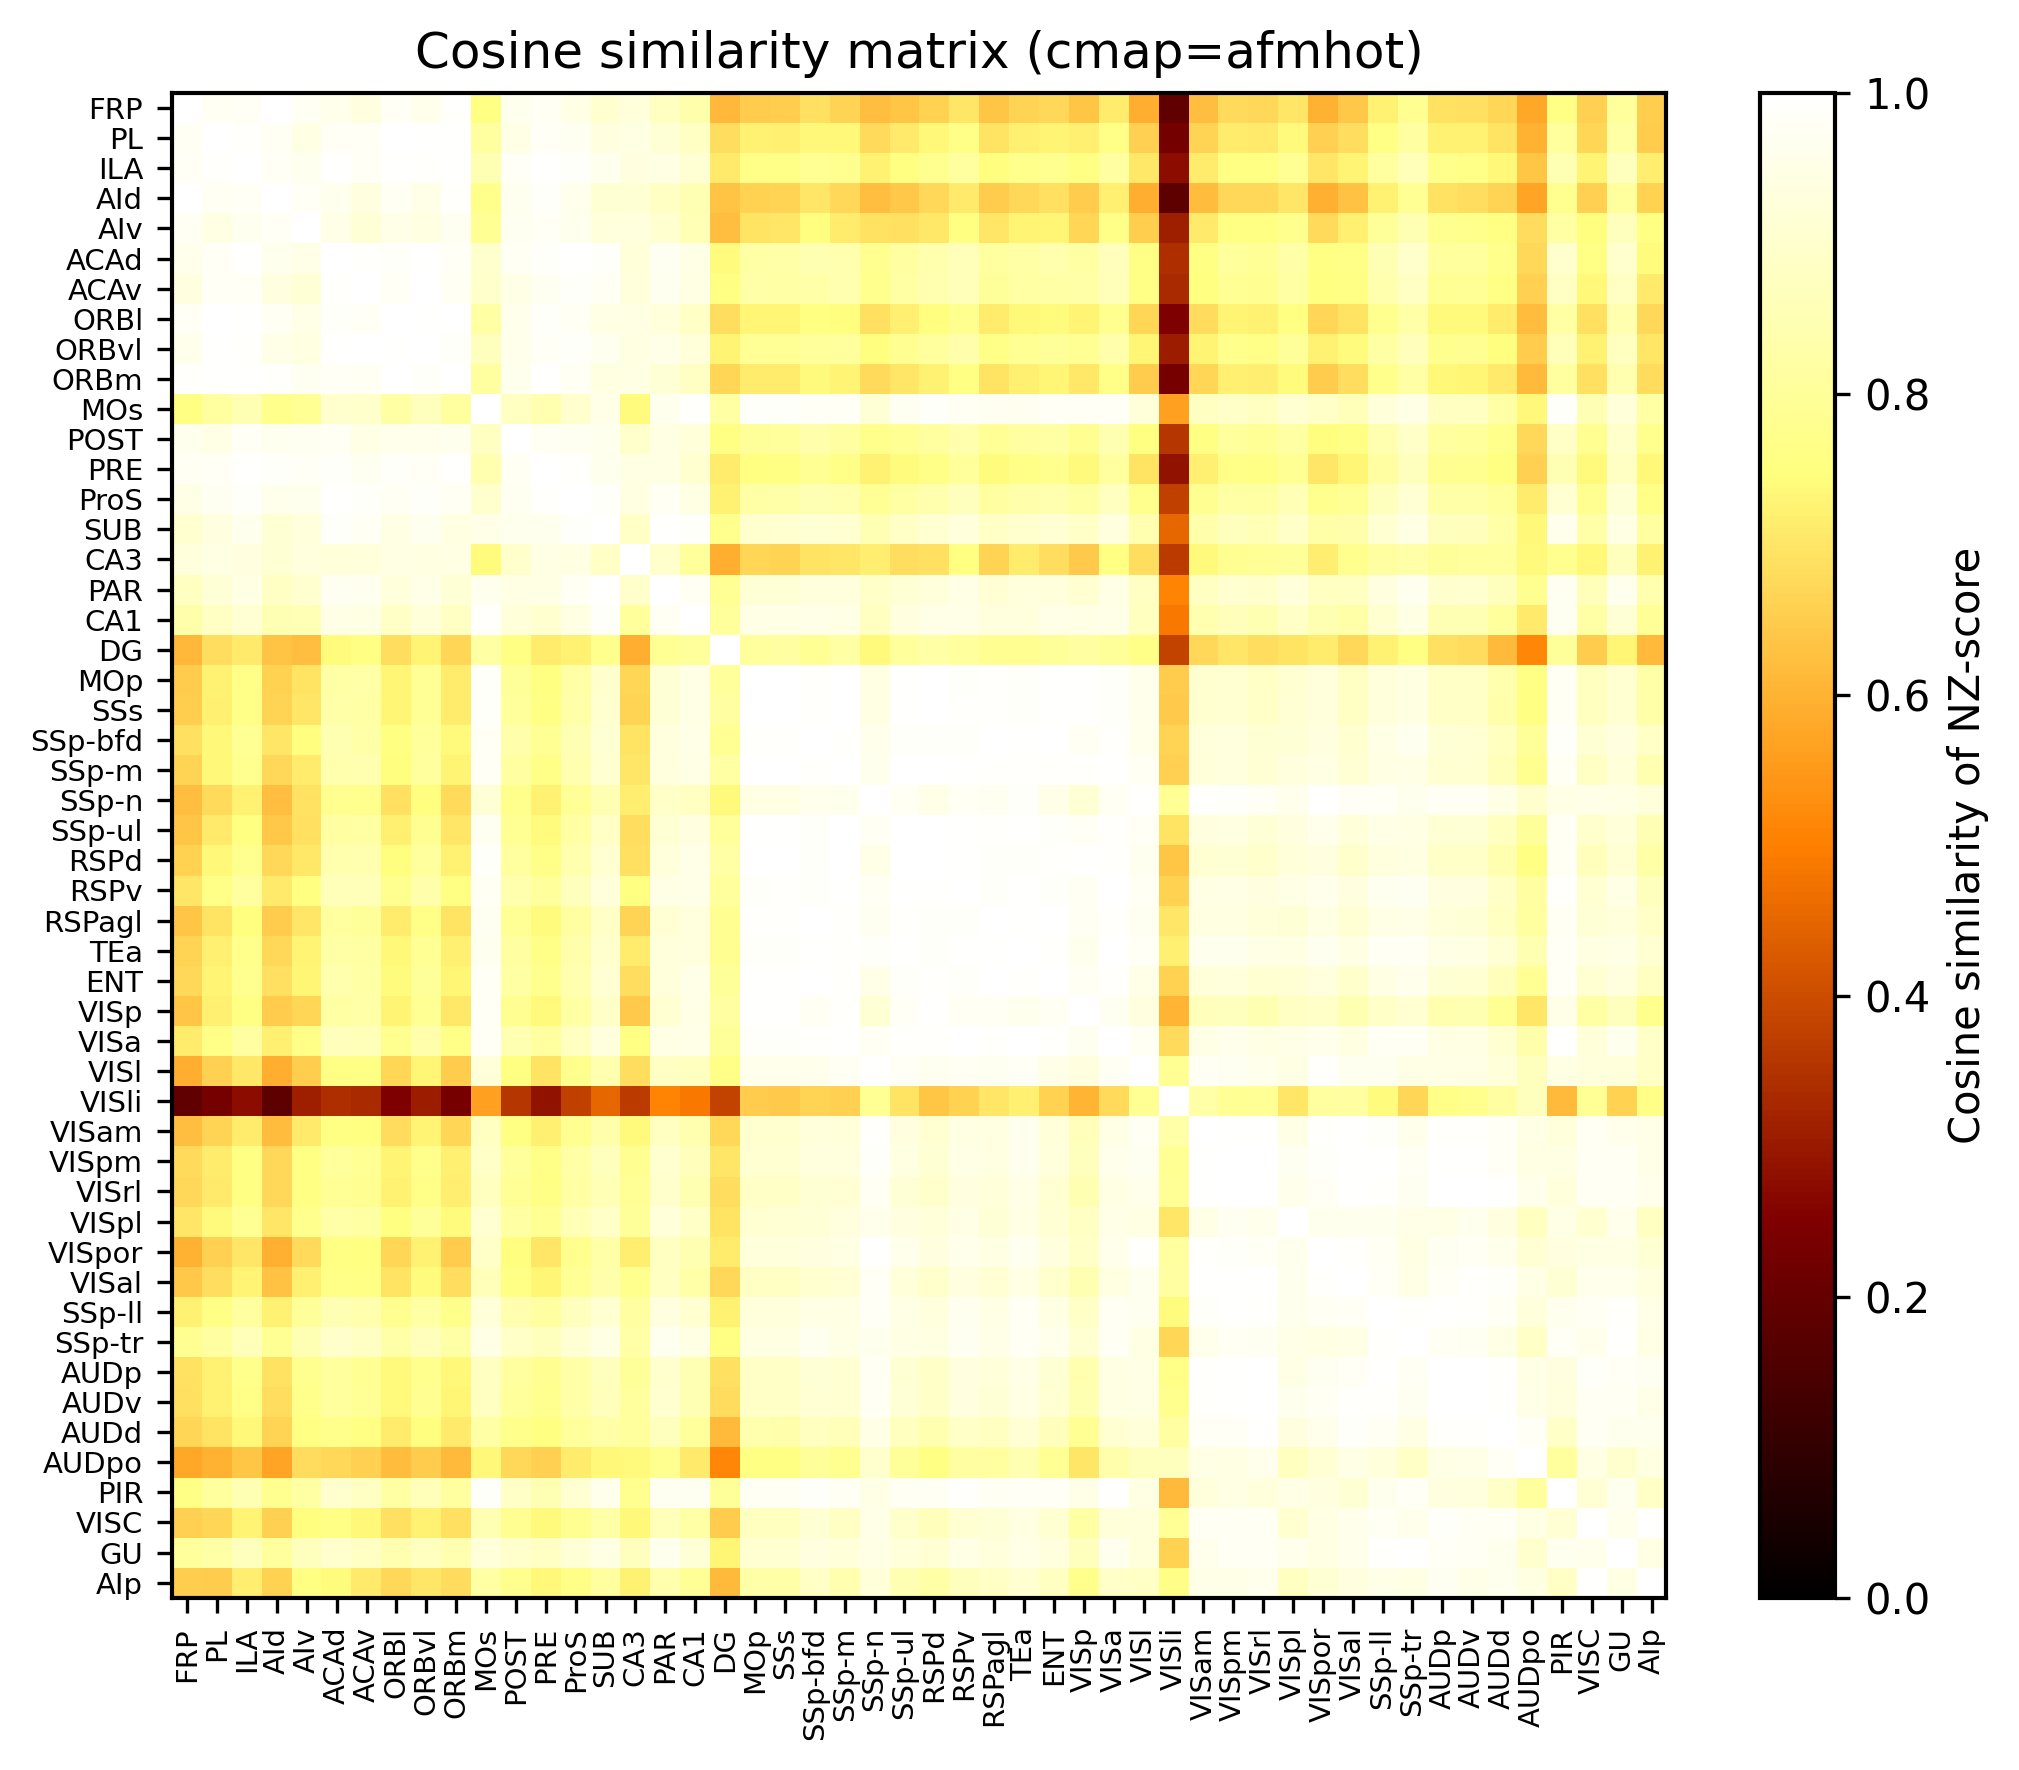

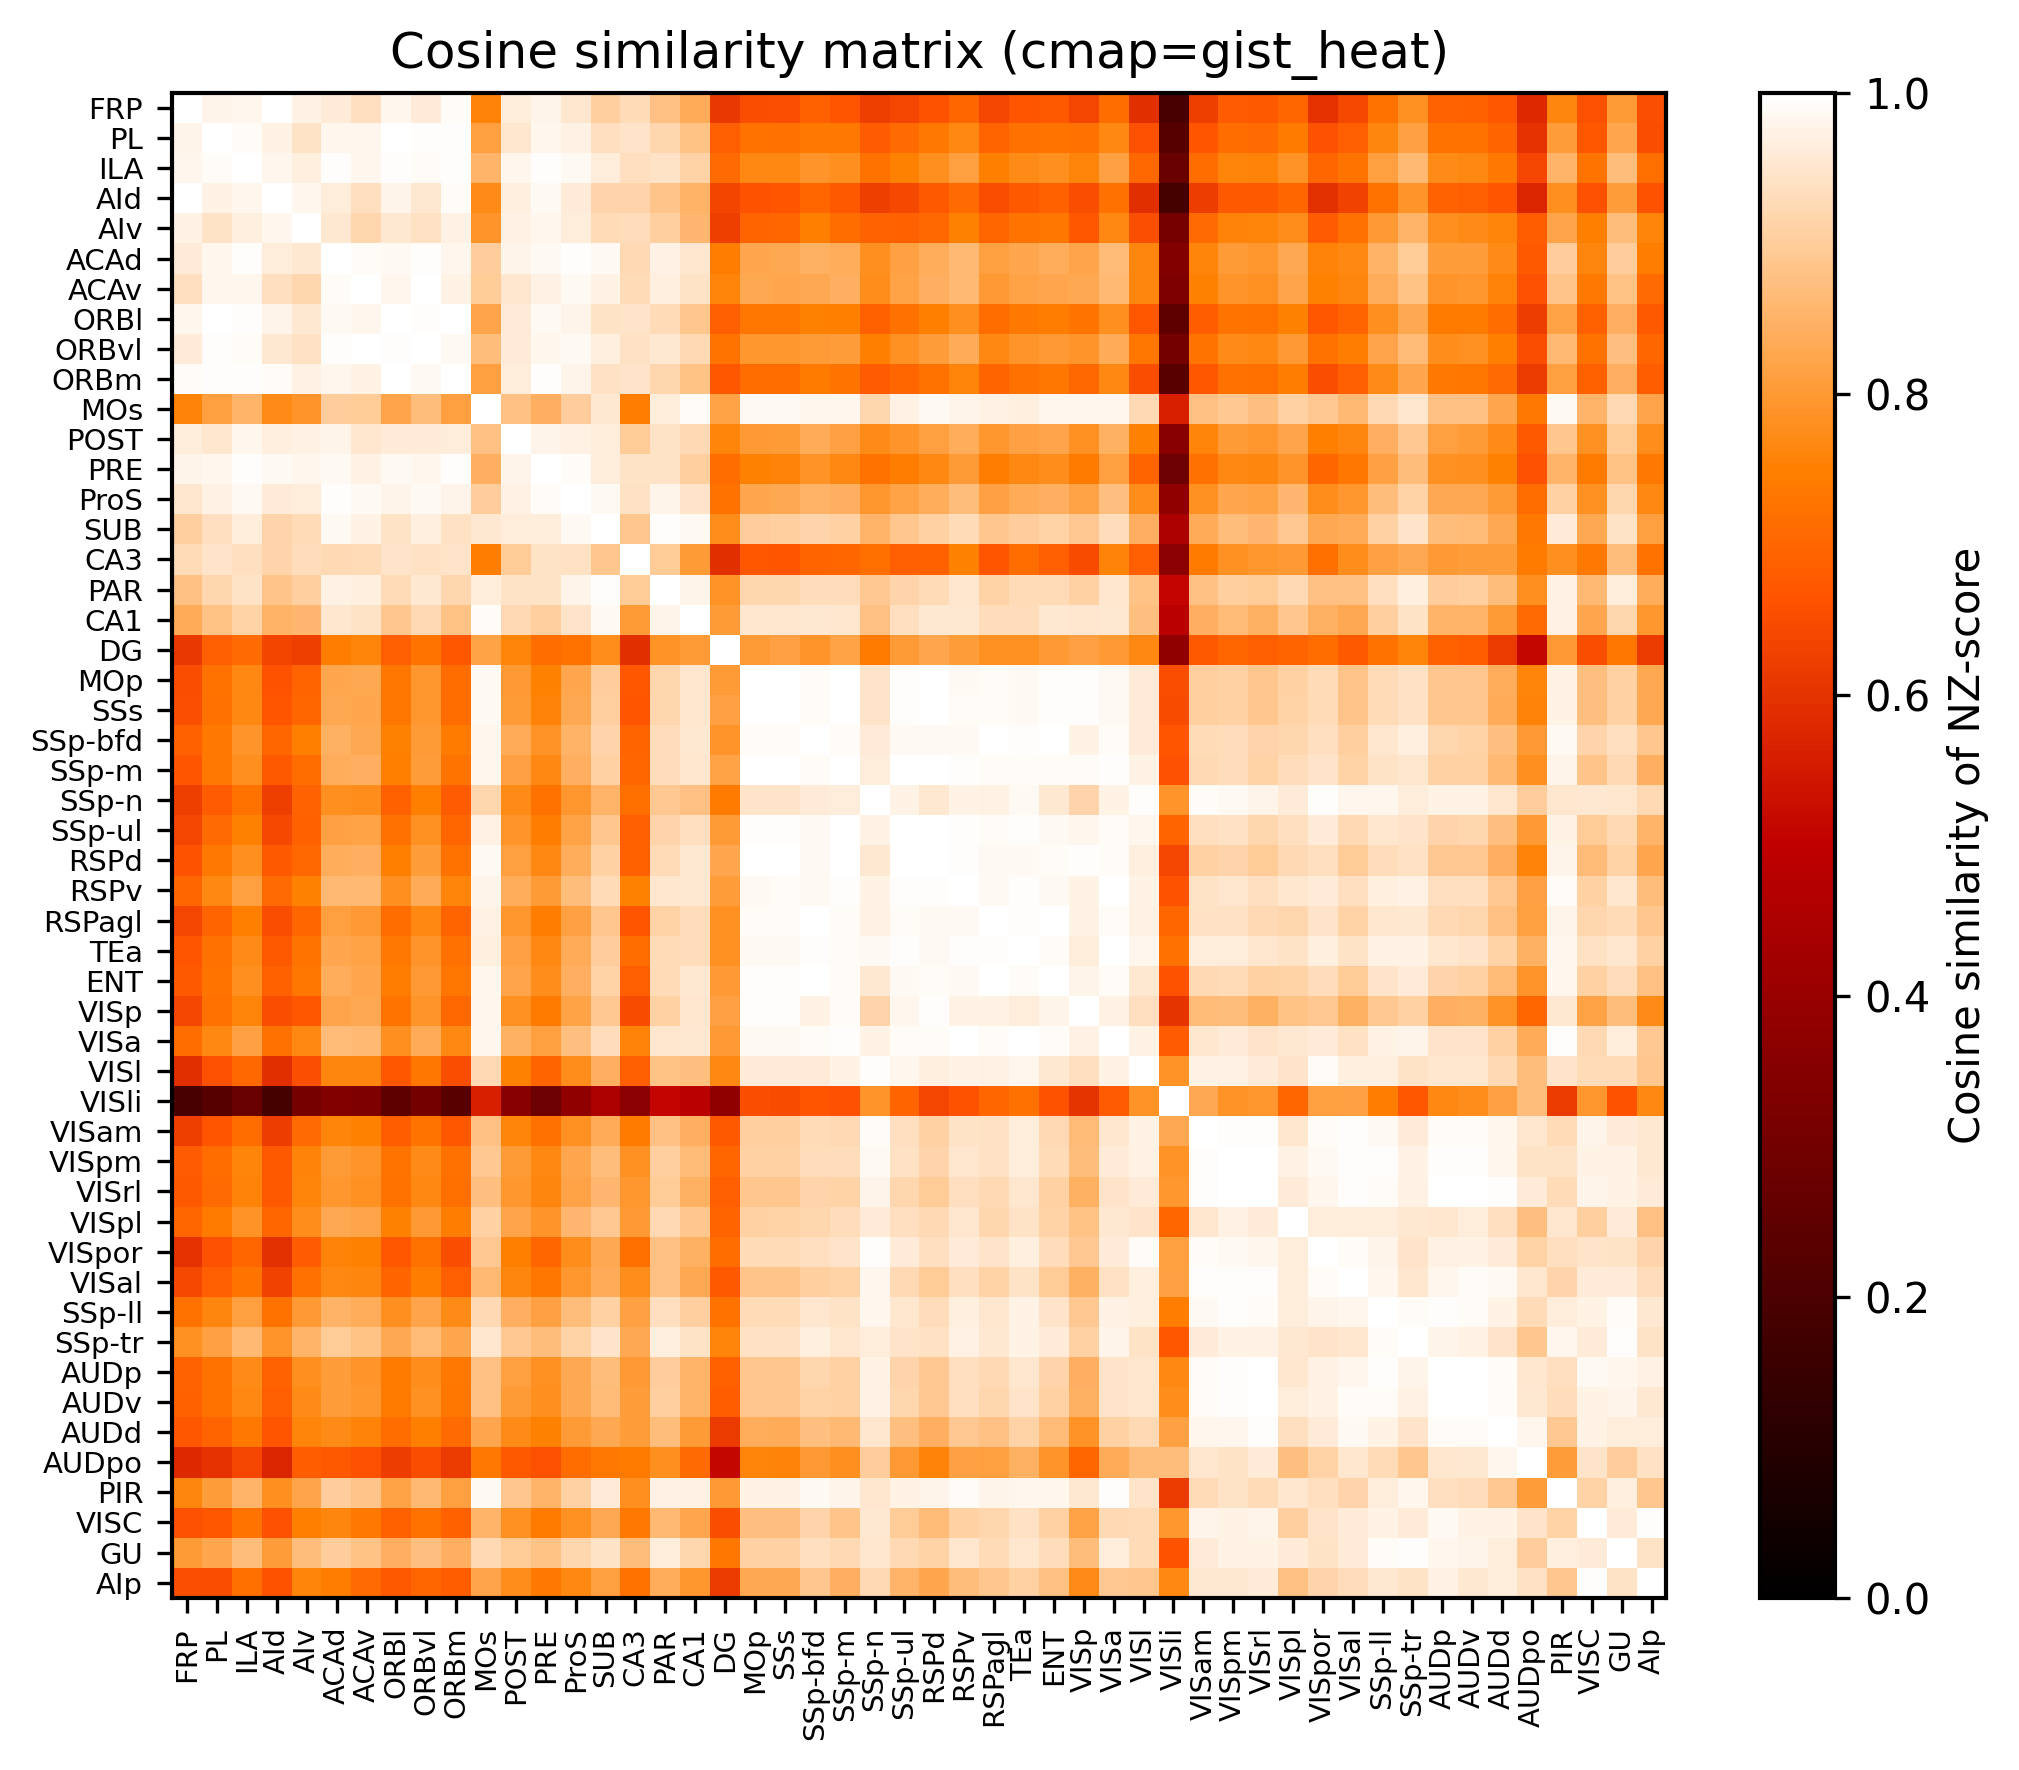

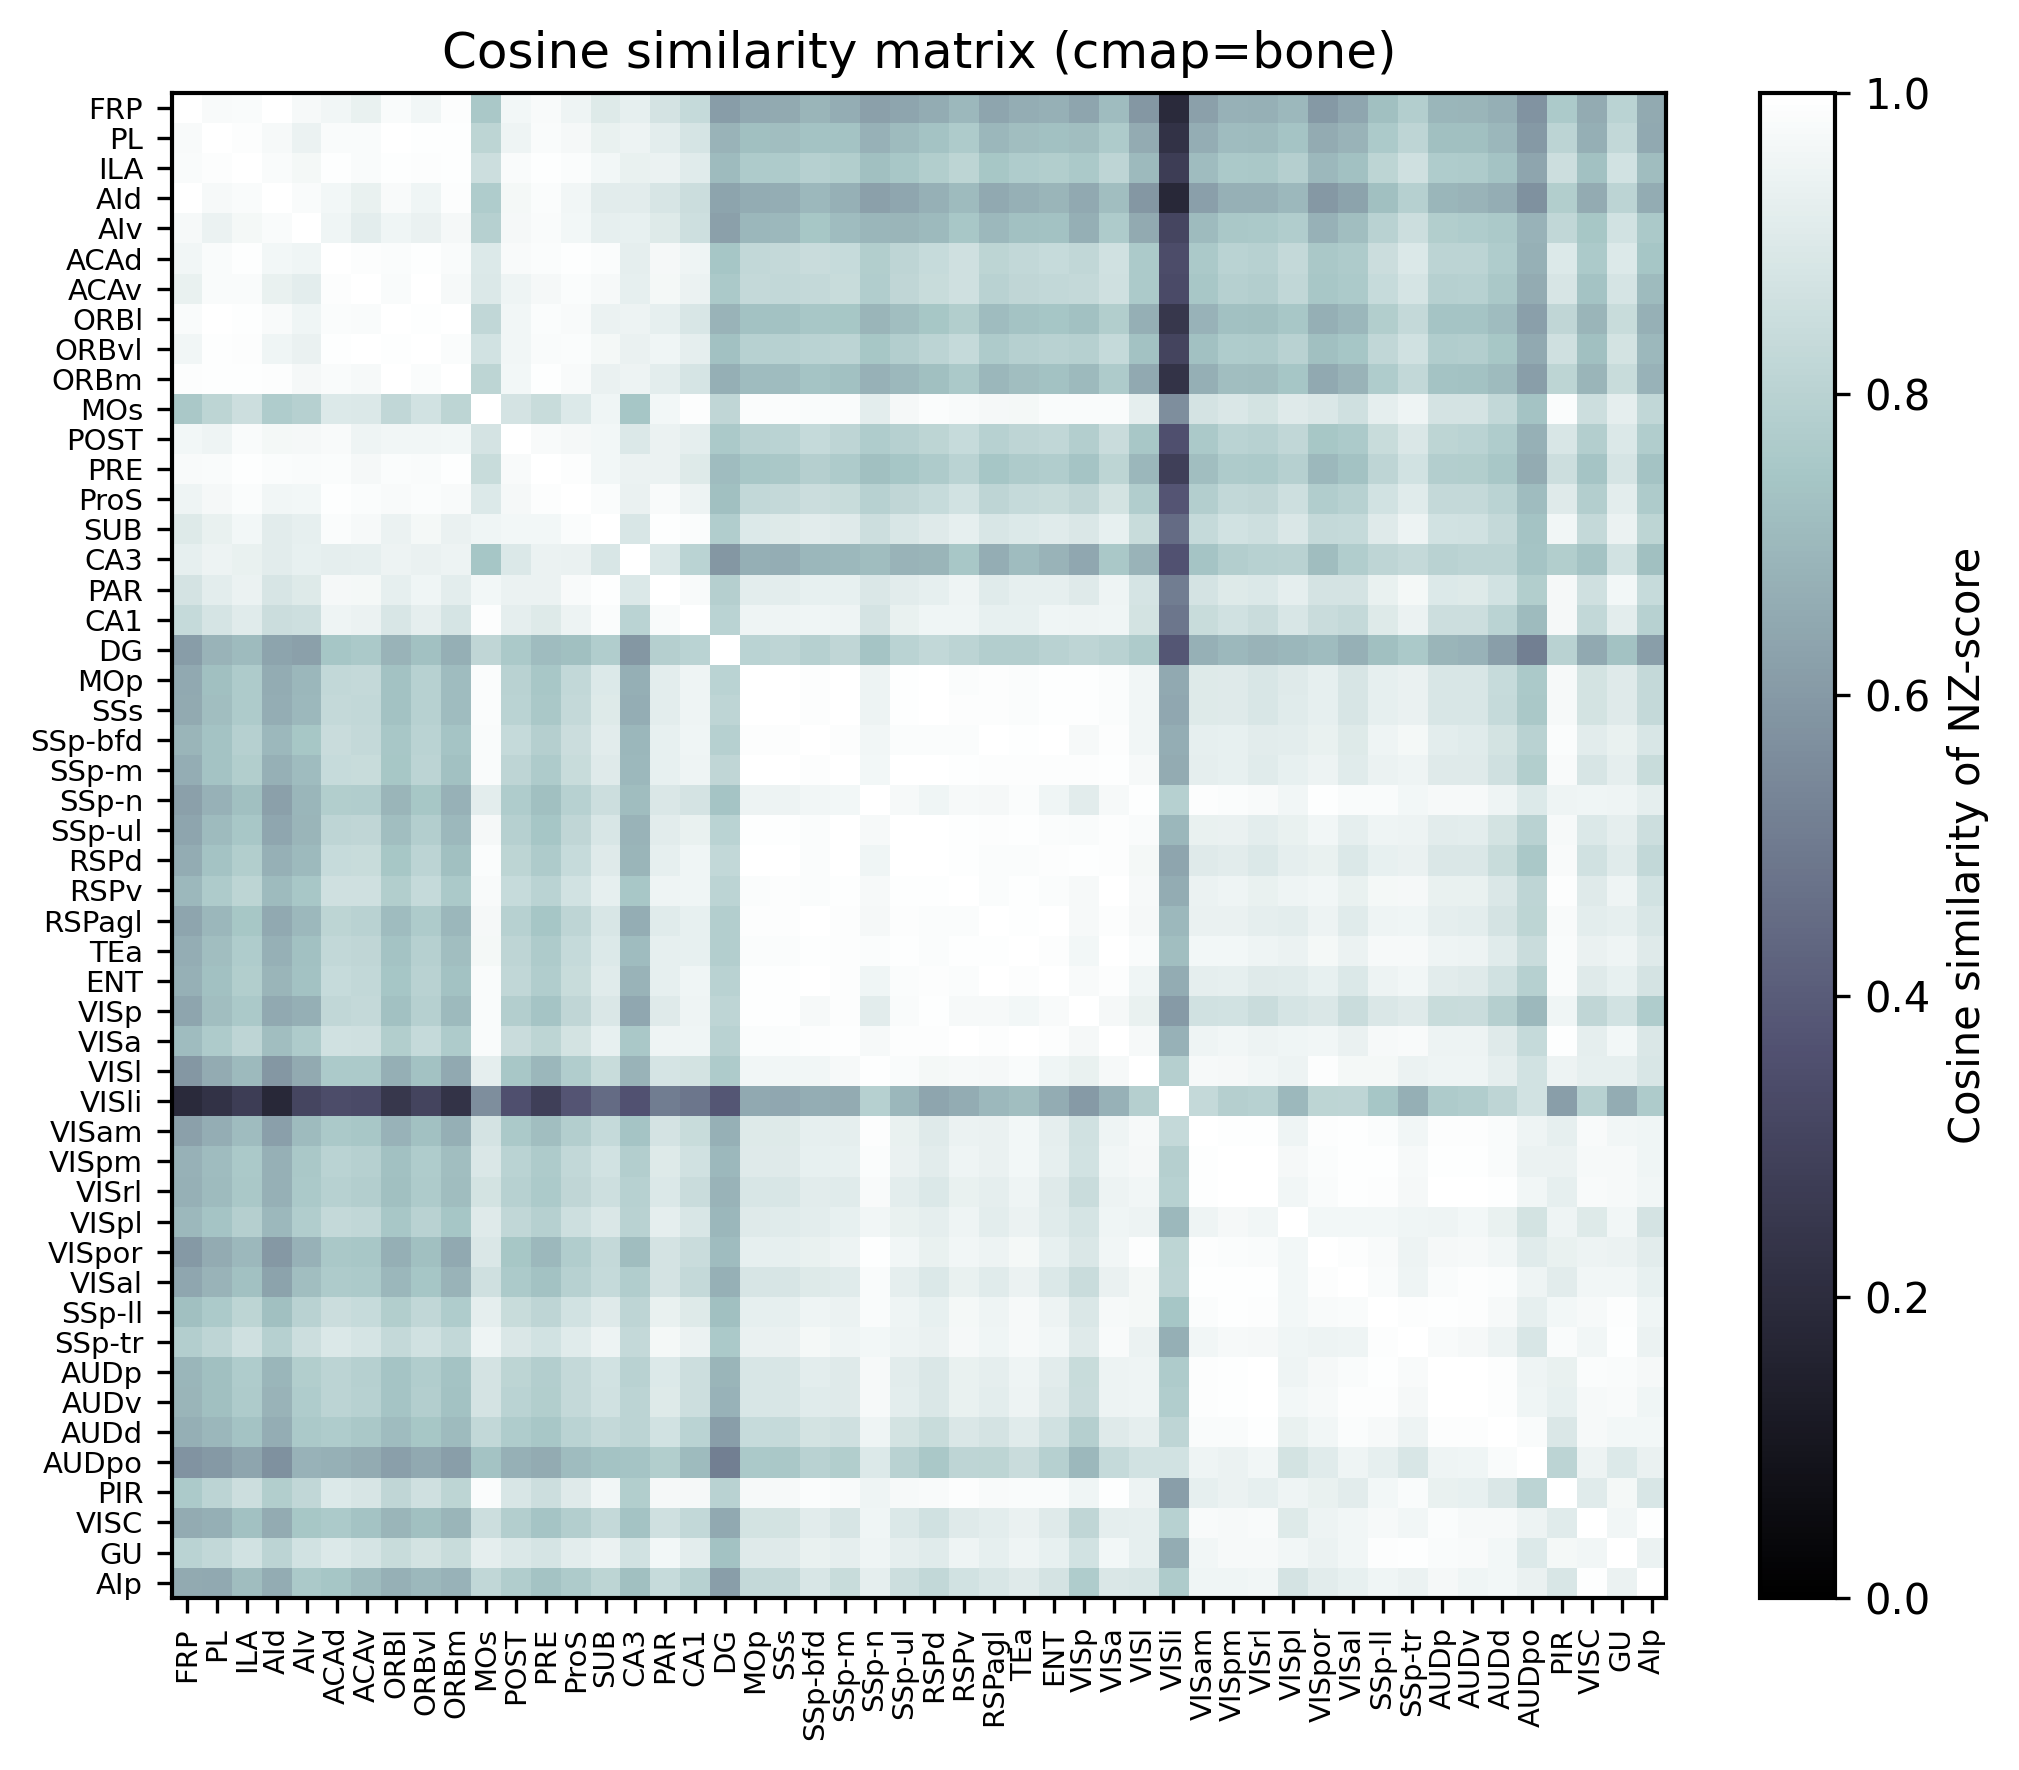

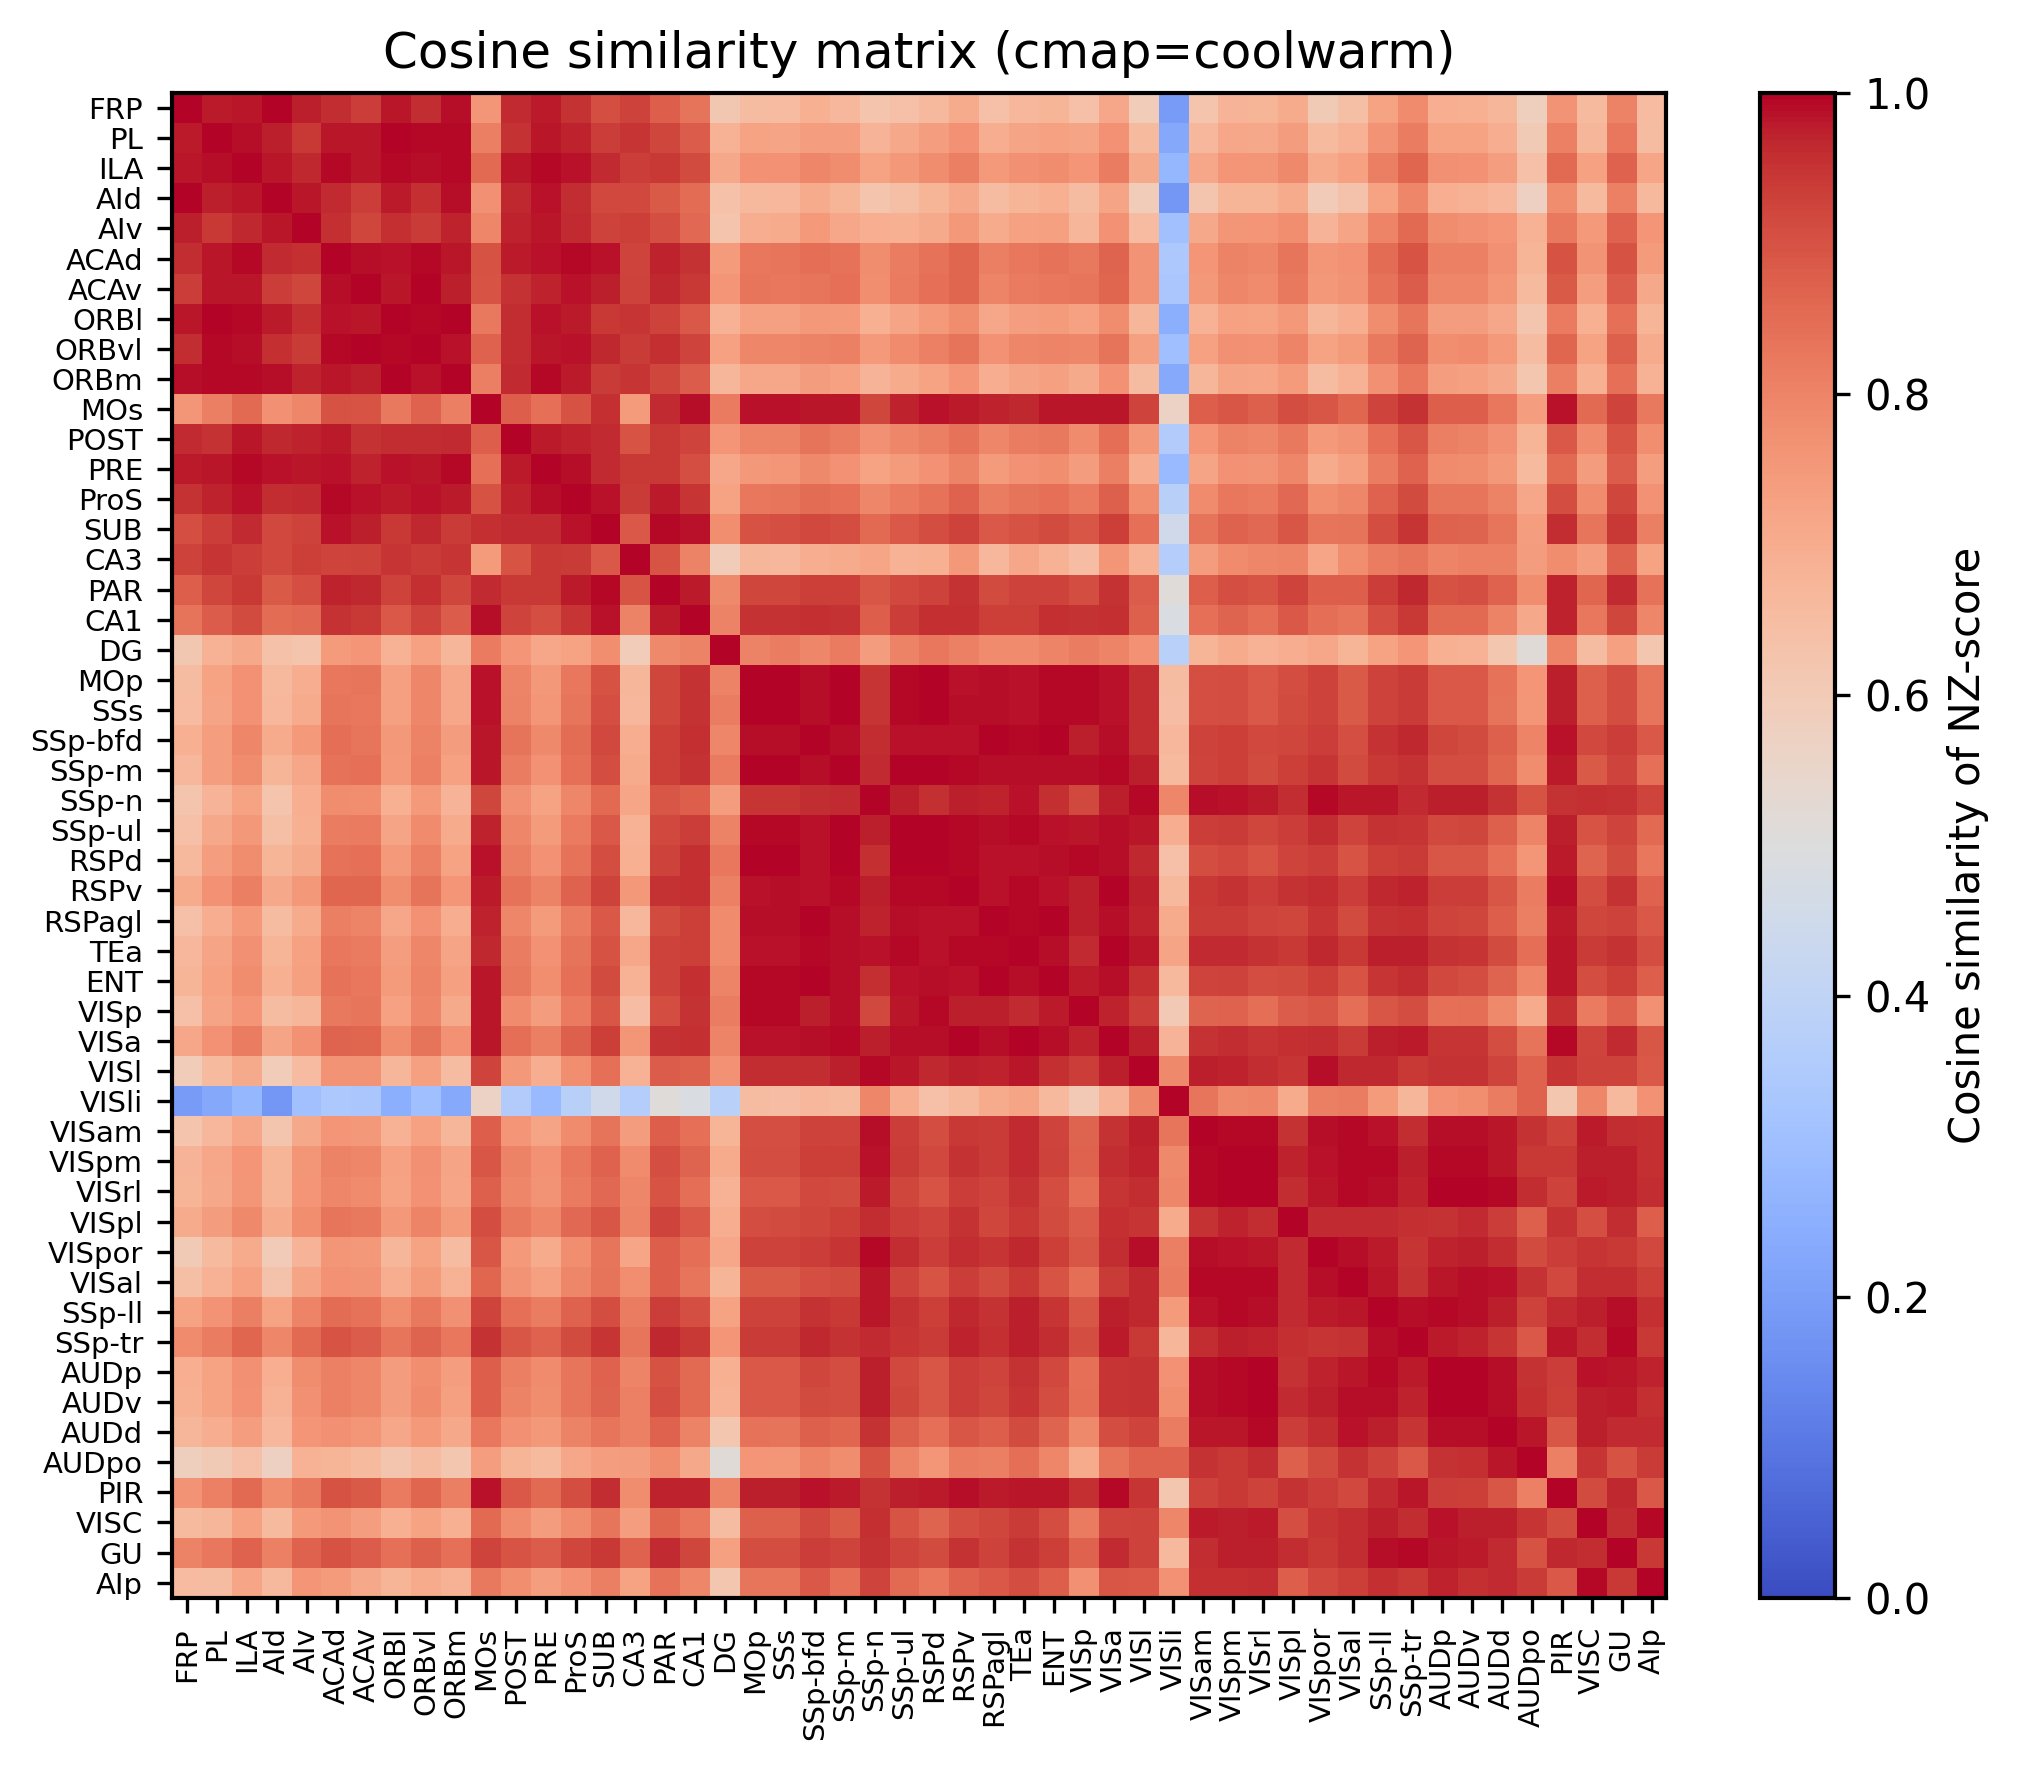

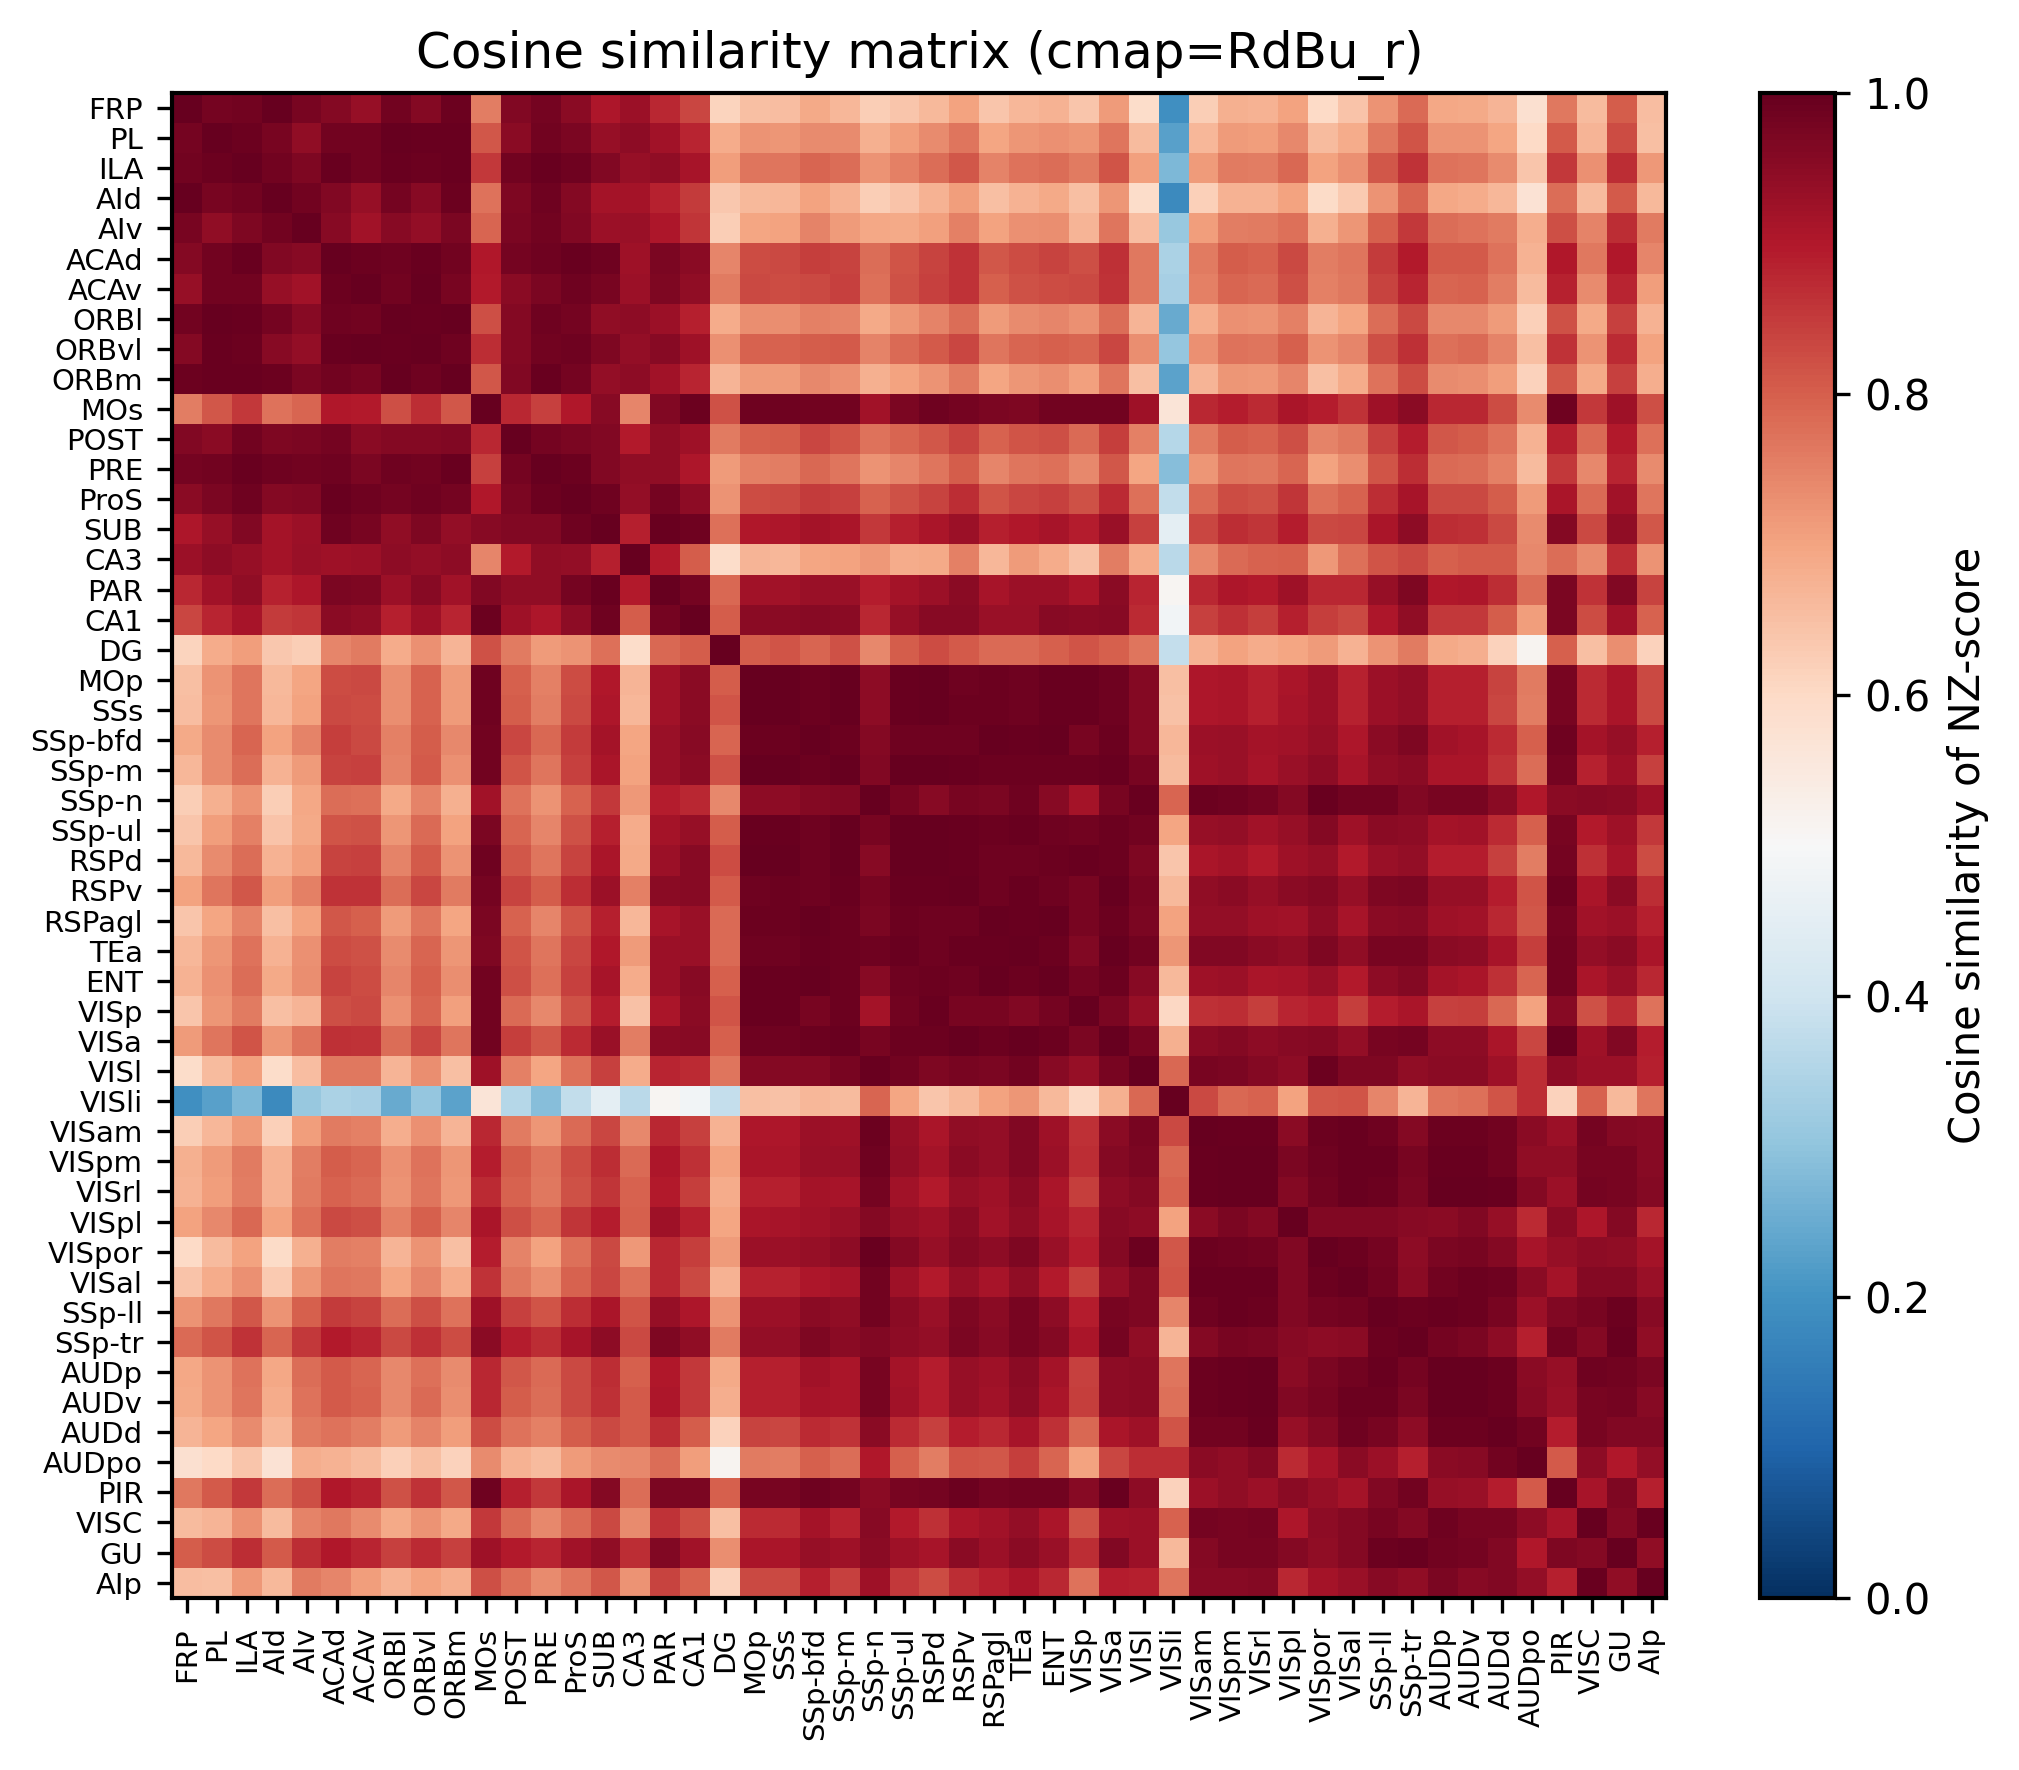

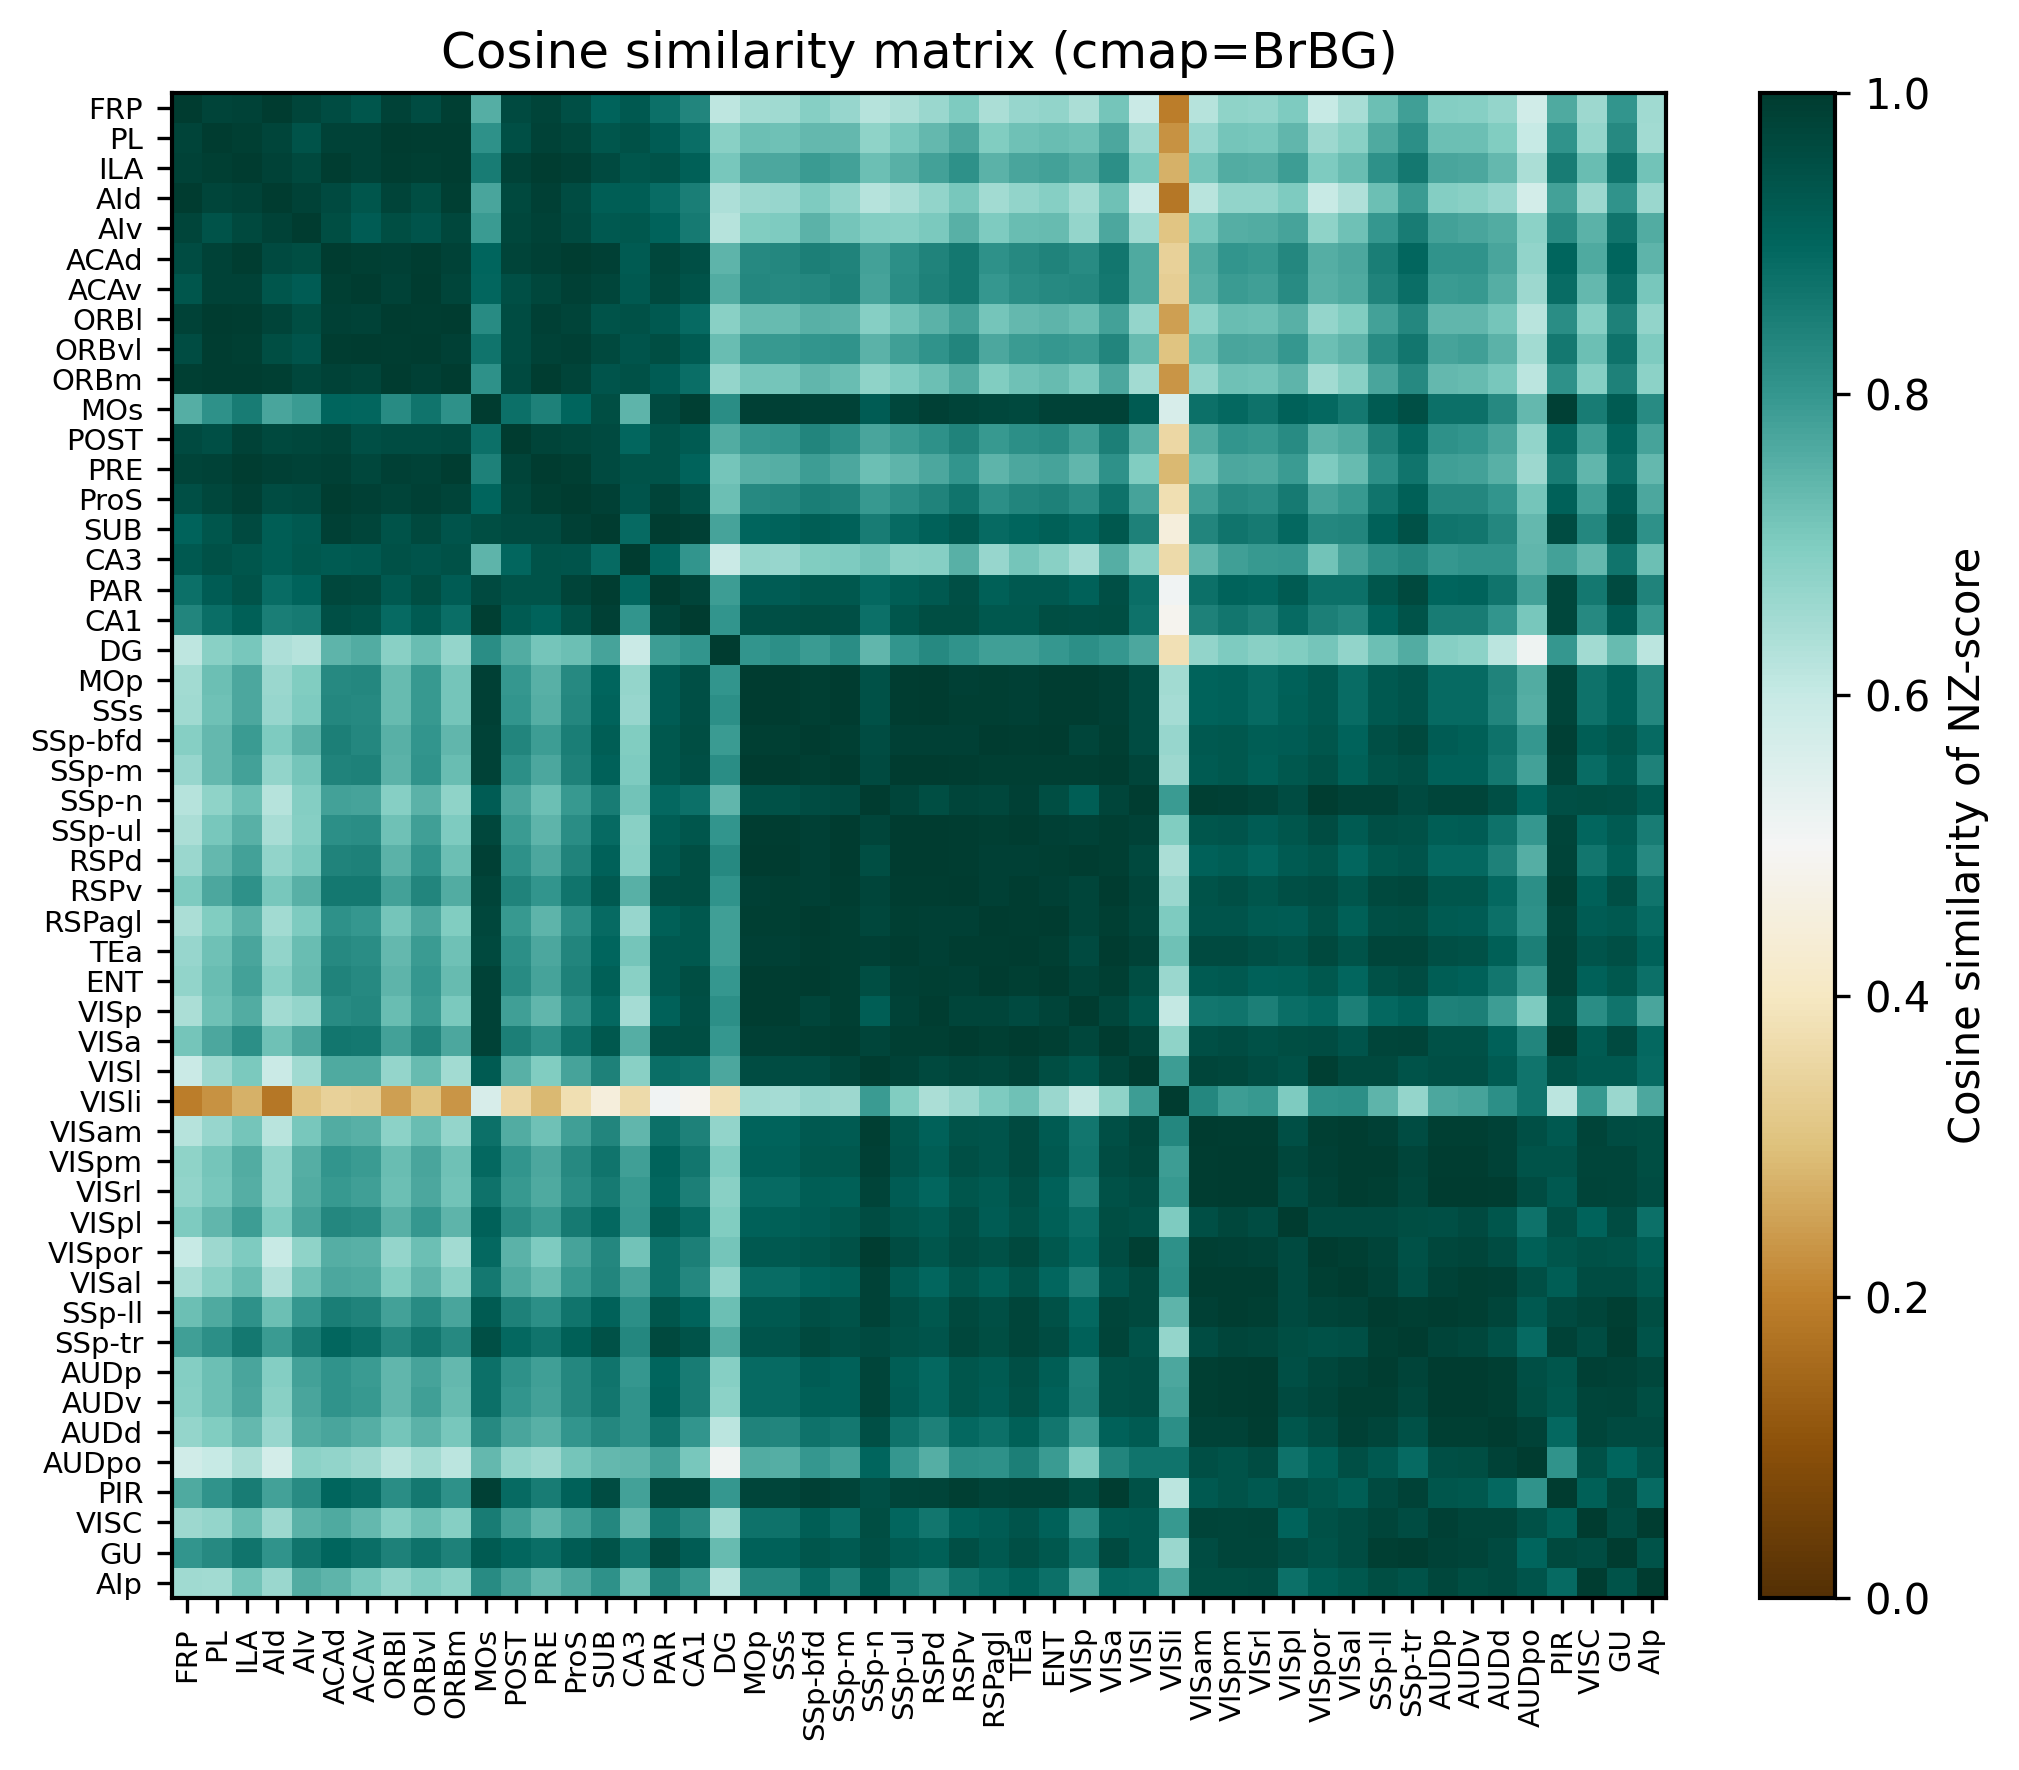

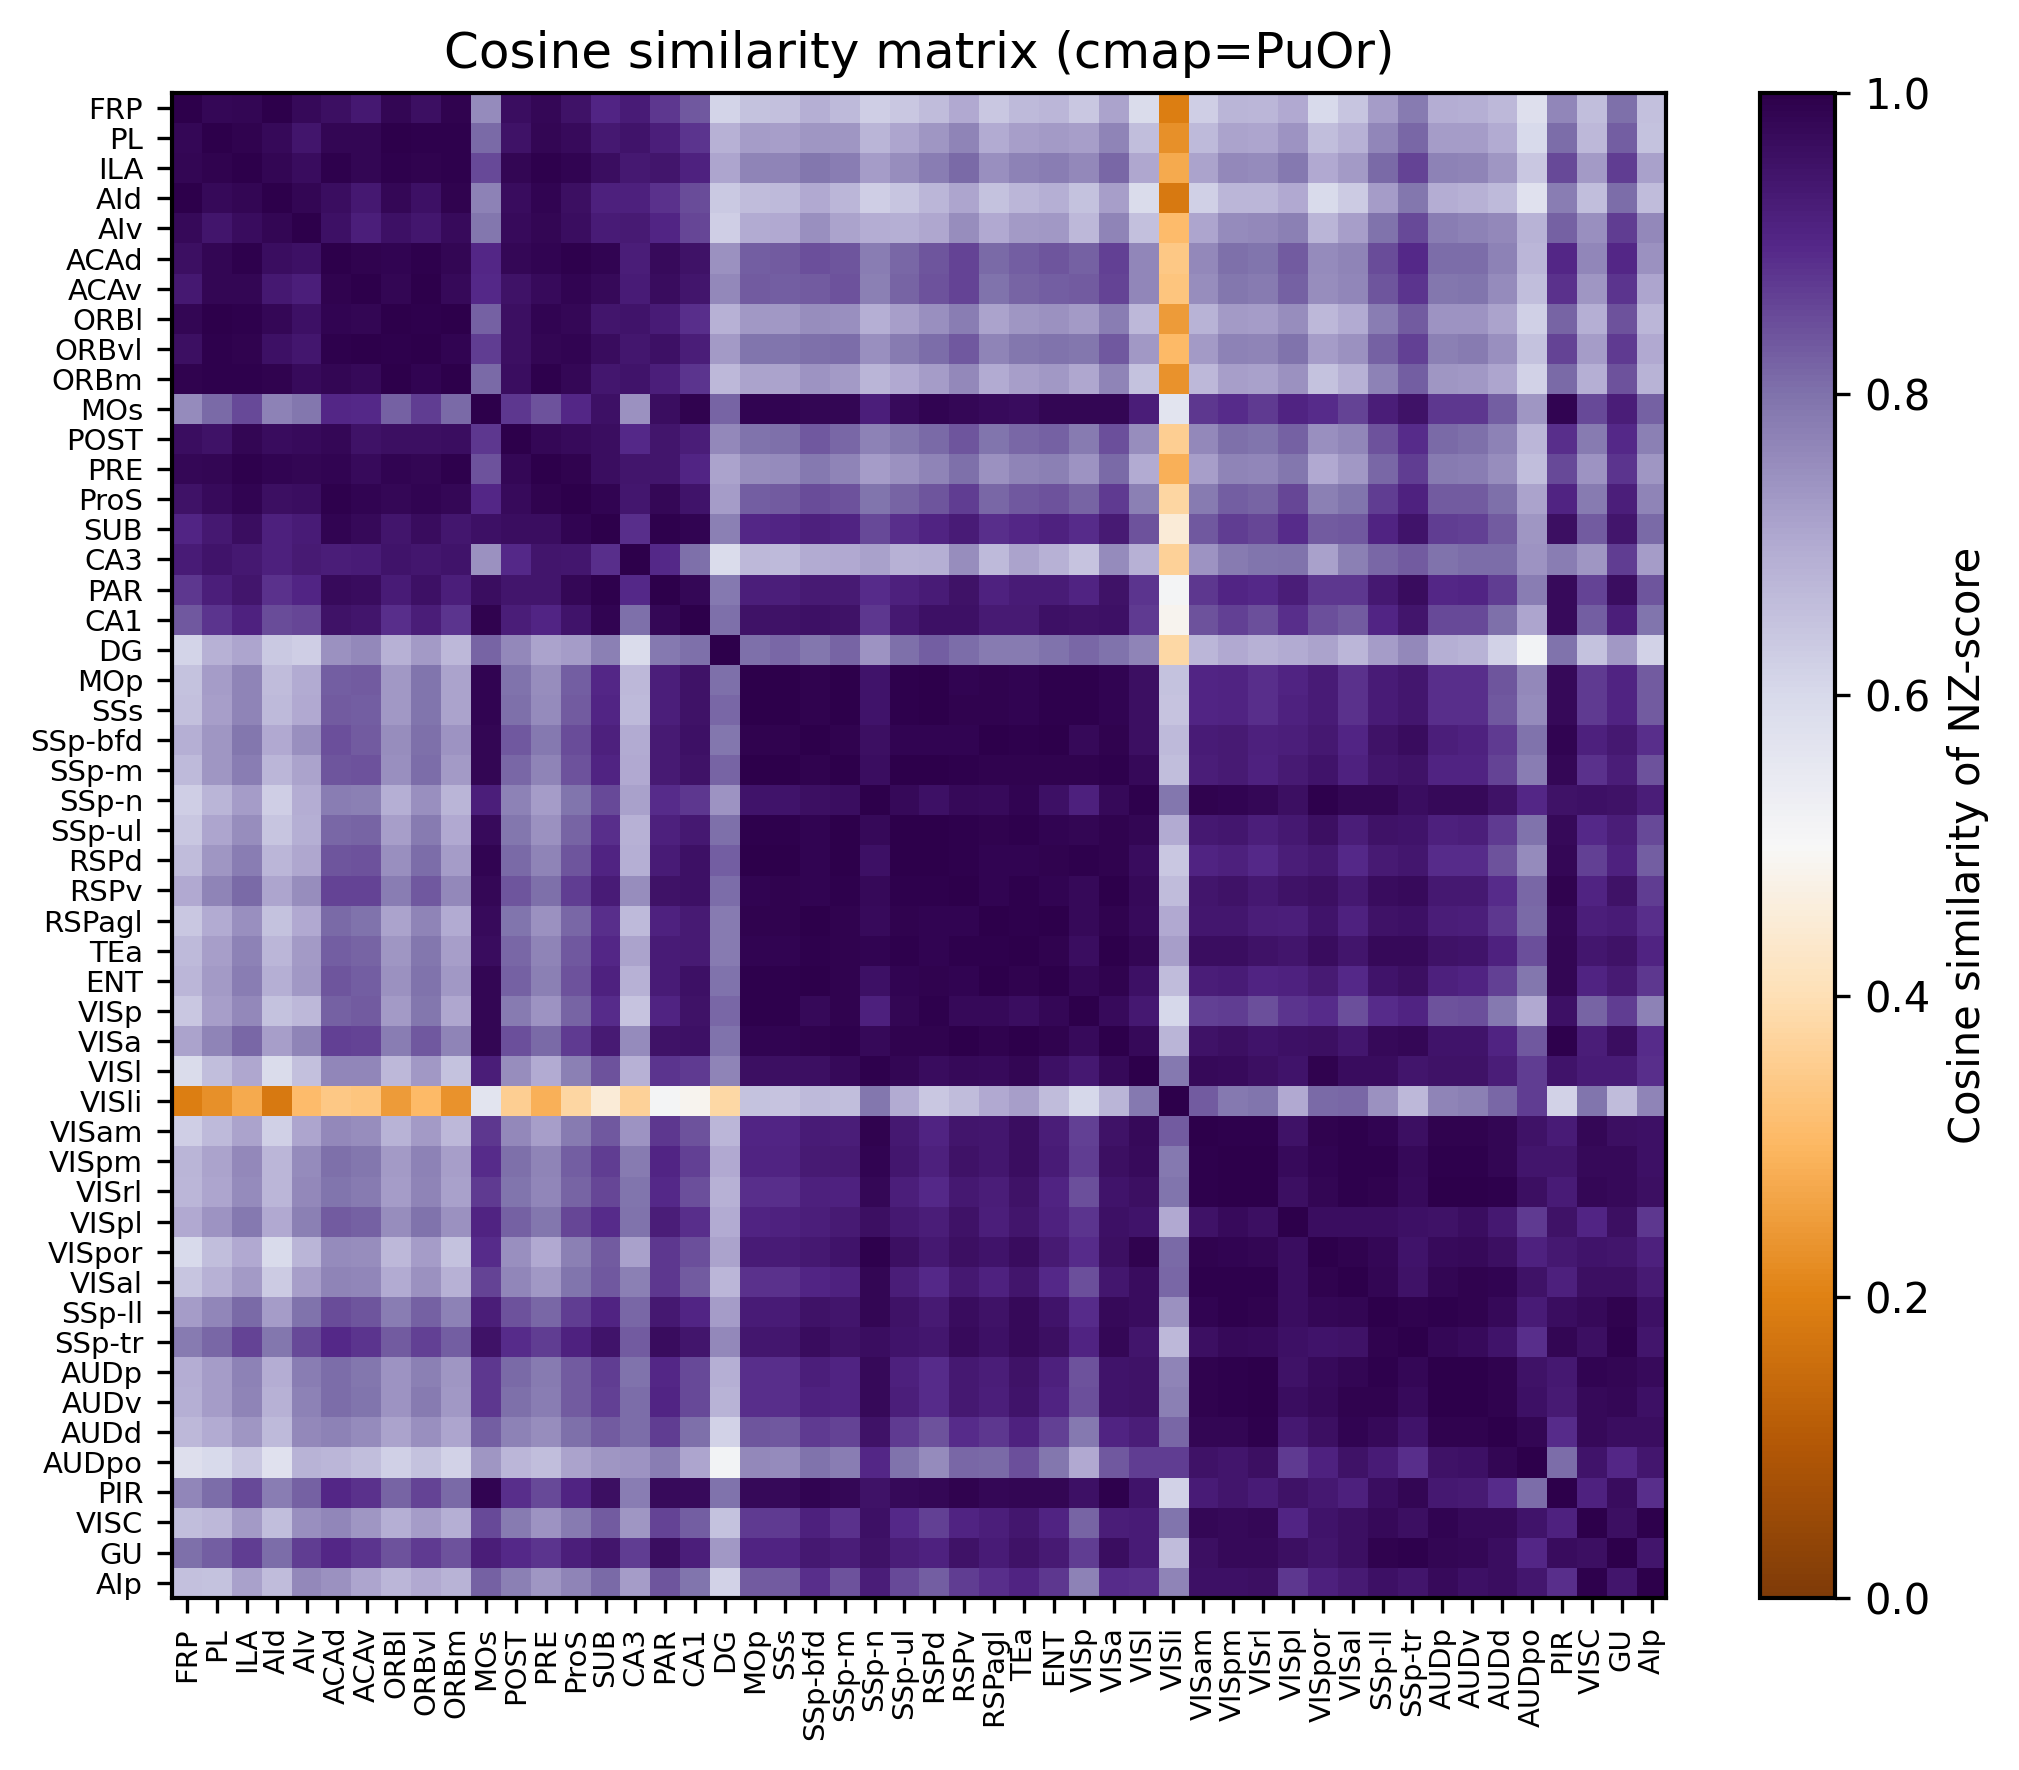

In [3]:
# ==================== 图1.5：NZ-score 余弦相似度矩阵 ====================
# NZ 已经是排好序的 (n_region, 13)，而且每行是 L2 归一化过的
# 余弦相似度 = 向量点积
# 只用前 12 个 motif 计算余弦相似度
X = NZ[:, :12]                                # (n_region, 12)
norms = np.linalg.norm(X, axis=1, keepdims=True)  # 每个脑区的 12 维范数
X_norm = X / norms                            # 行归一化到 L2=1

cos_sim = X_norm @ X_norm.T                  # (n_region, n_region)，真正的 cosine similarity
cmaps = [
    # perceptually uniform
    "viridis","cividis","plasma","inferno","magma","cubehelix",
    # restrained sequential
    "Blues","YlGnBu","PuBuGn","Purples","Greens","OrRd","YlOrBr","BuPu",
    # high-contrast / heat-ish
    "turbo","hot","afmhot","gist_heat","bone",
    # diverging (optional)
    "coolwarm","RdBu_r","BrBG","PuOr",
]
for cmap in cmaps:
    plt.figure(figsize=(7, 6))
    im = plt.imshow(cos_sim, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    plt.colorbar(im, label="Cosine similarity of NZ-score")
    plt.xticks(range(len(names)), names, rotation=90, fontsize=7)
    plt.yticks(range(len(names)), names, fontsize=7)
    plt.title(f"Cosine similarity matrix (cmap={cmap})")
    plt.tight_layout()
    plt.savefig(f"4.cosine_similarity_matrix_{cmap}.svg", bbox_inches="tight", dpi=300, transparent=True)
    plt.show()